In [1]:
%config InlineBackend.figure_format = 'retina'

# Введение в статистику

## Генеративные нейросети vs. Определения ИИ (ГОСТ и ISO)

*ГОСТ Р 71476-2024 «Искусственный интеллект. Концепции и терминология»*  
*ISO/IEC 22989:2022 «Artificial intelligence — Concepts and terminology»*

| **Критерий** | **Генеративные нейросети** | **Определение ИИ по ГОСТ Р 71476-2024** | **Определение ИИ по ISO/IEC 22989:2022** |
|---|---|---|---|
| **Цель** | Генерация текста/изображений на основе статистики | Поведение, имитирующее интеллектуальные функции человека | Система, демонстрирующая поведение, воспринимаемое как интеллектуальное |
| **Понимание контекста** | Нет (имитация смысла без понимания) | Требуется способность к интерпретации и принятию решений | Подразумевается способность к адаптивному поведению |
| **Обучение в реальном времени** | Нет (только дообучение вне сессии) | Предполагается способность к обучению и адаптации | Включает обучение и улучшение на основе опыта |
| **Целеполагание и автономность** | Отсутствует | ИИ должен обладать элементами автономности | Подразумевается автономное принятие решений |
| **Причинно-следственное мышление** | Нет, только вероятностные связи | Требуется логика и объяснимость | Подразумевается способность к объяснению решений |
| **Область применения** | Узкая, ограниченная задачей | Универсальность или способность к переносу знаний | Возможность применения в разных контекстах |
| **Юридическая ответственность** | Отсутствует | Не рассматривается как субъект права | Не рассматривается как субъект права |

## Что существует сегодня: «слабый ИИ»

Современные технологии, называемые «искусственным интеллектом», включают:

- **Машинное обучение и нейросети**, включая генеративные модели (ChatGPT, Midjourney, Copilot и др.)
- **Системы компьютерного зрения**, распознающие лица, объекты, жесты
- **Речевые интерфейсы**, такие как голосовые помощники
- **Автоматизация процессов**, включая рекомендательные системы, чат-ботов, предиктивную аналитику

Эти системы **выполняют конкретные задачи**, но:

- Не обладают **универсальным мышлением**
- Не могут **объяснить свои действия**
- Не имеют **интенциональности** или **целей**
- Не способны к **самостоятельному обучению вне заданной архитектуры**

## Генеративно-состязательные сети (GANs)

Изобретённые Яном Гудфеллоу в 2014 году, такие генеративные нейросети состоят из двух частей: генератора и дискриминатора, которые «состязаются» друг с другом. Генератор создаёт новые данные, в то время как дискриминатор старается отличить сгенерированные данные от реальных. В процессе обучения генератор стремится обмануть дискриминатор, а дискриминатор — научиться лучше различать настоящие данные от подделок. Эта динамика создаёт мощную обратную связь, которая в результате позволяет генерировать высококачественные данные.

```mermaid
flowchart LR
    A[Шум] --> B[Генератор]
    B --> C[Сгенерированные данные]
    C --> D[Дискриминатор]
    E[Реальные данные] --> D
    D --> F[Fake or Real]
```

## Вариационные автоэнкодеры (VAEs)

Основой VAE является автоэнкодер, который состоит из двух основных частей: энкодера, который преобразует входные данные в сжатое представление (латентное пространство), и декодера, который восстанавливает данные из этого сжатого представления.

Вариационный автоэнкодер добавляет стохастические (случайные) процессы в эту архитектуру, позволяя создавать новые данные путём выборки из латентного пространства, предполагая, что данные распределены согласно вероятностному распределению, чаще всего нормальному.

```mermaid
flowchart LR
    A[Входные данные] --> B[Энкодер]
    B --> C["Латентное пространство (μ, σ²)"]
    C --> D["Выборка z ~ N(μ, σ²)"]
    D --> E[Декодер]
    E --> F[Восстановленные данные]
```

### Что такое каждый блок — на примере рукописных цифр (MNIST)

**Входные данные** — изображение цифры, например «7». Это 28×28 = 784 пикселя, каждый со значением яркости от 0 до 1.

**Энкодер** — нейросеть, которая «сжимает» 784 числа в несколько. Например, в 2. Она ищет ответ на вопрос: *какие главные характеристики описывают эту цифру?* (наклон, толщина линий и т.п.)

**Латентное пространство (μ, σ²)** — вместо того чтобы записать цифру одной точкой, VAE записывает её как **распределение**: среднее μ и разброс σ². Например: «эта семёрка — где-то в районе точки (1.2, −0.5) с разбросом ±0.3». Это ключевое отличие от обычного автоэнкодера.

**Выборка z ~ N(μ, σ²)** — из этого распределения случайно берётся точка z. Именно поэтому модель *генеративная*: каждый раз точка чуть разная → на выходе получаются разные, но похожие цифры.

**Декодер** — нейросеть, которая делает обратное: из 2 чисел восстанавливает 784 пикселя обратно в изображение.

**Восстановленные данные** — реконструкция исходной цифры. Если взять случайную точку z из латентного пространства (а не из энкодера), декодер сгенерирует новую цифру, которой не было в данных.

## Авторегрессионные модели

Авторегрессионные модели — это разновидность генеративных моделей, которые предсказывают каждый следующий элемент в последовательности, основываясь на предыдущих элементах.

Они обычно имеют высокую вычислительную сложность, но благодаря современным архитектурам, таким как Transformer, процесс генерации данных может быть значительно ускорен. Генеративные нейронные сети такого типа нашли широкое применение в области обработки естественного языка, где они используются для создания текстового контента, такого как стихи или новостные статьи, а также в генерации музыки и создании рекомендательных систем.

### Что такое токен

**Токен** — это минимальная единица, с которой работает модель. В тексте это обычно не буква и не слово целиком, а что-то среднее: часть слова, целое короткое слово или знак препинания. Например, слово «статистика» может быть разбито на токены `стат` + `истика`, а слово «да» — остаться одним токеном.

Перед подачей в модель каждый токен превращается в число (его индекс в словаре модели).

### Как работает процесс — пример пошагово

Допустим, модель уже видела начало фразы и должна продолжить её:

| Шаг | Контекст (что модель видит) | Предсказание |
|-----|----------------------------|--------------|
| 1 | `Москва` | `—` |
| 2 | `Москва —` | `столица` |
| 3 | `Москва — столица` | `России` |
| 4 | `Москва — столица России` | `.` |
| 5 | `Москва — столица России .` | `[конец]` |

На каждом шаге модель смотрит на **весь предыдущий контекст** и выдаёт распределение вероятностей по всем токенам словаря. Токен с наибольшей вероятностью выбирается как следующий и добавляется в контекст.

```mermaid
flowchart LR
    A[Москва] --> M[Модель]
    B[—] --> M
    C[столица] --> M
    M -->|p&#40;России&#41; = 0.74| E[России]
    E --> M
```

## Проблемы и особенности генеративного «ИИ»

- Качество и достоверность сгенерированных данных
- Этические и юридические вопросы
- Контроль за порождением данных
- Вычислительные затраты
- Непредсказуемость
- Переобучение и обобщающая способность
- Безопасность применения

## Спросите у нейросети про галлюцинирование

### Примеры галлюцинаций нейросетей

- **Вымышленные источники и статьи** — ChatGPT может сослаться на несуществующую научную статью или выдуманный URL, особенно если его просят привести источник по редкой теме.

- **Неверные факты с уверенностью** — Например, при запросе о доходах Tesla нейросеть может уверенно заявить: «13,6 миллиарда долларов», хотя таких данных нет в её обучающей выборке. Она повторяет эту цифру, будто это проверенный факт.

- **Придуманные судебные дела** — Адвокат в США использовал ChatGPT для подготовки иска, а нейросеть сослалась на несуществующие судебные дела. Это привело к скандалу и штрафу для юриста.

- **Ошибки в биографиях** — Нейросети могут приписывать людям неверные места рождения, должности или достижения. Например, назвать актёра лауреатом премии, которую он никогда не получал.

- **Фантазии в переводах и пересказах** — При пересказе текста или переводе с одного языка на другой ИИ может добавить «от себя» детали, которых не было в оригинале.

## Ядро статистики vs. Надстройка ИИ

| **Метод / концепт** | **Ядро статистики** | **Надстройка ИИ / современные технологии** | **Недостатки современных технологий** |
|---|---|---|---|
| **ARIMA / экспоненциальное сглаживание** | Линейные модели временных рядов, стационарность, автокорреляция, доверительные интервалы | AutoARIMA, ансамбли с ML, интеграция с big data потоками | Потеря интерпретируемости при ансамблях; риск переобучения на шумных данных |
| **Регрессия (линейная, логистическая)** | Оценка коэффициентов, проверка гипотез, значимость факторов | Регуляризация, нелинейные аппроксимации через нейросети, feature engineering | Сложность объяснения результатов бизнесу; зависимость от качества признаков |
| **Байесовские модели** | Теорема Байеса, апостериорные распределения, вероятностные выводы | Вариационные приближения, MCMC на GPU, байесовские нейросети | Высокая вычислительная стоимость; трудности валидации сложных аппроксимаций |
| **Метод Монте-Карло** | Генерация случайных чисел, оценка распределений исходов | Квазислучайные последовательности, параллельные вычисления, ML-генерация входных распределений | Требует огромных вычислительных ресурсов; чувствителен к ошибкам в исходных распределениях |
| **Классические индексы и доверительные интервалы** | Формулы для стандартных ошибок, нормальные приближения | Bootstrap, bagging, ансамбли прогнозов | Интервалы могут быть слишком узкими или широкими при плохих данных; сложность визуализации |
| **Кластеризация (k-means, иерархическая)** | Евклидовы расстояния, минимизация дисперсии внутри кластеров | Deep clustering, нелинейные метрики, потоковые данные | Риск «чёрного ящика»; трудно объяснить бизнесу, почему клиент попал в кластер |
| **Сценарное моделирование** | Вероятностные методы (Монте-Карло, статистические сценарии) | Интеграция с ML-прогнозами, стресс-тесты, визуализация диапазонов | Сложность настройки; риск иллюзии точности при красивой визуализации; зависимость от качества исходных данных |

**Классика**: проще, прозрачнее, легче объяснить аудитории и регулятору.

**Современные технологии**: дают гибкость и масштаб, но часто превращаются в «чёрный ящик», требуют больших ресурсов и могут создавать иллюзию точности.

## Статистика. История.

> «В те дни вышло от кесаря Августа повеление сделать перепись населения по всей земле… Эта перепись была первая в правление Квириния Сириею… И пошли все записываться, каждый в свой город… Пошел также и Иосиф из Галилеи, из города Назарета, в Иудею, в город Давидов, называемый Вифлеем, потому что он был из дома и рода Давидова, …записаться с Мариею, обрученною ему женою, которая была беременна… Когда же они были там, наступило время родить Ей; и родила Сына своего первенца… и сказал им Ангел: … родился вам в городе Давидовом Спаситель, Который есть Христос Господь…»

*(Новый Завет: Евангелие от Луки, глава 2, стихи 1–11)*

### Уильям Петти (Sir William Petty, 1623–1687)

Уильям Петти — яркая разносторонняя личность: врач, изобретатель копировальной машины, доктор физики, профессор астрономии, основоположник трудовой теории стоимости, государственный деятель, один из основателей «Лондонского королевского общества» (1662).

«Эссе о политической арифметике» — первая работа, в основе которой лежал статистико-экономический метод исследования.

В предисловии к этой работе Петти указал, что его способ исследования *«необычный, ибо вместо того, чтобы употреблять слова только в сравнительной и превосходной степени и прибегать к умозрительным аргументам, я вступил на путь выражения своих мнений на языке чисел, весов и мер… я уже давно стремился пойти по этому пути, чтобы показать пример политической арифметики»*.

> **НО:** отсутствие надёжных данных *(разногласия о динамике населения Англии)*

## Статистика. Определения

- **СТАТИСТИКА** — наука, которая особыми методами изучает размеры и количественные соотношения массовых социально-экономических и других процессов или явлений в условиях конкретного места и времени и даёт числовое выражение проявляющимся в них закономерностям и тенденциям развития.

- **Математическая статистика** — это раздел математики, изучающий приближённые методы сбора и анализа данных по результатам эксперимента для выявления существующих закономерностей, т.е. отыскания законов распределения случайных величин и их числовых характеристик.

- **Статистика** — наука, изучающая закономерности массовых явлений методом обобщающих показателей.

## Самое общее определение статистики

**Статистика** — отрасль знаний, в которой излагаются общие вопросы сбора, измерения и анализа массовых статистических (количественных или качественных) данных.

## Три кита статистики

```mermaid
flowchart TD
    S["СТАТИСТИКА"]
    S --> A[Дисперсионный анализ]
    S --> B[Корреляционный анализ]
    S --> C[Регрессионный анализ]
```

---

### Что такое дисперсия

**Дисперсия** — мера разброса значений вокруг среднего. Показывает, насколько данные «разлетаются» от центра.

$$D = \frac{\sum (x_i - \bar{x})^2}{n}$$

**Пример:** оценки двух групп студентов.

| Группа А | Группа Б |
|---|---|
| 5, 5, 5, 5, 5 | 1, 3, 5, 7, 9 |
| Среднее = 5 | Среднее = 5 |
| **Дисперсия = 0** | **Дисперсия = 8** |

Среднее одинаковое, но группы совершенно разные. Дисперсия улавливает это различие.

---

### Почему ANOVA называется дисперсионным

Название идёт не от того, что данные «разбросаны», а от того, **что именно анализирует метод** — он сравнивает два вида дисперсии:

```mermaid
flowchart TD
    D["Общий разброс всех данных\n(общая дисперсия)"]
    D --> B["Разброс МЕЖДУ группами\n(средние групп отличаются?)"]
    D --> W["Разброс ВНУТРИ групп\n(случайный шум)"]
    B --> F["F = Между / Внутри"]
    W --> F
    F --> R{"F большое?"}
    R -->|Да| Y["Фактор влияет — различия реальные"]
    R -->|Нет| N["Различия случайные"]
```

**Пример с числами:** три методики обучения, баллы студентов:

| Методика A | Методика B | Методика C |
|---|---|---|
| 70, 72, 68 | 80, 78, 82 | 90, 88, 92 |
| Среднее = 70 | Среднее = 80 | Среднее = 90 |

- **Дисперсия между группами** (70 vs 80 vs 90 — большой разброс средних) → **большая**
- **Дисперсия внутри групп** (70,72,68 — маленький разброс внутри) → **маленькая**
- F = большая / маленькая = **большое число** → методики реально различаются

---

### Дисперсионный анализ (ANOVA)

**Суть:** отвечает на вопрос — *влияет ли фактор на результат?* Сравнивает средние значения в нескольких группах и проверяет, значимо ли они различаются или разница случайна.

**Кейсы:**
| Область | Задача |
|---|---|
| Фармацевтика | Сравнить эффективность трёх препаратов от головной боли |
| Маркетинг | Какой из четырёх вариантов лендинга даёт больше конверсий (A/B/C/D-тест) |
| Производство | Влияет ли температура обжига (низкая / средняя / высокая) на прочность детали |
| HR | Различается ли уровень стресса сотрудников в разных отделах компании |

---

### Корреляционный анализ

**Суть:** отвечает на вопрос — *связаны ли две переменные?* Показывает силу и направление связи (от −1 до +1). **Не отвечает на вопрос о причине** — только о совместном изменении.

**Пример:** чем больше часов студент занимается, тем выше его оценка. Корреляция близка к +1. Но это не значит, что занятия *гарантируют* высокий балл — возможно, оба связаны с третьим фактором (мотивацией).

**Кейсы:**
| Область | Задача |
|---|---|
| Медицина | Связан ли уровень холестерина с частотой сердечных приступов |
| Экономика | Зависит ли ВВП страны от уровня образования населения |
| Ритейл | Есть ли связь между температурой воздуха и продажами мороженого |
| Финансы | Коррелируют ли доходности двух акций (диверсификация портфеля) |

---

### Откуда слово «регрессия»

Слово пришло от Фрэнсиса Гальтона — английского учёного, двоюродного брата Дарвина. В 1886 году он изучал рост отцов и сыновей и заметил странную закономерность:

> Сыновья очень высоких отцов — тоже высокие, но **не такие высокие**, как отцы.
> Сыновья очень низких отцов — тоже низкие, но **не такие низкие**, как отцы.
> Потомки всегда «возвращаются» ближе к среднему.

Гальтон назвал это **«регрессией к среднему»** (от лат. *regressio* — возвращение назад). Линия, которую он провёл через точки на графике, стала называться **линией регрессии** — и название закрепилось за всем методом.

**Пример регрессии к среднему сегодня:**
- Спортсмен показал рекордный результат → скорее всего, следующий результат будет чуть хуже
- Студент получил 100 баллов на экзамене → на следующем, вероятно, немного меньше
- Это не деградация — просто статистика: экстремальные значения редко повторяются

---

### Как работает регрессионный анализ

Задача — провести через облако точек **наилучшую прямую**, которая минимизирует суммарную ошибку предсказания.

Фактические данные (столбцы) и линия регрессии (линия):

```mermaid
xychart-beta
    title "Часы занятий → Оценка"
    x-axis "Часы занятий" [1, 2, 3, 4, 5]
    y-axis "Оценка" 40 --> 100
    bar [55, 60, 65, 75, 80]
    line [54, 61, 68, 75, 82]
```

Метод **наименьших квадратов** находит прямую, при которой сумма квадратов отклонений точек от неё минимальна:

$$\min \sum (y_i - \hat{y}_i)^2$$

Результат — уравнение вида:

$$\hat{y} = a + b \cdot x$$

где $a$ — базовое значение (пересечение с осью Y), $b$ — наклон (на сколько меняется Y при росте X на 1).

**Числовой пример:** $\hat{y} = 47 + 7 \cdot x$

- Занимался 3 часа → прогноз: 47 + 7×3 = **68 баллов**
- Занимался 6 часов → прогноз: 47 + 7×6 = **89 баллов**

### Регрессионный анализ — кейсы

| Область | Задача |
|---|---|
| Недвижимость | Предсказать цену квартиры по площади, этажу, расстоянию до метро |
| Банки | Оценить вероятность дефолта заёмщика по его характеристикам |
| Медицина | Спрогнозировать уровень сахара в крови по диете и активности |
| E-commerce | Предсказать выручку следующего месяца по истории продаж и рекламным расходам |

---

### Сравнение трёх методов

| | Дисперсионный | Корреляционный | Регрессионный |
|---|---|---|---|
| **Вопрос** | Есть ли различия между группами? | Есть ли связь между переменными? | Как предсказать Y по X? |
| **Результат** | Да / Нет (p-value) | Коэффициент r (−1 … +1) | Уравнение Y = a + bX |
| **Данные** | Несколько групп | Два числовых ряда | Числовые X и Y |
| **Пример вывода** | Методики различаются значимо | Связь сильная, r = 0.87 | Цена = 120k + 85k × площадь |

## Методы, применяемые в статистике

**1) Диалектический метод познания** — общественные явления и процессы рассматриваются в развитии, взаимосвязи и причинной обусловленности.

**2) Метод статистического наблюдения** — научно организованный сбор сведений, заключающийся в регистрации тех или иных фактов, признаков, относящихся к каждой единице изучаемой совокупности. Обеспечивает полноту, всеобщность и представительность первичной информации об отдельных единицах изучаемого явления.

**3) Метод группировки и сведения материала** — позволяет выделять в изучаемой совокупности социально-экономические типы и обобщать данные статистического наблюдения.

**4) Научный анализ исследуемых явлений** — применение научно обоснованных методик расчёта: средних, относительных величин, выявление закономерностей в распределениях, динамике показателей, оценка возможности применения методик прогнозирования.

**5) Табличный, цифровой, интерактивный, графический и другие методы отображения информации** — используются при представлении результатов и итогов статистического исследования явлений и объектов.

## Статистика. Определения

- **Объектом** статистического исследования является **статистическая совокупность** — множество социально-экономических и других объектов или явлений, объединённых качественной основой, но отличающихся отдельными признаками. Например, это могут быть совокупности семей, предприятий, товаров, услуг…

- **Единица совокупности** — первичный элемент статистической совокупности, являющийся носителем признаков и основой ведущегося при исследовании счёта.

- **Признак единицы совокупности** — свойства единицы совокупности, которые могут отличаться способами их измерения и другими особенностями, что позволяет проводить их классификацию.

```mermaid
flowchart LR
    A([Статистическая\nсовокупность])
    A --> B[Статистический признак]
    A --> C[Единица совокупности]
    C --> D["Неделимый первичный элемент,\nноситель свойств изучаемого\nявления или процесса"]
```

```mermaid
flowchart LR
    A([Статистическая\nсовокупность])
    A --> B[Статистический показатель]
    A --> C[Группа единиц совокупности]
    C --> D["Несколько элементов, единиц\nсовокупности, объединённых\nобщей связью, свойством"]
```

## Классификация признаков в статистике

| Параметр классификации | Вид признака | Пример признака |
|---|---|---|
| **По характеру выражения** | Описательные (атрибутивные) | Пол человека, образование, место рождения |
| | Количественные (числовые) | Рост, вес человека |
| **По способу измерения** | Первичные (объёмные) | Количество учеников |
| | Вторичные (расчётные) | Процент посещаемости |
| **По характеру вариации** | Альтернативные (только два значения) | Пол человека (?) |
| | Дискретные | Возраст человека, оценка по предмету |
| | Интервальные | Возраст группы людей |
| | Непрерывные (бесконечное множество значений) | Себестоимость единицы продукции |
| **По отношению ко времени** | Моментные | Численность населения на момент переписи |
| | Периодные | Заработная плата человека за месяц |

## Статистический показатель

Статистический показатель — обобщающая характеристика какого-то свойства статистической совокупности или её части. Этим он отличается от признака (свойства, присущего единице совокупности).

Статистический показатель состоит из четырёх сторон:

- Качественная сторона — основание показателя, которое отражает сущность изучаемого свойства статистической совокупности без указания места, времени, формулы расчёта и числового значения.

- Пространственные границы — территориальные, отраслевые и иные границы. Определяют границы изучаемой статистической совокупности.

- Границы во времени — интервал или момент времени.

- Количественная сторона — методология расчёта (формула), число (значение показателя) и единица измерения.

### Пример статистического показателя

**Соотношение мужчин и женщин в возрасте 20–24 лет в сельской местности Адамовского района Оренбургской области на начало 2022, 2023, 2024 и 2025 годов**

- Изучаемая совокупность — население сельской местности Глубокского района в возрасте 20–24 года.
- Основание показателя — соотношение мужчин и женщин.
- Пространственные границы — тип местности (сельская), возраст (20–24 года), территория (Адамовский район).
- Границы во времени — моменты времени начало 2022–2025 г.
- Количественная сторона — методология: число мужчин / число женщин; единиц измерения нет — показатель относительный.

| Годы | 2022 | 2023 | 2024 | 2025 |
|---|---|---|---|---|
| Соотношение мужчин и женщин | 1,49 | 1,77 | 2,06 | 2,23 |

## Основные понятия статистики

Генеральная совокупность – полная совокупность объектов, имеющих отношение к изучаемой проблеме.

*Пример:* все 147 миллионов жителей России — генеральная совокупность для исследования уровня доходов населения страны.

---

Выборочная совокупность (выборка) – часть генеральной совокупности, непосредственно участвующая в исследовании.

*Пример:* социологи опросили 1 500 человек из разных регионов — это выборка из 147 миллионов.

---

Репрезентативность – соответствие характеристик выборки характеристикам генеральной совокупности в целом. Определяет, насколько возможно обобщать результаты исследования с привлечением определённой выборки на всю генеральную совокупность, из которой она была сформирована. Можно также определить как свойство выборочной совокупности представлять параметры генеральной совокупности, значимые с точки зрения задач исследования.

*Пример репрезентативной выборки:* в 1 500 опрошенных сохранены те же доли по полу, возрасту и региону, что и в стране → выводы можно переносить на всё население.

*Пример нерепрезентативной выборки:* опросили только москвичей → выборка не отражает сельские районы и малые города → обобщать нельзя.

---

Ошибка выборки (доверительный интервал) – отклонение результатов, полученных с помощью выборочного наблюдения, от истинных данных генеральной совокупности.

*Пример:* опрос показал, что 62% граждан поддерживают реформу, ±3% (доверительный интервал). Это значит: истинное значение в генеральной совокупности находится в диапазоне 59–65% с заданной вероятностью (обычно 95%). Чем больше выборка, тем меньше ошибка.

## Методы отбора

При повторном отборе попавшая в выборку единица после регистрации наблюдаемых признаков возвращается в исходную (генеральную) совокупность для участия в дальнейшей процедуре отбора.

*Пример:* лотерея — каждый купленный билет участвует в розыгрыше, и теоретически один и тот же номер может выпасть снова. В статистике: при тестировании качества продукции отобранный образец кладут обратно на конвейер — он снова доступен для проверки.

---

Бесповторным называется такой отбор, при котором попавшая в выборку единица не возвращается в совокупность, из которой осуществляется дальнейший отбор.

*Пример:* перепись населения — каждый человек опрашивается ровно один раз и «выбывает» из списка неопрошенных. Медицинское исследование: пациент, уже прошедший обследование, не может снова попасть в выборку.

## Ошибки выборочного наблюдения

Ошибки регистрации — следствие неправильно установленного значения наблюдаемого признака или неправильной записи.

*Пример:* анкетёр записал возраст респондента как 34 года вместо 43 — опечатка при вводе. Или пациент неверно указал вес, округлив в меньшую сторону. Такие ошибки можно частично устранить повторной проверкой данных.

---

Ошибки репрезентативности — обусловлены тем, что выборочная совокупность не может по всем параметрам в точности воспроизвести совокупность генеральную.

*Пример:* при опросе об уровне доходов исследователи случайно набрали слишком много городских жителей и слишком мало сельских. Даже если каждый ответ записан верно, результат всё равно не отразит реальную картину по стране — выборка перекошена.

## Определение необходимой численности выборочной совокупности

Допущение, принимаемое при собственно случайном отборе:

> Объекты изучаемой совокупности подчиняются нормальному закону распределения случайной величины.

### Нормальное распределение и правило трёх сигм

Нормальное распределение (колоколообразная кривая) описывает большинство естественных массовых явлений: рост людей, ошибки измерений, отклонения в производстве. Среднее значение $a$, стандартное отклонение $\sigma$.

| Интервал | Доля наблюдений |
|---|---|
| $a \pm 1\sigma$ | 68% |
| $a \pm 2\sigma$ | 95% |
| $a \pm 3\sigma$ | 99,7% |

**Правило трёх сигм:** вероятность того, что значение окажется дальше трёх сигм от среднего, ничтожно мала:

$$P(|X - a| > 3\sigma) = 1 - P(|X - a| \leq 3\sigma) = 1 - 0{,}997 = 0{,}003$$

То есть лишь 0,3% наблюдений выходят за пределы $[a - 3\sigma,\ a + 3\sigma]$.

*Пример:* рост мужчин в России: $a = 176$ см, $\sigma = 7$ см. Тогда:
- 68% мужчин имеют рост от 169 до 183 см
- 95% — от 162 до 190 см
- 99,7% — от 155 до 197 см
- Рост выше 197 см — редкость (0,15% популяции)

---

### Откуда всё это берётся — цепочка

**Центральная предельная теорема** — если складывать много независимых случайных величин, их сумма стремится к нормальному распределению, независимо от того, как распределена каждая из них. Именно поэтому вес рыб, рост людей, ошибки измерений — всё это нормально распределено: каждая такая величина складывается из тысяч мелких независимых факторов.

↓

**Нормальное распределение** имеет конкретную математическую форму с точно известными свойствами — 68%, 95%, 99,7%.

↓

**Из этих свойств** выводится коэффициент $t$: хочешь накрыть 95% — отступай на $2\sigma$, хочешь 99% — на $3\sigma$.

↓

**Отсюда** — формулы для средней ошибки, предельной ошибки и доверительного интервала.

Без ЦПТ не было бы оснований считать данные нормальными. Без нормальности не было бы свойств про сигмы. Без свойств про сигмы не было бы формул для ошибок.

Matplotlib is building the font cache; this may take a moment.


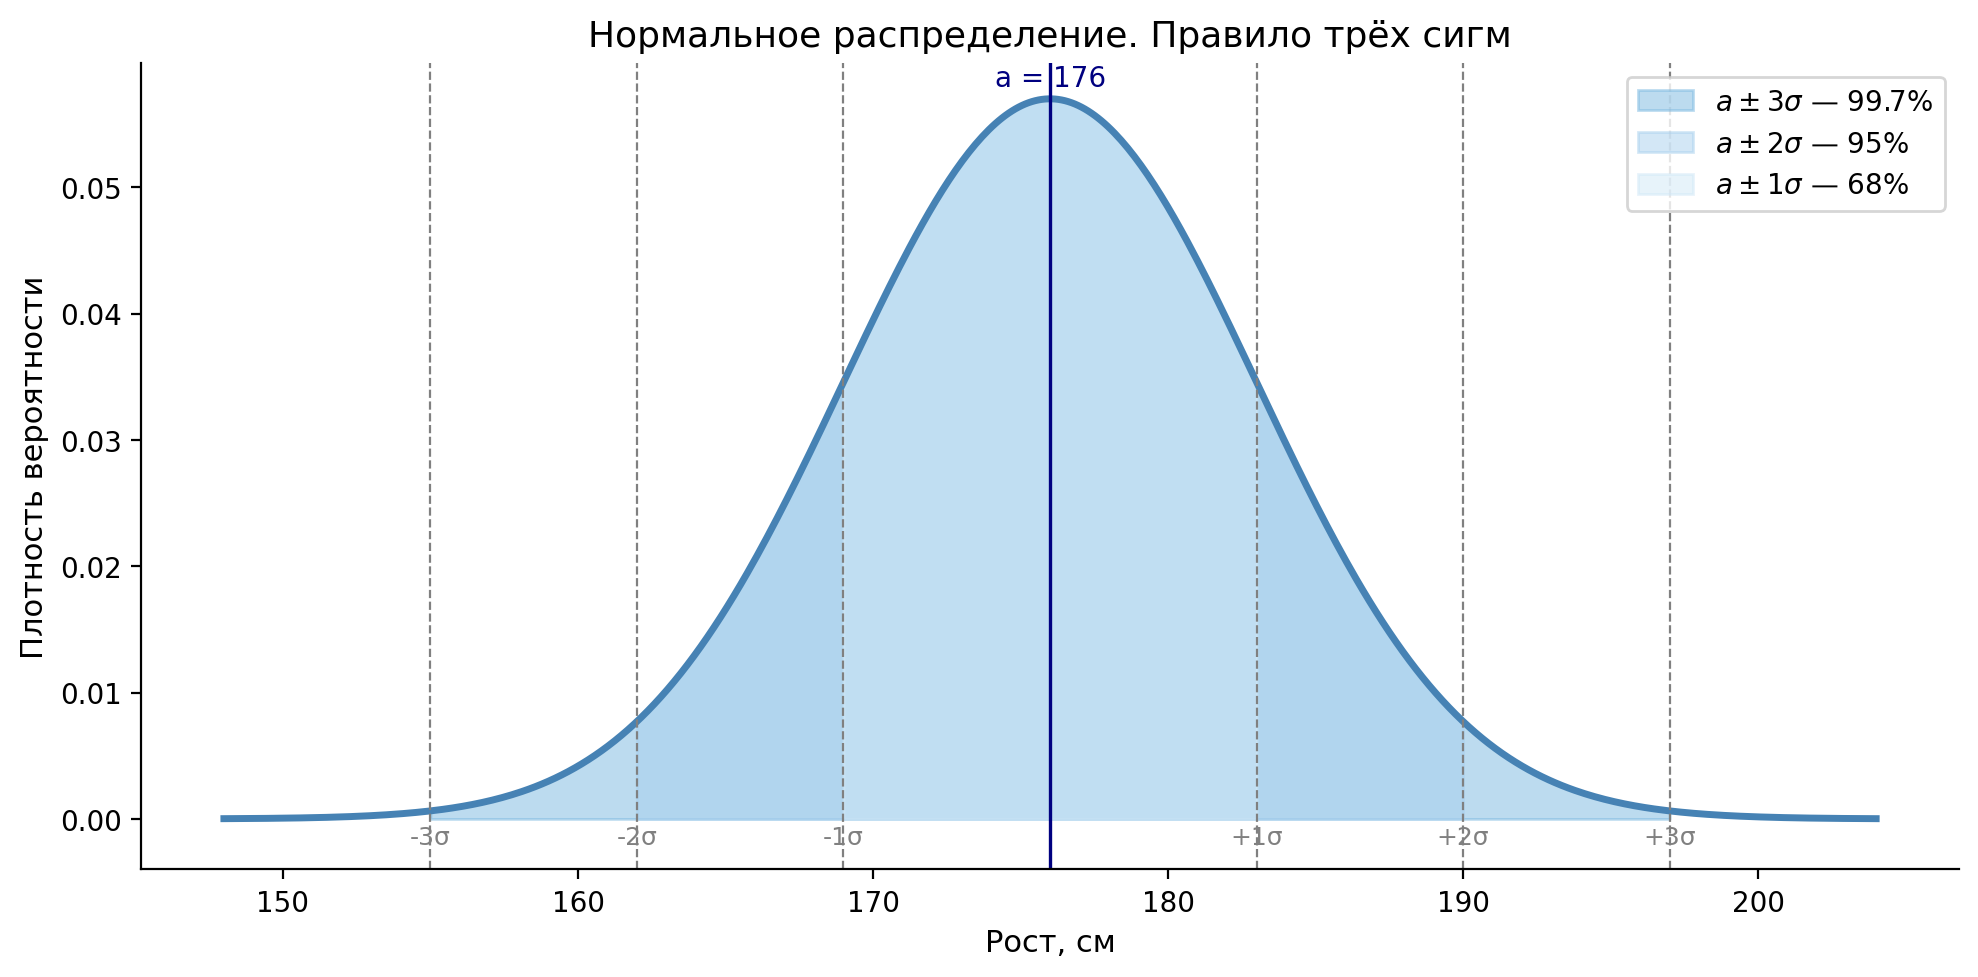

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

a, sigma = 176, 7
x = np.linspace(a - 4*sigma, a + 4*sigma, 500)
y = norm.pdf(x, a, sigma)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(x, y, color='steelblue', linewidth=2.5)

regions = [
    (1, '#d0e8f7', '68%'),
    (2, '#a8d0ee', '95%'),
    (3, '#7ab8e0', '99.7%'),
]
for k, color, label in reversed(regions):
    x_fill = np.linspace(a - k*sigma, a + k*sigma, 300)
    ax.fill_between(x_fill, norm.pdf(x_fill, a, sigma), alpha=0.5, color=color, label=f'$a \\pm {k}\\sigma$ — {label}')

for k in [1, 2, 3]:
    for sign in [-1, 1]:
        xv = a + sign * k * sigma
        ax.axvline(xv, color='gray', linewidth=0.8, linestyle='--')
        ax.text(xv, -0.002, f'{"+" if sign > 0 else "-"}{k}σ', ha='center', fontsize=9, color='gray')

ax.axvline(a, color='navy', linewidth=1.2, linestyle='-')
ax.text(a, norm.pdf(a, a, sigma) + 0.001, 'a = 176', ha='center', fontsize=10, color='navy')

ax.set_xlabel('Рост, см', fontsize=11)
ax.set_ylabel('Плотность вероятности', fontsize=11)
ax.set_title('Нормальное распределение. Правило трёх сигм', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(bottom=-0.004)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Формулы для расчёта ошибок и объёмов выборки (собственно-случайный отбор)

| Параметр | Повторный отбор | Бесповторный отбор |
|---|---|---|
| Средняя ошибка выборки *(для средней)* | $\mu_x = \sqrt{\dfrac{\sigma^2}{n}}$ | $\mu_x = \sqrt{\dfrac{\sigma^2}{n}\left(1 - \dfrac{n}{N}\right)}$ |
| Численность выборки *(при определении среднего признака)* | $n = \dfrac{t^2 \sigma^2}{\Delta_x^2}$ | $n = \dfrac{t^2 \sigma^2 N}{N \cdot \Delta_x^2 + t^2 \cdot \sigma^2}$ |

Где:
- $\sigma^2$ — выборочная (или генеральная) дисперсия
- $n$ — объём выборочной совокупности
- $N$ — объём генеральной совокупности
- $\Delta_x$ — предельная ошибка выборки
- $t$ — коэффициент доверия (при уровне доверия 95% → $t \approx 2$; при 99% → $t \approx 3$)

### Как это читать

При повторном отборе ошибка зависит только от дисперсии и размера выборки.

При бесповторном отборе добавляется множитель $(1 - n/N)$ — поправка на конечность генеральной совокупности. Чем больше доля охвата $n/N$, тем меньше ошибка. Если $n \ll N$, поправка близка к 1 и обе формулы совпадают.

*Пример:* нужно оценить средний доход по городу с точностью $\Delta_x = 5\,000$ руб., $\sigma^2 = 400\,000\,000$, $t = 2$ (95%):

$$n_{\text{повт}} = \frac{4 \cdot 400\,000\,000}{25\,000\,000} = 64 \text{ человека}$$

При бесповторном отборе из $N = 200$ человек:

$$n_{\text{безп}} = \frac{4 \cdot 400\,000\,000 \cdot 200}{200 \cdot 25\,000\,000 + 4 \cdot 400\,000\,000} \approx 49 \text{ человек}$$

Бесповторный отбор требует меньшей выборки для той же точности.

### Что такое коэффициент доверия t и уровень доверия

Уровень доверия — это вероятность (в %), с которой можно утверждать, что истинное значение параметра генеральной совокупности попало в наш доверительный интервал.

Проще: если провести исследование 100 раз с разными выборками — при уровне доверия 95% в 95 случаях из 100 истинное значение окажется внутри интервала.

Коэффициент доверия $t$ — это просто число, которое показывает, на сколько стандартных отклонений нужно отступить от среднего, чтобы «накрыть» нужный процент площади нормального распределения. Это прямое следствие правила трёх сигм:

| Уровень доверия | Коэффициент $t$ | Смысл |
|---|---|---|
| 68% | $t = 1$ | Отступаем на $1\sigma$ в каждую сторону |
| 90% | $t = 1{,}65$ | Отступаем на $1{,}65\sigma$ в каждую сторону |
| 95% | $t \approx 2$ (точно: 1,96) | Отступаем на $2\sigma$ в каждую сторону |
| 99% | $t \approx 3$ (точно: 2,58) | Отступаем на $3\sigma$ в каждую сторону |
| 99,7% | $t = 3$ | Классическое «правило трёх сигм» |

*Пример:* средний балл студентов в выборке — 75, $\mu_x = 3$ (средняя ошибка). При уровне доверия 95% ($t = 2$):

$$\Delta_x = t \cdot \mu_x = 2 \cdot 3 = 6$$

Доверительный интервал: $[75 - 6;\; 75 + 6] = [69;\; 81]$

Это значит: с вероятностью 95% средний балл по всей генеральной совокупности находится между 69 и 81.

Если нужна большая уверенность (99%, $t = 3$): интервал расширяется до $[66;\; 84]$ — больше уверенности, но меньше точности. Это фундаментальный компромисс статистики: чем увереннее — тем шире интервал.

### Пример расчёта средней ошибки выборки

В озере живёт 300 карпов. Это генеральная совокупность — $N = 300$.

Предположим, мы поймали всех 300 рыб и взвесили каждую. То есть $n = N = 300$.

Из этих данных мы можем точно вычислить:

- Среднее $\bar{x}$ — средний вес по всем 300 рыбам. Например, $\bar{x} = 1{,}8$ кг.
- Медиана — вес рыбы, которая стоит ровно посередине, если выстроить всех по весу. Половина рыб легче, половина тяжелее. Может отличаться от среднего, если есть несколько очень тяжёлых рыб, которые «тянут» среднее вверх.
- Мода — самый часто встречающийся вес. Например, больше всего рыб весят около 1,5 кг.
- Дисперсия $\sigma^2$ — насколько рыбы отличаются по весу друг от друга. Если все примерно одинаковые — дисперсия маленькая. Если разброс большой (от малька до огромного карпа) — дисперсия большая.
- Минимум и максимум — самая лёгкая и самая тяжёлая рыба.

Поскольку мы поймали всех ($n = N$), все эти числа **точные** — это не оценки, а истинные характеристики популяции.

---

### Если ловить не всех

Мы поймали 35 рыб, взвесили и отпустили обратно — $n = 35$.

Взвесив эти 35 рыб, мы посчитали среднее $\bar{x} = 1{,}8$ кг и дисперсию $\sigma^2 = 0{,}36$ кг² — прямо по нашей выборке. Стандартное отклонение $\sigma = 0{,}6$ кг.

Зная $\bar{x}$ и $\sigma$, мы можем на основе ЦПТ предположить, что вес карпов распределён нормально, и нарисовать этот колокол:

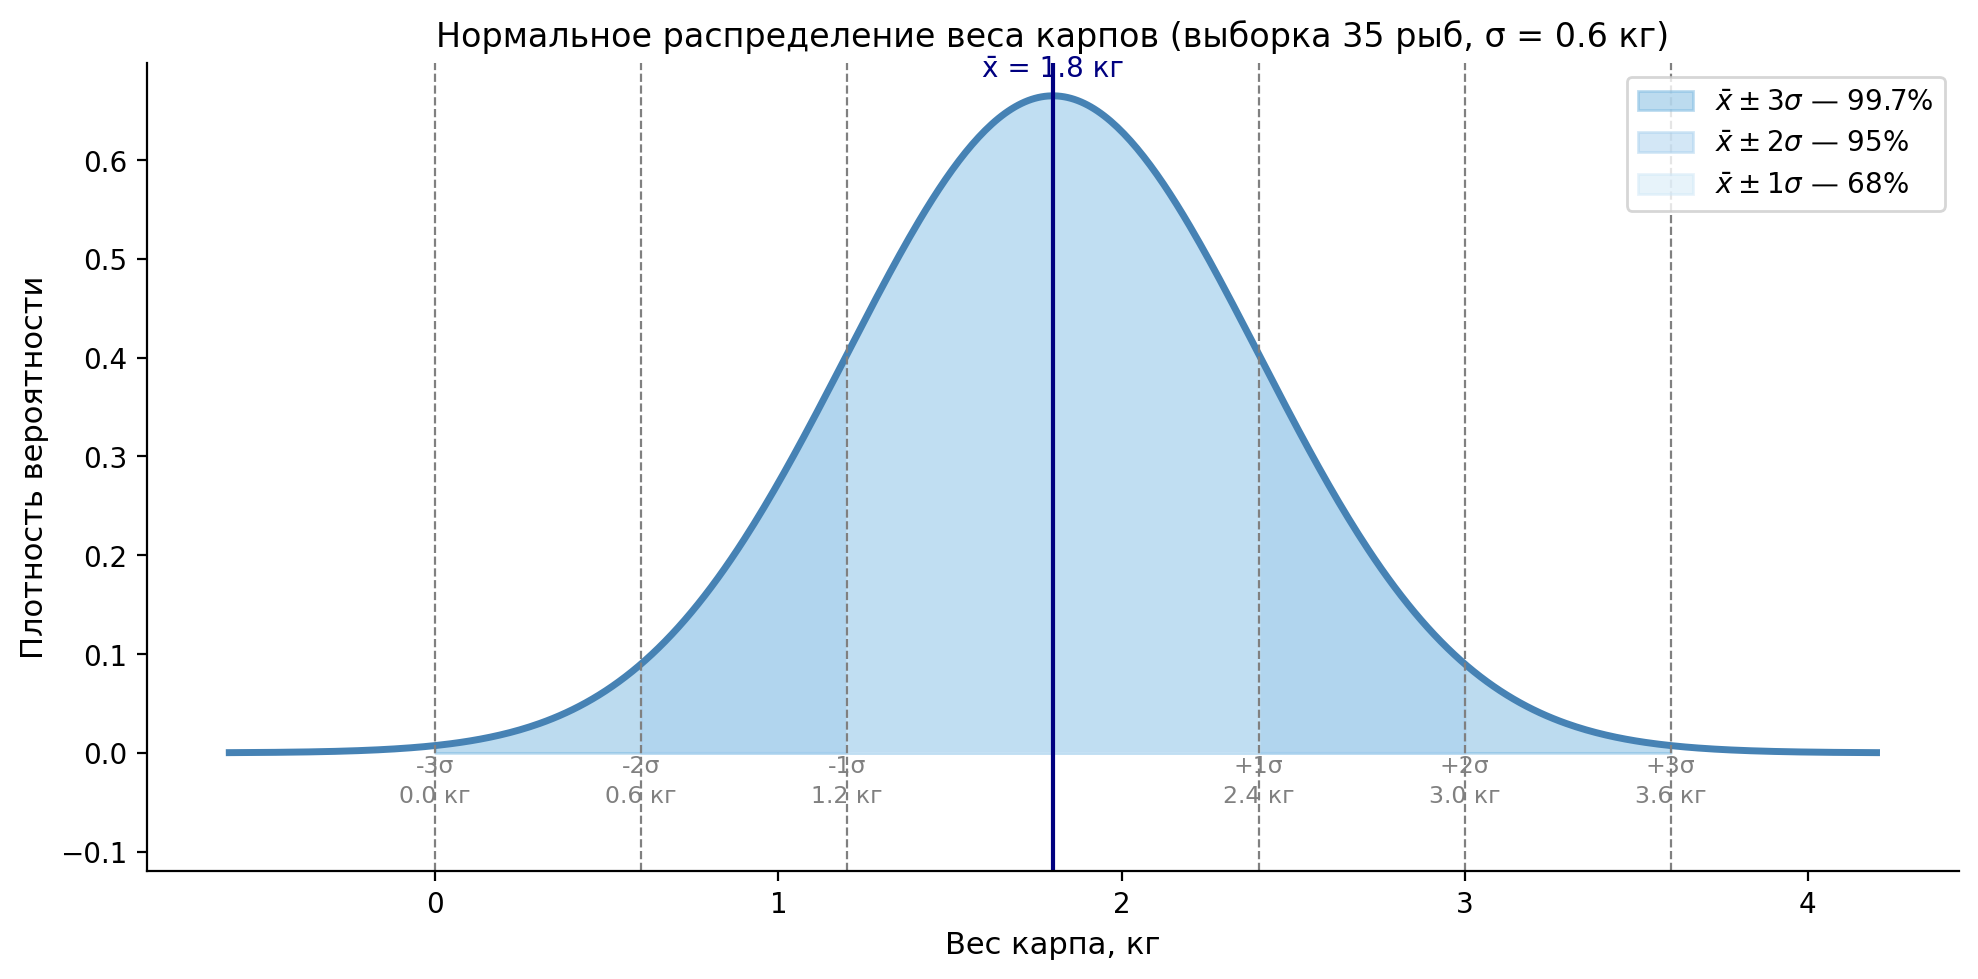

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x_bar = 1.8
sigma = 0.6

x = np.linspace(x_bar - 4*sigma, x_bar + 4*sigma, 500)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, norm.pdf(x, x_bar, sigma), color='steelblue', linewidth=2.5)

regions = [
    (1, '#d0e8f7', '68%'),
    (2, '#a8d0ee', '95%'),
    (3, '#7ab8e0', '99.7%'),
]
for k, color, label in reversed(regions):
    x_fill = np.linspace(x_bar - k*sigma, x_bar + k*sigma, 300)
    ax.fill_between(x_fill, norm.pdf(x_fill, x_bar, sigma), alpha=0.5, color=color, label=f'$\\bar{{x}} \\pm {k}\\sigma$ — {label}')

for k in [1, 2, 3]:
    for sign in [-1, 1]:
        xv = x_bar + sign * k * sigma
        ax.axvline(xv, color='gray', linewidth=0.8, linestyle='--')
        label = f'{"+" if sign > 0 else "-"}{k}σ\n{xv:.1f} кг'
        ax.text(xv, -0.05, label, ha='center', fontsize=8.5, color='gray', linespacing=1.4)

ax.axvline(x_bar, color='navy', linewidth=1.5, linestyle='-')
ax.text(x_bar, norm.pdf(x_bar, x_bar, sigma) + 0.02, f'x̄ = {x_bar} кг', ha='center', fontsize=10, color='navy')

ax.set_xlabel('Вес карпа, кг', fontsize=11)
ax.set_ylabel('Плотность вероятности', fontsize=11)
ax.set_title('Нормальное распределение веса карпов (выборка 35 рыб, σ = 0.6 кг)', fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(bottom=-0.12)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

Зная $n$, $N$ и $\sigma^2$, мы можем вычислить три вещи:

**1. Средняя ошибка выборки $\mu_x$** — насколько в среднем наше $\bar{x}$ может отличаться от истинного среднего по всему озеру:

$$\mu_x = \sqrt{\frac{\sigma^2}{n} \cdot \left(1 - \frac{n}{N}\right)} = \sqrt{\frac{0{,}36}{35} \cdot \left(1 - \frac{35}{300}\right)} = \sqrt{0{,}01029 \cdot 0{,}883} \approx 0{,}095 \text{ кг}$$

**2. Предельная ошибка $\Delta_x$** — конкретный «коридор» погрешности при уровне доверия 95% ($t = 2$):

$$\Delta_x = t \cdot \mu_x = 2 \cdot 0{,}095 = 0{,}19 \text{ кг}$$

**3. Доверительный интервал** — диапазон, в котором с вероятностью 95% находится истинное среднее (закрашенная область на графике выше):

$$[\bar{x} - \Delta_x;\; \bar{x} + \Delta_x] = [1{,}8 - 0{,}19;\; 1{,}8 + 0{,}19] = [1{,}61;\; 1{,}99] \text{ кг}$$

Вывод: поймав всего 35 рыб из 300, мы можем утверждать с вероятностью 95%, что средний карп в озере весит от 1,61 до 1,99 кг.

### Проблема нормального распределения для веса рыб

Нормальное распределение имеет бесконечные хвосты в обе стороны. Формально оно допускает отрицательные значения веса — что физически невозможно.

В нашем примере $\bar{x} = 1{,}8$ кг, $\sigma = 0{,}6$ кг, и $-3\sigma = 0{,}0$ кг — мы на самой границе. Если бы разброс был больше, колокол залез бы в отрицательную область.

Для величин, которые не могут быть отрицательными (вес, цена, время), лучше подходит **логнормальное распределение** — его левый хвост упирается в ноль и никогда не уходит в минус. Оно описывает данные, где не сами значения, а их логарифмы распределены нормально.

На практике для небольших относительных разбросов нормальное распределение даёт достаточно точные результаты, и им пользуются ради простоты. Но знать об этом ограничении важно.

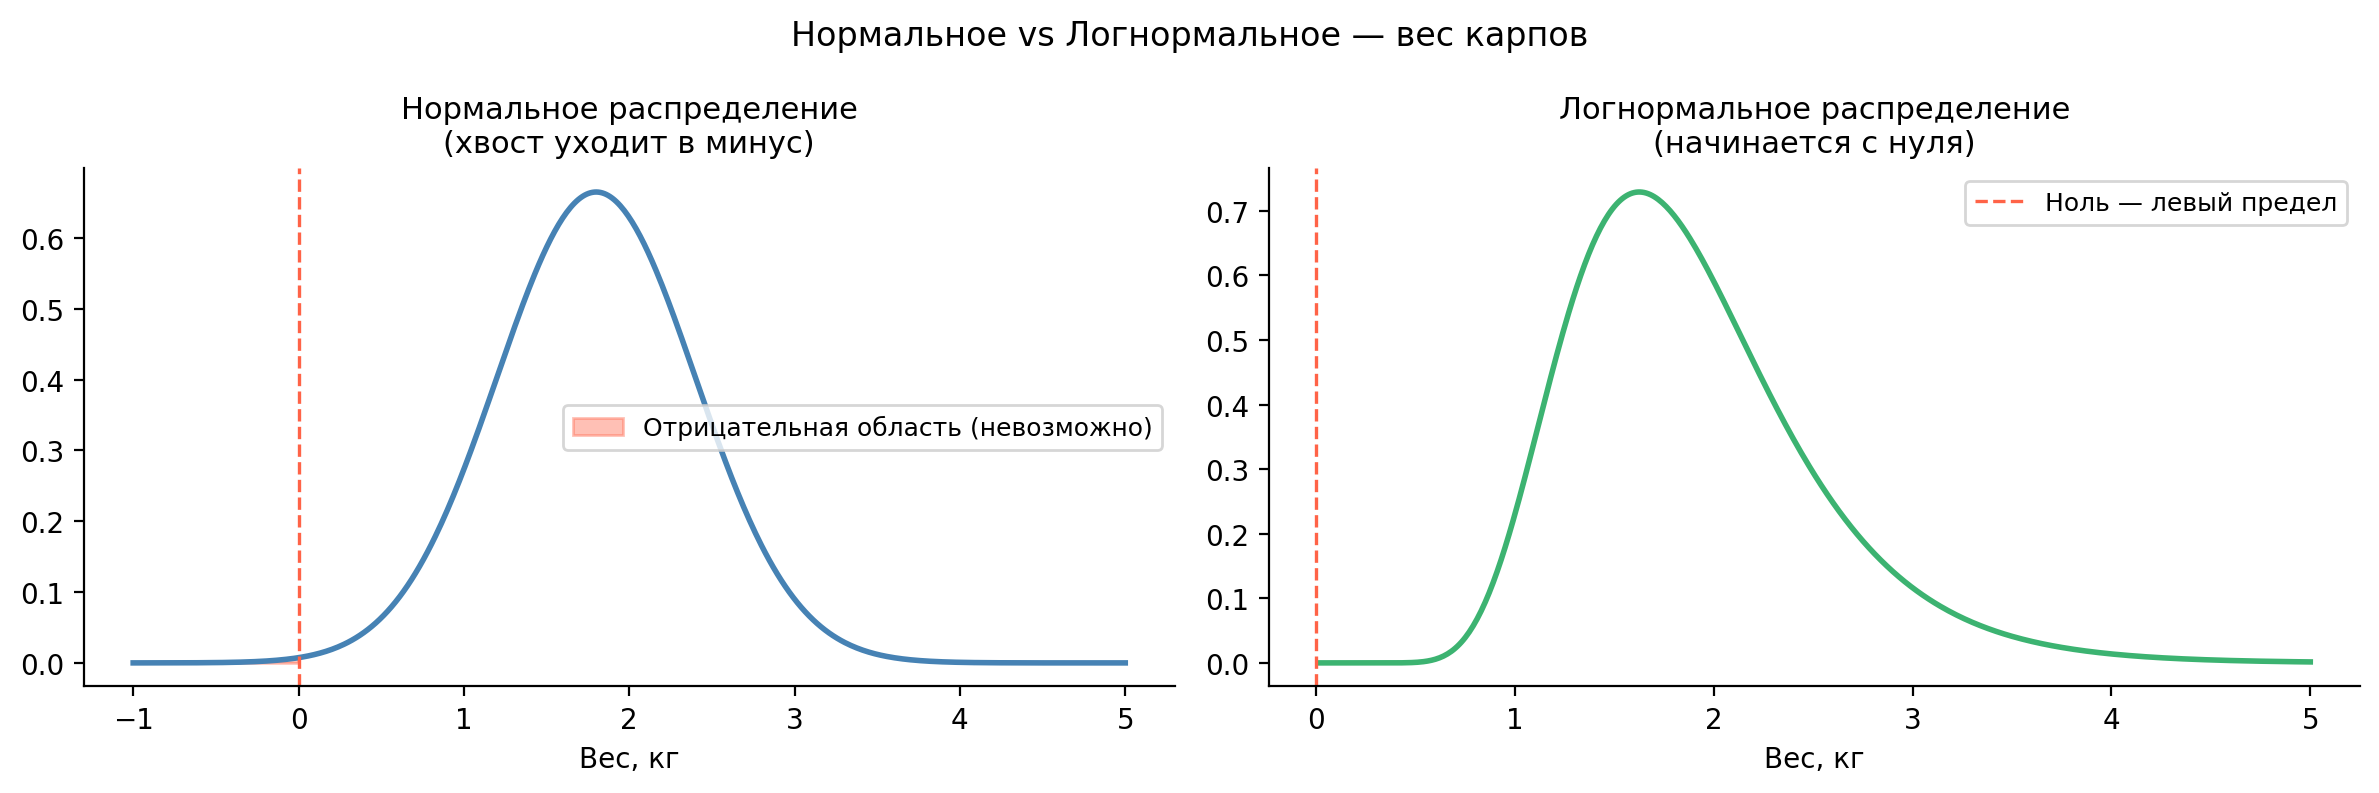

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

x = np.linspace(-1, 5, 500)

# Нормальное — уходит в минус
ax = axes[0]
mu, sigma = 1.8, 0.6
ax.plot(x, norm.pdf(x, mu, sigma), color='steelblue', linewidth=2)
ax.fill_between(x[x < 0], norm.pdf(x[x < 0], mu, sigma), alpha=0.4, color='tomato', label='Отрицательная область (невозможно)')
ax.axvline(0, color='tomato', linewidth=1.2, linestyle='--')
ax.set_title('Нормальное распределение\n(хвост уходит в минус)', fontsize=11)
ax.set_xlabel('Вес, кг')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# Логнормальное — начинается с нуля
ax = axes[1]
# Параметры логнормального, чтобы медиана ≈ 1.8 кг
s = 0.32  # shape (дисперсия логарифма)
scale = 1.8
x2 = np.linspace(0.01, 5, 500)
ax.plot(x2, lognorm.pdf(x2, s=s, scale=scale), color='mediumseagreen', linewidth=2)
ax.axvline(0, color='tomato', linewidth=1.2, linestyle='--', label='Ноль — левый предел')
ax.set_title('Логнормальное распределение\n(начинается с нуля)', fontsize=11)
ax.set_xlabel('Вес, кг')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Нормальное vs Логнормальное — вес карпов', fontsize=12)
plt.tight_layout()
plt.show()

### Как выводятся формулы численности выборки

Обе формулы — это просто решение формулы предельной ошибки относительно $n$.

---

**Повторный отбор**

Начинаем с формулы предельной ошибки:

$$\Delta_x = t \cdot \mu_x = t \cdot \sqrt{\frac{\sigma^2}{n}}$$

Делим обе части на $t$, возводим в квадрат:

$$\frac{\Delta_x^2}{t^2} = \frac{\sigma^2}{n}$$

Отсюда:

$$\boxed{n = \frac{t^2 \sigma^2}{\Delta_x^2}}$$

---

**Бесповторный отбор**

Начинаем с:

$$\Delta_x = t \cdot \sqrt{\frac{\sigma^2}{n}\left(1 - \frac{n}{N}\right)}$$

Делим на $t$, возводим в квадрат:

$$\frac{\Delta_x^2}{t^2} = \frac{\sigma^2}{n} - \frac{\sigma^2}{N}$$

Переносим $\dfrac{\sigma^2}{N}$ влево:

$$\frac{\Delta_x^2}{t^2} + \frac{\sigma^2}{N} = \frac{\sigma^2}{n}$$

Отсюда:

$$n = \frac{\sigma^2}{\dfrac{\Delta_x^2}{t^2} + \dfrac{\sigma^2}{N}}$$

Умножаем числитель и знаменатель на $t^2 N$:

$$\boxed{n = \frac{t^2 \sigma^2 N}{N \cdot \Delta_x^2 + t^2 \cdot \sigma^2}}$$

## Сводка и группировка

Сводка — стадия, на которой осуществляется систематизация первичных материалов статистического наблюдения.

Группировка — объединение единиц совокупности в некоторые группы, имеющие свои характерные особенности, общие черты и сходные размеры изучаемого признака.

Виды группировок:

- Типологическая
- Структурная
- Аналитическая

### Данные не сгруппированы

| № предприятия | Выручка от реализации, млн.руб. | Прибыль предприятия, тыс.руб. |
|---|---|---|
| 1 | 2,0 | 1270 |
| 2 | 2,0 | 1320 |
| 3 | 2,7 | 1250 |
| 4 | 2,8 | 1330 |
| 5 | 3,0 | 1410 |

### Аналитическая группировка

Выявляет взаимосвязь между двумя признаками: факторным (по которому группируем) и результативным (который изучаем в каждой группе). Показывает, как меняется результат при изменении фактора.

*Пример:* группируем предприятия по выручке и смотрим, как меняется средняя прибыль в каждой группе.

| Группы заводов по выручке от реализации, млн. руб. | Прибыль предприятия в среднем по группе, тыс.руб. |
|---|---|
| 2,6 — 3,6 | 1335,33 |
| 3,6 — 4,6 | 1452,00 |
| 4,6 — 5,6 | 1402,00 |
| 5,6 — 6,6 | 1512,00 |
| 6,6 — 7,6 | 1448,67 |

### Типологическая группировка

Делит совокупность на качественно однородные типы или классы по существенному признаку.

*Пример:* предприятия делятся по форме хозяйствования — это качественный признак.

| Группы предприятий по формам хозяйствования | Объём промышленной продукции, млн. руб. |
|---|---|
| Государственные с традиционными формами управления | 405,5 |
| Арендные | 19 |
| Кооперативные | 30 |

### Аналитическая группировка на основе типологической

Те же типологические группы, но теперь для каждой считается результативный показатель — средняя зарплата. Видно, что форма хозяйствования влияет на уровень оплаты труда.

| Группы предприятий по формам хозяйствования | Средняя заработная плата на предприятии, руб. |
|---|---|
| Государственные с традиционными формами управления | 2405,5 |
| Арендные | 3319,8 |
| Кооперативные | 5630,6 |

### Структурная группировка

Показывает распределение единиц совокупности по группам — сколько их и какой удельный вес занимает каждая группа в общем итоге.

*Пример:* те же группы заводов по выручке, но считаем количество заводов в каждой группе и их долю.

| Группы заводов по выручке от реализации | Число заводов (fᵢ) | Уд. вес заводов по группе |
|---|---|---|
| 2,6 — 3,6 | 6 | 30,00% |
| 3,6 — 4,6 | 9 | 45,00% |
| 4,6 — 5,6 | 1 | 5,00% |
| 5,6 — 6,6 | 1 | 5,00% |
| 6,6 — 7,6 | 3 | 15,00% |
| **Итого** | **20** | **100,00%** |

### Последовательность выполнения группировки по количественному признаку

1. Выбор группировочного признака
2. Расчёт числа групп
3. Расчёт шага или длины интервала
4. Построение интервалов
5. Подсчёт численности групп
6. Расчёт удельных весов для структурных группировок или средних значений признака в группе для аналитических
7. Построение таблиц

# Формула Стёрджиса

## Откуда берётся

Герберт Стёрджис предложил формулу в 1926 году. Рассуждение простое: представим, что данные распределены по биномиальному закону. Тогда для $N$ наблюдений нам нужно $k$ классов такое, что:

$$2^{k-1} \approx N$$

Отсюда:

$$k - 1 = \log_2 N \implies k = 1 + \log_2 N$$

Это **эмпирическое правило**, не строгая математика — просто удобный ориентир.

## Три эквивалентные записи

$$k = 1 + 3{,}322 \cdot \lg N$$

$$k = 1 + 1{,}44 \cdot \ln N$$

$$k = 1 + \log_2 N$$

Все три одинаковы, так как $\log_2 N = \dfrac{\lg N}{\lg 2} \approx 3{,}322 \cdot \lg N = \dfrac{\ln N}{\ln 2} \approx 1{,}44 \cdot \ln N$.

Результат округляется до целого числа.

## Ширина интервала

После нахождения числа классов вычисляется ширина интервала:

$$h = \frac{X_{\max} - X_{\min}}{k}$$

### Построение интервалов

Интервалы строятся последовательно от $x_{min}$ до $x_{max}$ с шагом $h$:

```mermaid
flowchart LR
    A["[x_min ; x_min + h]"]
    B["(x_min + h ; x_min + 2h]"]
    C["..."]
    D["(x_max − h ; x_max]"]

    A --> B --> C --> D
```

Первый интервал закрыт слева (`[`), все последующие — открыты слева (`(`) и закрыты справа (`]`).

### Пример: группировка по стажу работы

**Условие:** имеются данные по 30 работникам организации. Осуществить группировку по стажу, построить дискретный и интервальный ряды.

**Дискретный ряд** — исходные данные без группировки:

| Стаж работы, лет | Число работников, чел. |
|---|---|
| 2 | 1 |
| 3 | 2 |
| 4 | 2 |
| 5 | 3 |
| 6 | 3 |
| 7 | 5 |
| 8 | 7 |
| 9 | 3 |
| 10 | 2 |
| 11 | 1 |
| 12 | 1 |
| **Итого** | **30** |

**Интервальный ряд:**

Шаг 1 — число групп по формуле Стёрджиса:

$$k = [1 + 3{,}322 \cdot \lg 30] = [5{,}91] = 5$$

Шаг 2 — ширина интервала:

$$h = \frac{x_{max} - x_{min}}{k} = \frac{12 - 2}{5} = 2 \text{ года}$$

Шаг 3 — строим интервалы и считаем численность каждой группы:

| Группа (стаж, лет) | Число работников, чел. | Удельный вес |
|---|---|---|
| [2 ; 4) | 1 + 2 = 3 | 10,0% |
| [4 ; 6) | 2 + 3 = 5 | 16,7% |
| [6 ; 8) | 3 + 5 = 8 | 26,7% |
| [8 ; 10) | 7 + 3 = 10 | 33,3% |
| [10 ; 12] | 2 + 1 + 1 = 4 | 13,3% |
| **Итого** | **30** | **100%** |

Наибольшая доля работников (33,3%) имеет стаж от 8 до 10 лет.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
data = rng.normal(loc=170, scale=10, size=500)  # рост 100 человек, см

N = len(data)

k_lg   = int(np.ceil(1 + 3.322  * np.log10(N)))
k_ln   = int(np.ceil(1 + 1.4427 * np.log(N)))
k_log2 = int(np.ceil(1 + np.log2(N)))

h = (data.max() - data.min()) / k_lg

print(f'N = {N}')
print(f'k = 1 + 3,322 × lg({N})  = 1 + 3,322 × {np.log10(N):.3f}  ≈ {k_lg}')
print(f'k = 1 + 1,44  × ln({N})  = 1 + 1,44  × {np.log(N):.3f}  ≈ {k_ln}')
print(f'k = 1 + log2({N})         = 1 + {np.log2(N):.3f}          ≈ {k_log2}')
print(f'h = (Xmax - Xmin) / k    = ({data.max():.2f} - {data.min():.2f}) / {k_lg} ≈ {h:.2f} см')

N = 500
k = 1 + 3,322 × lg(500)  = 1 + 3,322 × 2.699  ≈ 10
k = 1 + 1,44  × ln(500)  = 1 + 1,44  × 6.215  ≈ 10
k = 1 + log2(500)         = 1 + 8.966          ≈ 10
h = (Xmax - Xmin) / k    = (199.14 - 144.33) / 10 ≈ 5.48 см


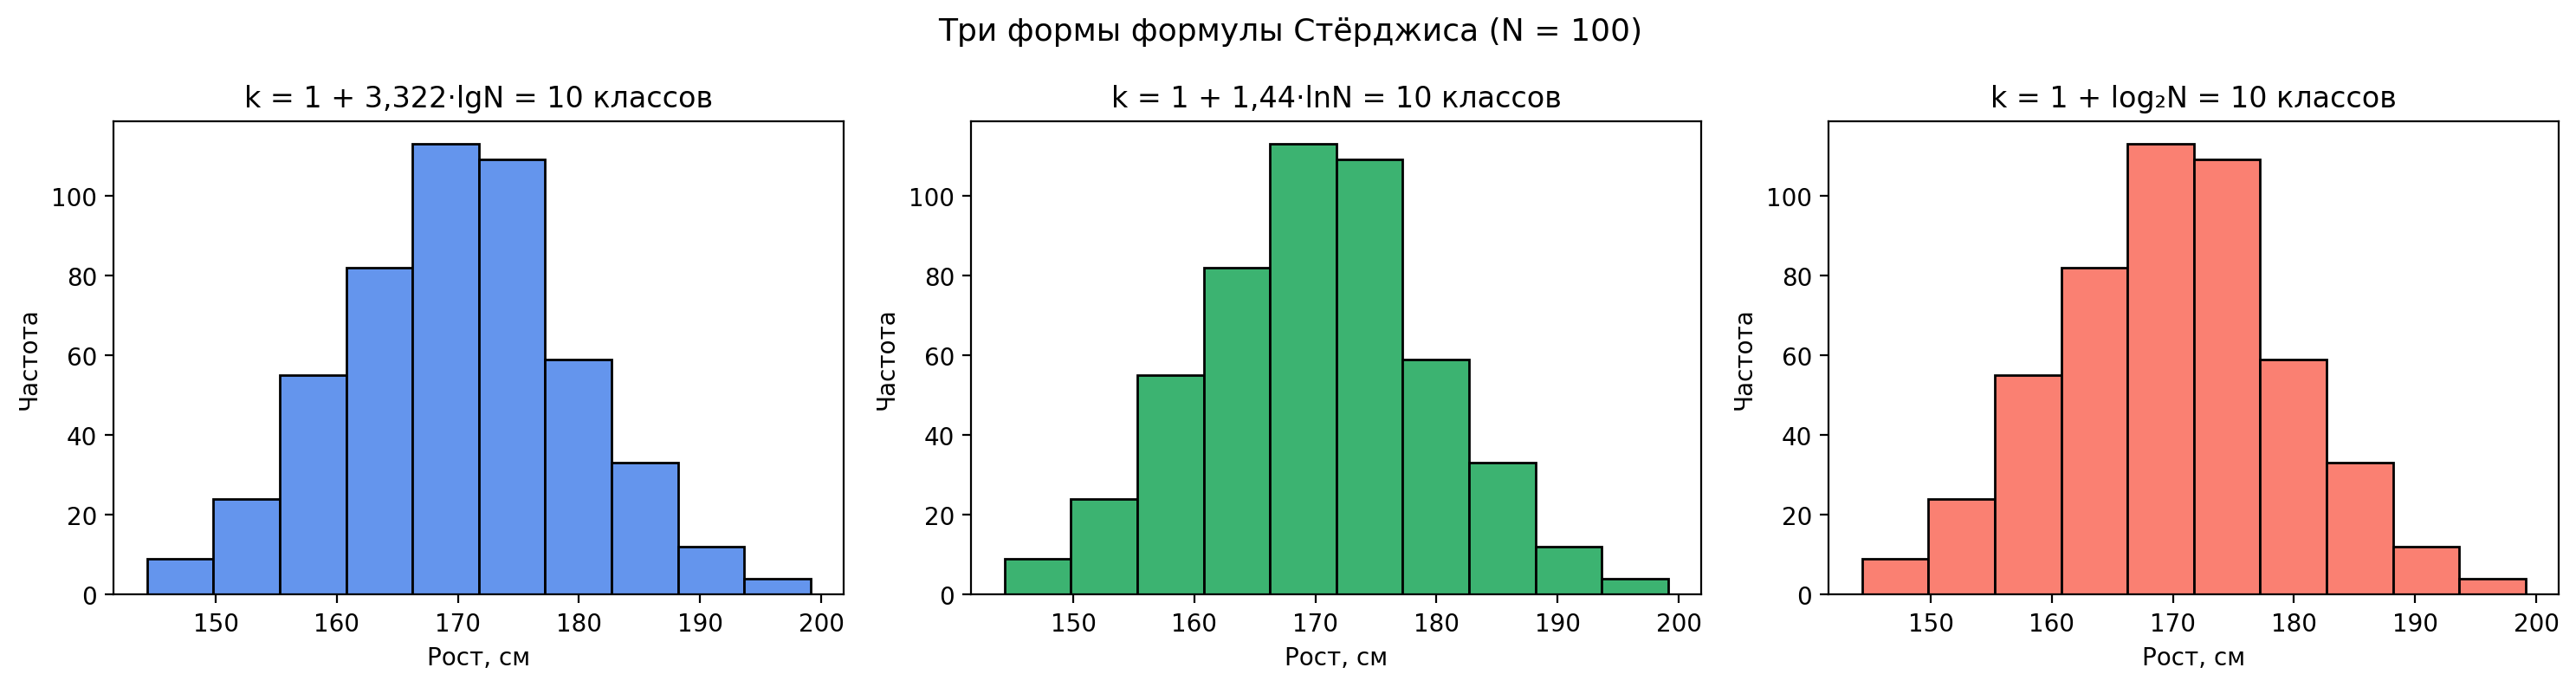

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

configs = [
    (k_lg,   'cornflowerblue', 'k = 1 + 3,322·lgN'),
    (k_ln,   'mediumseagreen', 'k = 1 + 1,44·lnN'),
    (k_log2, 'salmon',         'k = 1 + log₂N'),
]

for ax, (k, color, title) in zip(axes, configs):
    ax.hist(data, bins=k, edgecolor='black', color=color)
    ax.set_title(f'{title} = {k} классов')
    ax.set_xlabel('Рост, см')
    ax.set_ylabel('Частота')

plt.suptitle('Три формы формулы Стёрджиса (N = 100)', fontsize=13)
plt.tight_layout()
plt.show()

## Зависимость числа классов от объёма выборки

In [7]:
sample_sizes = [10, 25, 50, 100, 200, 500, 1000]

print(f'{'N':>6}  {'1+3,322·lgN':>12}  {'1+1,44·lnN':>11}  {'1+log2N':>8}')
print('-' * 44)
for n in sample_sizes:
    k1 = int(np.ceil(1 + 3.322  * np.log10(n)))
    k2 = int(np.ceil(1 + 1.4427 * np.log(n)))
    k3 = int(np.ceil(1 + np.log2(n)))
    print(f'{n:>6}  {k1:>12}  {k2:>11}  {k3:>8}')

     N   1+3,322·lgN   1+1,44·lnN   1+log2N
--------------------------------------------
    10             5            5         5
    25             6            6         6
    50             7            7         7
   100             8            8         8
   200             9            9         9
   500            10           10        10
  1000            11           11        11


## Статистические показатели

```mermaid
flowchart LR
    A[Статистические показатели] --> B[Абсолютные]
    A --> C[Относительные]
```

**Абсолютные** — суммарные обобщающие показатели, характеризующие размеры изучаемых явлений в конкретных условиях места и времени.

- Исходная, первичная, самая общая форма выражения статистического показателя — числа, взятые из таблиц без преобразований.
- Именованные величины, выраженные через единицы измерения (штуки, рубли, кг, человеко-часы и т.д.).

**Относительные** — производные обобщающие показатели, получаемые в результате деления одних абсолютных показателей на другие.

- Позволяют проводить сравнение различных показателей.
- Как правило, измеряются в безразмерных коэффициентах или процентах.

### Относительная величина

Относительный статистический показатель = сравниваемая величина / база относительного сравнения

Величина, с которой производится сравнение (знаменатель дроби), называется **базой сравнения** или **основанием**. В зависимости от базы сравнения относительные величины выражаются в виде:

- коэффициента, если база принимается за единицу;
- процентов (%), если база принята за 100;
- промилле (‰), если база принята за 1000.

### Виды единиц измерения

- Натуральные:
    - Простые (штуки, тонны, метры...)
    - Сложные (составные) — комбинация двух разноимённых величин (тоннокилометры, килограммы/кубометры...)
- Условно-натуральные (например, условный печатный лист, стакан как мера объёма...)
- Стоимостные — позволяют соизмерить в денежной форме товары, которые нельзя соизмерить в натуральной форме

---

Количество единиц с одинаковым значением признака обозначается обычно $f$ и называется **частота**:

$$\sum f = N$$

### Виды относительных статистических показателей

**Интенсивные показатели (И.П.)** — отражают частоту встречаемости явления в среде.

$$\text{И.П.} = \frac{\text{явление}}{\text{среда}} \cdot k$$

где $k$ — основание (коэффициент), обычно принимает значение 100, 1000, 10 000, 100 000 (чем реже явление, тем больше основание).

---

**Экстенсивные показатели (Э.П.)** — характеризуют распределение целого на составляющие его части по их удельному весу, раскрывают внутреннюю структуру изучаемого явления.

$$\text{Э.П.} = \frac{\text{часть}}{\text{целое}} \cdot 100\%$$

---

**Показатели соотношения (П.С.)** — характеризуют численное соотношение двух не связанных между собой совокупностей, сопоставляемых только логически по их содержанию.

$$\text{П.С.} = \frac{\text{1-я совокупность}}{\text{2-я совокупность}} \cdot k$$

---

**Показатели наглядности (П.Н.)** — относительная величина, указывающая на соотношение однородных показателей для разных групп или разных периодов, вычисляемая путём принятия одной из сравниваемых величин за 100 (реже за 1000, 10 000 и т.п.).

$$\text{П.Н.} = \frac{\text{показатель текущего года}}{\text{показатель базового года}} \cdot 100\%$$

### Статистические показатели. Классификация 2

| № | Вид показателя | Формула |
|---|---|---|
| 1 | Установления планового задания | $y_{pl} / y_0$ |
| 2 | Выполнения планового задания | $y_1 / y_{pl}$ |
| 3 | Динамики | $y_1 / y_0$ |
| 4 | Сравнения | $y_a / y_b$ |
| 5 | Структуры | $y_i / \sum y_i$ |
| 6 | Координации | $y_i / y_j$ |
| 7 | Интенсивности | $\sum a / \sum b$ |

где $y_0$ — базовый период, $y_1$ — текущий период, $y_{pl}$ — плановый показатель, $y_a, y_b$ — сравниваемые объекты.

## Вариация

```mermaid
flowchart LR
    A([Статистический признак\nили показатель]) --> B[ВАРИАЦИЯ]
    B --> C["Различие в значениях одного\nи того же признака у\nразных единиц совокупности"]
```

## Построение ряда вариационного распределения

Статистические ряды распределения состоят из двух элементов: **вариант** и **частот**.

**Варианта** — каждое отдельное значение признака, которое он принимает в статистическом ряду распределения.

**Частоты** — числовые значения, показывающие, как часто встречаются те или иные варианты в ряду распределения. Могут быть выражены в абсолютных величинах, долях единицы или процентах к итоговому значению наблюдаемого признака.

Переменная величина x может принимать различные значения x₁, x₂, x₃, ..., xₙ. Каждое из этих значений имеет свою частоту повторений f₁, f₂, f₃, ..., fₙ. Такой двойной ряд ранжированных значений признака называется **вариационным рядом, или рядом распределения**.

Для атрибутивного ряда каждая варианта регистрируется в виде текстовой записи с указанием соответствующей частоты повторения.

### Ряды распределения

**Ранжированный ряд (вариационный)** — перечень отдельных единиц совокупности в порядке возрастания изучаемого признака.

**Дискретный ряд** — таблица из двух столбцов: конкретные значения варьирующего признака Xᵢ и число единиц совокупности с данным значением признака fᵢ (частоты). Число групп определяется числом реально существующих значений варьирующего признака.

**Интервальный ряд** — таблица из двух столбцов: интервалы варьирующего признака Xᵢ и число единиц совокупности, попадающих в данный интервал (частоты), или доля этого числа в общей численности совокупностей.

## Понятие средней величины

**Средняя величина** — обобщающий показатель, характеризующий значение признака, вокруг которого концентрируются наблюдения.

Средняя величина всегда обобщает количественное выражение признака и погашает индивидуальные различия статистических величин совокупности, вызванные случайными обстоятельствами.

Средней арифметической величиной называется такое среднее значение признака, при вычислении которого общий объём признака в совокупности сохраняется неизменным.

### Виды средних величин

**Структурные** средние величины — медиана, мода и др.

**Аналитические** средние величины (средняя степенная):
- средняя арифметическая
- средняя гармоническая
- средняя геометрическая
- средняя квадратическая

### Категории средних

```mermaid
flowchart TD
    K[Категории средних]

    K --> ST[Степенные средние]
    K --> SR[Структурные средние]
    K --> SH[Средняя хронологическая]

    ST --> A[Средняя арифметическая]
    ST --> G[Средняя геометрическая]
    ST --> H[Средняя гармоническая]
    ST --> Q[Средняя квадратическая]

    SR --> Mo[Мода]
    SR --> Me[Медиана]
```

## Медиана

**Медиана** — вариант, приходящийся на середину вариационного ряда.

### Дискретный вариационный ряд

Пусть $n$ — общее число наблюдений, $j = \lceil n/2 \rceil$:

- Если $n = 2j - 1$ (нечётное): $\widetilde{Me} = x_j$
- Если $n = 2j$ (чётное): $\widetilde{Me} = \dfrac{1}{2}(x_j + x_{j+1})$

То есть при нечётном $n$ медиана — центральный элемент; при чётном — среднее двух центральных.

**Пример:**

| $x_i$ | 13 | 14 | 15 | 16 | 17 |
|---|---|---|---|---|---|
| $f_i$ | 12 | 22 | **28** | 30 | 8 |

Всего: $n = 12 + 22 + 28 + 30 + 8 = 100$ наблюдений.

Накопленные частоты: 12 → 34 → **62** → 92 → 100.

Нужно найти, где накопленная частота впервые превышает $n/2 = 50$. Это происходит в группе $x = 15$ (накоплено 62 > 50).

$\widetilde{Me} = 15$

### Медиана для интервального вариационного ряда

**Медианный интервал** — интервал, в котором накопленная частота равна или превышает полусумму всех частот ряда.

$$\widetilde{Me} = x_{min} + d \cdot \frac{\dfrac{1}{2}\sum_{i=1}^{k} f_i - \sum_{i=1}^{i_{Me}-1} f_i}{f_{Me}}$$

где:
- $d = x_{max} - x_{min}$ — ширина медианного интервала
- $f_{Me}$ — частота медианного интервала
- $\sum_{i=1}^{i_{Me}-1} f_i$ — сумма накопленных частот до медианного интервала

**Пример:** распределение зарплат:

| Зарплата, тыс. р | Частоты $f_i$ | Накопленные частоты |
|---|---|---|
| 10–150 | 20 | 20 |
| 150–200 | 50 | 70 |
| 200–250 | 100 | 170 |
| **250–300** | **115** | **285** |
| 300–350 | 180 | 465 |
| 350–400 | 45 | 510 |
| Сумма | 510 | — |

Полусумма частот: $510 / 2 = 255$. Накопленная частота впервые превышает 255 в интервале **250–300** (накоплено 285). Это медианный интервал.

$$\widetilde{Me} = 250 + 50 \cdot \frac{255 - 170}{115} = 250 + 50 \cdot \frac{85}{115} \approx 286{,}96 \text{ тыс. р}$$

## Деление ряда. Порядковая статистика

Значения признака, делящие ряд на равные части:

| Число частей | Название |
|---|---|
| 4 | Квартили |
| 5 | Квинтили |
| 10 | Децили |
| 100 | Перцентили |

## Квартили

Более общая постановка вариант, занимающих определённое место в ранжированном ряду, называется **порядковой статистикой**.

**Квартиль** — значения признака, которые делят ранжированный ряд на четыре равные по численности части. Таких величин три: $Q_1$, $Q_2$, $Q_3$. Вторая квартиль $Q_2$ является медианой.

Место квартили (номер элемента в ранжированном ряду):

$$N_{Q_1} = \frac{\sum f_i}{4} \qquad N_{Q_2} = \frac{2\sum f_i}{4} \qquad N_{Q_3} = \frac{3\sum f_i}{4}$$

**Пример:** рост 7 студентов (ранжированный ряд), см: 162, 165, 168, **172**, 175, 178, 183.

$\sum f_i = 7$

$$N_{Q_1} = \frac{7}{4} = 1{,}75 \rightarrow \text{позиция 2} \Rightarrow Q_1 = 165 \text{ см}$$

$$N_{Q_2} = \frac{2 \cdot 7}{4} = 3{,}5 \rightarrow \text{позиция 4} \Rightarrow Q_2 = 172 \text{ см (медиана)}$$

$$N_{Q_3} = \frac{3 \cdot 7}{4} = 5{,}25 \rightarrow \text{позиция 6} \Rightarrow Q_3 = 178 \text{ см}$$

Дробный номер округляется вверх — берётся ближайший элемент справа.

### Формулы квартилей для интервального ряда

**Нижний квартиль:**

$$Q_1 = x_0 + i \cdot \frac{\dfrac{\sum f_i}{4} - S_{Q_1}}{f_{Q_1}}$$

**Верхний квартиль:**

$$Q_3 = x_0 + i \cdot \frac{\dfrac{3\sum f_i}{4} - S_{Q_3}}{f_{Q_3}}$$

где:
- $x_0$ — нижняя граница квартильного интервала
- $i$ — величина интервала
- $f_i$ — частоты интервального ряда
- $S_{Q_1}$, $S_{Q_3}$ — сумма накопленных частот в интервалах, предшествующих квартильному
- $f_{Q_1}$, $f_{Q_3}$ — частота квартильного интервала

### Пример: квартили распределения учащихся по росту

**Условие:** дан интервальный ряд распределения 50 учащихся по росту. Определить нижний, верхний квартиль и медиану.

| Рост, см | Число учащихся $f_i$ | Накопленные частоты |
|---|---|---|
| 160–165 | 3 | 3 |
| 165–170 | 7 | 10 |
| **170–175** | **16** | **26** |
| 175–180 | 10 | 36 |
| **180–185** | **9** | **45** |
| 185–190 | 3 | 48 |
| 190–195 | 2 | 50 |
| Всего | 50 | — |

**Нижний квартиль $Q_1$:** место $N_{Q_1} = 50/4 = 12{,}5$ → интервал **170–175** (накоплено 26 > 12,5; предыдущий итог 10)

$$Q_1 = 170 + 5 \cdot \frac{12{,}5 - 10}{16} \approx 170{,}8 \text{ см}$$

**Медиана $Q_2$:** место $N_{Q_2} = 50/2 = 25$ → интервал **170–175** (накоплено 26 > 25; предыдущий итог 10)

$$Q_2 = 170 + 5 \cdot \frac{25 - 10}{16} \approx 174{,}7 \text{ см}$$

**Верхний квартиль $Q_3$:** место $N_{Q_3} = 3 \cdot 50/4 = 37{,}5$ → интервал **180–185** (накоплено 45 > 37,5; предыдущий итог 36)

$$Q_3 = 180 + 5 \cdot \frac{37{,}5 - 36}{9} \approx 180{,}8 \text{ см}$$

## Мода

**Мода** $\widetilde{Mo}$ — вариант, имеющий наибольшую частоту встречаемости $f_i$ вариационного ряда.

### Дискретный вариационный ряд

| $x_i$ | 13 | 14 | 15 | **16** | 17 |
|---|---|---|---|---|---|
| $f_i$ | 12 | 22 | 28 | **30** | 8 |

$\widetilde{Mo} = 16$ — значение с наибольшей частотой (30).

### Интервальный вариационный ряд

$$\widetilde{Mo} = x_{min} + d \cdot \frac{f_{Mo} - f_{Mo-1}}{(f_{Mo} - f_{Mo-1}) + (f_{Mo} - f_{Mo+1})}$$

где $d = x_{max} - x_{min}$ — ширина модального интервала, $f_{Mo}$ — его частота, $f_{Mo-1}$ и $f_{Mo+1}$ — частоты предыдущего и следующего интервалов.

**Пример:**

| $x_i$ | 100–120 | **120–140** | 140–160 | 160–180 |
|---|---|---|---|---|
| $m_i$ | 9 | **16** | 11 | 4 |

Модальный интервал — **120–140** (наибольшая частота 16).

$$\widetilde{Mo} = 120 + 20 \cdot \frac{16 - 9}{(16 - 9) + (16 - 11)} = 120 + 20 \cdot \frac{7}{7 + 5} \approx 131{,}67$$

## Аналитические средние величины

### Средняя степенная

$$\bar{x}_\alpha = \left(\frac{x_1^\alpha + x_2^\alpha + \cdots + x_n^\alpha}{n}\right)^{\frac{1}{\alpha}}$$

Все аналитические средние — частные случаи одной формулы при разных значениях $\alpha$:

| $\alpha$ | Название |
|---|---|
| $1$ | Средняя арифметическая |
| $-1$ | Средняя гармоническая |
| $2$ | Средняя квадратическая |

### Средняя арифметическая

**Простая** (все значения равнозначны):

$$\bar{x} = \frac{x_1 + x_2 + \cdots + x_n}{n} = \frac{\sum_{i=1}^{n} x_i}{n}$$

**Взвешенная** (значения встречаются с разными частотами $f_i$):

$$\bar{x} = \frac{x_1 f_1 + x_2 f_2 + \cdots + x_k f_k}{f_1 + f_2 + \cdots + f_k} = \frac{\sum_{i=1}^{k} x_i f_i}{\sum_{i=1}^{k} f_i}$$

### Расчёт средней по данным интервального вариационного ряда

Если признак задан интервалами, в качестве $x_i$ берут **середины интервалов**. Ширина открытого интервала (типа «до X» или «Y и более») принимается равной ширине примыкающего интервала.

$$\bar{x} = \frac{\sum x \cdot f}{\sum f}$$

**Пример:** распределение рабочих по заработной плате.

| Зарплата, д.е. | Число рабочих $f$ | Середина $x$ | $x \cdot f$ |
|---|---|---|---|
| До 250 | 10 | 237,5 | 2375,0 |
| 250–275 | 15 | 262,5 | 3937,5 |
| 275–300 | 18 | 287,5 | 5175,0 |
| 300–325 | 12 | 312,5 | 3750,0 |
| 325 и более | 5 | 337,5 | 1687,5 |
| **Итого** | **60** | | **16925** |

Середины: первый интервал открытый, ширина примыкающего = 25, поэтому $x_1 = 250 - 25/2 = 237{,}5$; второй $= (250+275)/2 = 262{,}5$ и т.д.

$$\bar{x} = \frac{16925}{60} \approx 282{,}08 \text{ д.е.}$$

### Средняя геометрическая

**Простая:**

$$\bar{g} = \sqrt[n]{x_1 \cdot x_2 \cdot \ldots \cdot x_n} = \sqrt[n]{\prod_{i=1}^{n} x_i}$$

**Взвешенная:**

$$\bar{g} = \sqrt[n]{x_1^{f_1} \cdot x_2^{f_2} \cdot \ldots \cdot x_k^{f_k}} = \sqrt[n]{\prod_{i=1}^{k} x_i^{f_i}}$$

Применяется при определении средних относительных изменений — когда задана последовательность цепных относительных величин динамики (индексы доходности, темпы роста).

**Пример:** средняя процентная ставка за 3 года: 18%, 16%, 8%.

$$\bar{g} = \sqrt[3]{1{,}18 \cdot 1{,}16 \cdot 1{,}08} \approx 1{,}139$$

То есть средний темп роста — 13,9% в год.

### Средняя гармоническая

**Средняя гармоническая** — величина, обратная средней арифметической из обратных значений признака.

Применяется когда в качестве весов выступает не число единиц совокупности, а произведение этих единиц на значение признака.

**Простая:**

$$\bar{h} = \frac{n}{\dfrac{1}{x_1} + \dfrac{1}{x_2} + \cdots + \dfrac{1}{x_n}} = \frac{n}{\displaystyle\sum_{i=1}^{n} \frac{1}{x_i}}$$

**Взвешенная:**

$$\bar{h} = \frac{\displaystyle\sum_{i=1}^{k} f_i}{\dfrac{f_1}{x_1} + \dfrac{f_2}{x_2} + \cdots + \dfrac{f_k}{x_k}} = \frac{\displaystyle\sum_{i=1}^{k} f_i}{\displaystyle\sum_{i=1}^{k} \dfrac{f_i}{x_i}}$$

### Средняя квадратическая

**Простая:**

$$\bar{s} = \sqrt{\frac{x_1^2 + x_2^2 + \cdots + x_n^2}{n}} = \sqrt{\frac{\displaystyle\sum_{i=1}^{n} x_i^2}{n}}$$

**Взвешенная:**

$$\bar{s} = \sqrt{\frac{x_1^2 f_1 + x_2^2 f_2 + \cdots + x_k^2 f_k}{f_1 + f_2 + \cdots + f_k}} = \sqrt{\frac{\displaystyle\sum_{i=1}^{k} x_i^2 f_i}{\displaystyle\sum_{i=1}^{k} f_i}}$$

Применяется в задачах, где нужно учесть квадратичные отклонения — например, при вычислении среднеквадратического отклонения и дисперсии.

### Свойство мажорантности средних величин

Для одних и тех же данных средние всегда упорядочены:

$$\bar{h} \leq \bar{g} \leq \bar{x} \leq \bar{s}$$

Гармоническая ≤ Геометрическая ≤ Арифметическая ≤ Квадратическая

Равенство достигается только когда все значения одинаковы.

## Соотношения между средней, модой и медианой

- $\bar{x} = Mo = Me$ — распределение симметрично
- $Me < \bar{x}$ — характерно при небольшой группе с большими числами (правый хвост тянет среднюю вверх)
- $\bar{x} < Me$ — большая концентрация данных, числа не очень большие (левый хвост)
- $Mo < \bar{x}$ — если совокупность неоднородна
- $Mo > \bar{x}$ — если совокупность небольшая и мода отчётливо выражена

## Основные понятия теории вероятностей

### Виды событий

События (явления) подразделяются на три вида:

- **Достоверное** — событие, которое обязательно произойдёт при осуществлении определённой совокупности условий.
- **Невозможное** — событие, которое заведомо не произойдёт при тех же условиях.
- **Случайное** — событие, которое при осуществлении совокупности условий может либо произойти, либо не произойти.

### Отношения между событиями

- **Несовместные** — появление одного исключает появление другого в одном и том же испытании.
- **Независимые** — появление одного события не изменяет вероятности другого.
- **Полная группа** — несколько случайных несовместных событий образуют полную группу, если в результате испытания обязательно появится ровно одно из них.
- **Противоположные** — если полная группа состоит из двух событий, они называются противоположными: $A$ — исходное, $\bar{A}$ — противоположное.

## Классическое определение вероятности

**Вероятность** события $A$ — отношение числа благоприятствующих этому событию элементарных исходов к общему числу всех равновозможных несовместных элементарных исходов, образующих полную группу:

$$P(A) = \frac{m}{n}$$

где $m$ — число исходов, благоприятствующих событию $A$; $n$ — общее число равновозможных исходов.

---

**Относительная частота** события $A$ — отношение числа испытаний, в которых событие появилось, к общему числу фактически проведённых испытаний:

$$W(A) = \frac{m}{n}$$

где $m$ — число испытаний, в которых проявилось событие $A$; $n$ — общее число испытаний.

Формулы одинаковы, но смысл разный: классическая вероятность — теоретическая, считается до эксперимента; относительная частота — эмпирическая, получается из реальных наблюдений. При большом числе испытаний $W(A) \to P(A)$.

## Статистическое определение вероятности

**Вероятность** события $A$ — число, к которому стремится относительная частота события $A$ при неограниченном увеличении числа испытаний:

$$P(A) = \lim_{n \to \infty} W(A) = \lim_{n \to \infty} \frac{m}{n}$$

Это эмпирическое определение: вероятность не вычисляется теоретически, а наблюдается экспериментально как устойчивая относительная частота при большом $n$.

## Дискретная и непрерывная случайные величины

**Дискретная** случайная величина — величина, которая может принимать только конечное или счётное множество значений (целые числа, конкретные варианты).

**Непрерывная** случайная величина — величина, которая может принимать любое значение из некоторого промежутка (конечного или бесконечного). Вероятность получить конкретное единственное значение равна нулю — имеет смысл только вероятность попасть в интервал.

---

**Закон распределения** случайной величины — соотношение, устанавливающее связь между возможными значениями случайной величины и соответствующими им вероятностями.

Может задаваться в виде:
- таблицы
- графика
- формулы / функции распределения (аналитически)

## Вариабельность

**Вариабельность** — степень отклонения значений признака от средней величины.

Каждое наблюдение отклоняется от среднего на какую-то величину $(x_i - \bar{x})$. Чем больше эти отклонения, тем выше вариабельность совокупности.

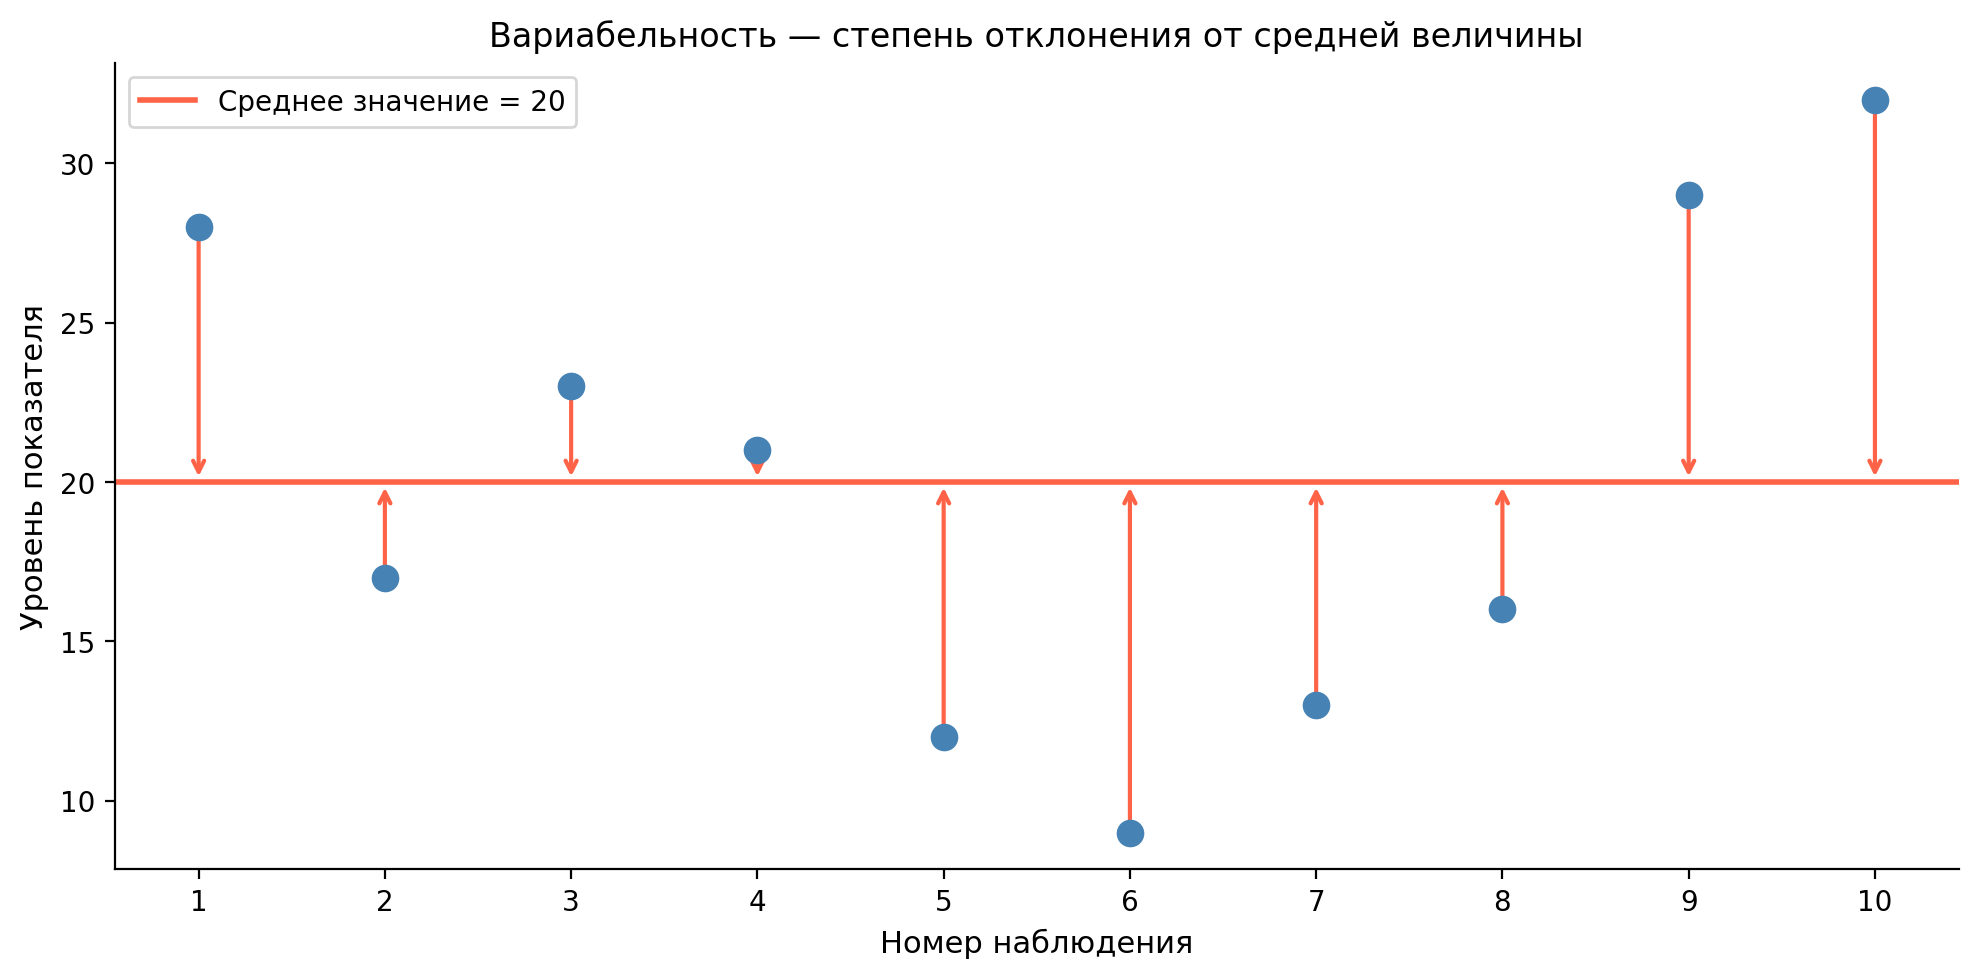

In [8]:
import numpy as np
import matplotlib.pyplot as plt

observations = np.array([28, 17, 23, 21, 12, 9, 13, 16, 29, 32])
x = np.arange(1, len(observations) + 1)
mean = observations.mean()

fig, ax = plt.subplots(figsize=(10, 5))

ax.axhline(mean, color='tomato', linewidth=2, label=f'Среднее значение = {mean:.0f}')

for xi, yi in zip(x, observations):
    ax.annotate('', xy=(xi, mean), xytext=(xi, yi),
                arrowprops=dict(arrowstyle='->', color='tomato', lw=1.5))

ax.scatter(x, observations, s=80, color='steelblue', zorder=5)

ax.set_xlabel('Номер наблюдения', fontsize=11)
ax.set_ylabel('Уровень показателя', fontsize=11)
ax.set_title('Вариабельность — степень отклонения от средней величины', fontsize=12)
ax.set_xticks(x)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Основные характеристики дискретных случайных величин

**Математическое ожидание** $M(x)$ — среднее значение случайной величины, равное сумме произведений значений на соответствующие вероятности:

$$M(x) = x_1 P_1 + x_2 P_2 + \cdots + x_n P_n = \sum_{i=1}^{n} x_i P_i$$

Здесь $x$ — это не одно конкретное число, а **случайная величина**: переменная, которая принимает разные значения в зависимости от исхода случайного события. До события её значение неизвестно. $x_1, x_2, \ldots, x_n$ — все возможные значения, которые $x$ может принять; $P_i$ — вероятность каждого из них.

**Пример:** бросаем кубик. $x$ — «какое число выпадет». До броска неизвестно, может быть 1, 2, 3, 4, 5 или 6. После броска $x$ принял конкретное значение, например 4.

| $x_i$ | 1 | 2 | 3 | 4 | 5 | 6 |
|---|---|---|---|---|---|---|
| $P_i$ | 1/6 | 1/6 | 1/6 | 1/6 | 1/6 | 1/6 |

$$M(x) = 1 \cdot \frac{1}{6} + 2 \cdot \frac{1}{6} + 3 \cdot \frac{1}{6} + 4 \cdot \frac{1}{6} + 5 \cdot \frac{1}{6} + 6 \cdot \frac{1}{6} = \frac{21}{6} = 3{,}5$$

Кубик никогда не покажет 3,5 — но в среднем по многим броскам результат стремится именно к этому значению.


**Дисперсия** $D(x)$ — мера разброса случайной величины; математическое ожидание квадрата отклонения каждого значения от математического ожидания:

$$D(x) = M\bigl[x - M(x)\bigr]^2 = \sum_{i=1}^{N} \bigl(x_i - M(x)\bigr)^2 P_i$$

Для кубика $M(x) = 3{,}5$:

$$D(x) = (1-3{,}5)^2\cdot\tfrac{1}{6} + (2-3{,}5)^2\cdot\tfrac{1}{6} + (3-3{,}5)^2\cdot\tfrac{1}{6} + (4-3{,}5)^2\cdot\tfrac{1}{6} + (5-3{,}5)^2\cdot\tfrac{1}{6} + (6-3{,}5)^2\cdot\tfrac{1}{6} \approx 2{,}92$$

---

**Среднеквадратическое отклонение** $\sigma(x)$ — корень из дисперсии, выражается в тех же единицах, что и $x$:

$$\sigma(x) = \sqrt{D(x)} = \sqrt{2{,}92} \approx 1{,}71$$

Это значит: типичное отклонение выпавшего числа от среднего (3,5) составляет около 1,7.

### Дисперсия выборки vs. дисперсия случайной величины

Это одна и та же идея — разброс вокруг среднего — но в разных контекстах:

**Дисперсия выборки** $\sigma^2$ — считается по реальным данным, которые уже есть. Например, взвесили 35 рыб, посчитали среднее, смотрим насколько каждая рыба от него отклоняется.

**Дисперсия случайной величины** $D(x)$ — теоретическая, считается через вероятности ещё до того, как что-то измерили. Например, для кубика — не бросая его, уже знаем среднее 3,5 и можем посчитать разброс.

Связь: при увеличении числа наблюдений выборочная дисперсия стремится к теоретической — так же как относительная частота $W(A) \to P(A)$.

### Равномерное распределение и формулы СКО

При **дискретном равномерном распределении** все значения равновероятны: $P(X = x_i) = 1/n$. Тогда математическое ожидание совпадает с обычным средним:

$$M(x) = \frac{1}{n}\sum_{i=1}^{n} x_i = \bar{x}$$

---

**СКО для генеральной совокупности** (делим на $n$):

$$\sigma = \sqrt{\frac{\sum(x_i - \bar{x})^2}{n}}$$

**СКО для выборки** (делим на $n-1$ — исправленная дисперсия, несмещённая оценка генеральной):

$$S = \sigma\sqrt{\frac{n}{n-1}} = \sqrt{\frac{\sum(x_i - \bar{x})^2}{n-1}}$$

Поправка $n-1$ вместо $n$ нужна потому, что выборочное среднее $\bar{x}$ уже вычислено по тем же данным — это съедает одну степень свободы и делает оценку дисперсии заниженной без поправки.
---

**Пример:** рост 5 студентов: 165, 170, 172, 175, 178 см.

$\bar{x} = (165+170+172+175+178)/5 = 172$ см

| $x_i$ | $x_i - \bar{x}$ | $(x_i - \bar{x})^2$ |
|---|---|---|
| 165 | -7 | 49 |
| 170 | -2 | 4 |
| 172 | 0 | 0 |
| 175 | 3 | 9 |
| 178 | 6 | 36 |
| | | **98** |

$$\sigma = \sqrt{\frac{98}{5}} \approx 4{,}43 \text{ см} \quad (\text{генеральная})$$

$$S = \sqrt{\frac{98}{4}} \approx 4{,}95 \text{ см} \quad (\text{выборочная})$$


#### Почему делим на n-1, а не на n?

Сумма всех отклонений от среднего **всегда равна нулю** — это математическое свойство среднего:

$$\sum_{i=1}^{n}(x_i - \bar{x}) = 0$$

Это значит: если ты знаешь среднее и n-1 отклонений, последнее отклонение уже определено автоматически — оно вынуждено быть таким, чтобы сумма вышла в ноль.

Пример: 5 студентов, 4 отклонения: $+2,\ -1,\ +3,\ -1$. Пятое **обязано** быть $-3$. Оно не несёт новой информации о разбросе.

Значит, из n отклонений реально информативных только **n-1**. Делим на n-1 — это и есть **степени свободы**.

> Деление на n-1 даёт несмещённую оценку дисперсии генеральной совокупности по выборке.

### Основные характеристики дискретных случайных величин

**Взвешенная дисперсия** для вариационного ряда (когда данные сгруппированы по частотам):

$$\sigma^2 = \frac{\sum(X - \bar{X})^2 \cdot f}{\sum f}$$

где $f$ — частота (количество наблюдений в группе), $\sum f = n$.

**Квадратический коэффициент вариации** — показывает, насколько велик разброс относительно среднего:

$$v = \frac{\sigma}{\bar{X}} \cdot 100\%$$

Если $v < 33\%$ — совокупность однородная, среднее надёжно характеризует данные.

#### Пример: рост студентов

Данные о росте 25 студентов сгруппированы по частотам:

| Рост X (см) | Частота f | X·f | (X − X̄) | (X − X̄)² | (X − X̄)²·f |
|------------|-----------|-----|---------|----------|------------|
| 160 | 5 | 800 | −12.8 | 163.84 | 819.2 |
| 170 | 10 | 1700 | −2.8 | 7.84 | 78.4 |
| 180 | 8 | 1440 | +7.2 | 51.84 | 414.72 |
| 190 | 2 | 380 | +17.2 | 295.84 | 591.68 |
| **Итого** | **25** | **4320** | | | **1904** |

**Среднее:**

$$\bar{X} = \frac{\sum X \cdot f}{\sum f} = \frac{4320}{25} = 172.8 \text{ см}$$

**Взвешенная дисперсия:**

$$\sigma^2 = \frac{\sum(X - \bar{X})^2 \cdot f}{\sum f} = \frac{1904}{25} = 76.16$$

**СКО:**

$$\sigma = \sqrt{76.16} \approx 8.73 \text{ см}$$

**Коэффициент вариации:**

$$v = \frac{8.73}{172.8} \cdot 100\% \approx 5.05\%$$

$v = 5.05\% < 33\%$ — совокупность **однородная**, среднее рост 172.8 см надёжно характеризует группу.

## Теоретические распределения

Знание распределений необходимо для статистических выводов из выборочных данных: оценивание, проверка гипотез, допустимые отклонения, вероятности ошибок и др.

```mermaid
graph TD
    A[Теоретические распределения] --> B[Дискретные]
    A --> C[Непрерывные]
    B --> B1[Биномиальное]
    B --> B2[Пуассона]
    C --> C1[Нормальное]
    C --> C2[Стьюдента]
    C --> C3[Логарифмически нормальное]
    C --> C4[Пирсона χ²]
    C --> C5[Фишера]
```

### Функция распределения случайной величины

**Интегральная функция распределения** F(x) равна вероятности того, что СВ X примет значение, меньшее чем x:

$$F(x) = P(X < x), \quad x \in \mathbb{R}$$

**Свойства:**

1. F(x) — неубывающая функция
2. $0 \leq F(x) \leq 1$ — т.к. это вероятность
3. $\lim_{x \to -\infty} F(x) = 0$ — левее всех значений вероятность равна нулю
4. $\lim_{x \to +\infty} F(x) = 1$ — правее всех значений вероятность равна единице
5. Вероятность попасть в интервал (a, b) — это приращение F на этом интервале:

$$P(a < X < b) = F(b) - F(a)$$

> F(x) — не конкретная формула, а универсальный инструмент: для любой СВ такая функция существует и всегда ведёт себя по этим пяти правилам. Конкретные формулы F(x) появятся для каждого распределения отдельно.

### Функция плотности распределения вероятностей непрерывной случайной величины (НСВ)

**Плотность вероятности** f(x) — это первая производная от функции распределения:

$$f(x) = F'(x)$$

Геометрически — это кривая, площадь под которой равна вероятности.

**Свойства:**

1. $f(x) \geq 0$ — т.к. F(x) неубывающая, производная неотрицательна
2. $\lim_{x \to \pm\infty} f(x) = 0$ — на краях плотность стремится к нулю
3. Площадь под всей кривой равна 1:

$$\int_{-\infty}^{+\infty} f(x)\,dx = 1$$

4. От плотности f(x) можно вернуться к F(x) интегрированием:

$$F(x) = \int_{-\infty}^{x} f(t)\,dt$$

5. Вероятность попасть в интервал (a, b):

$$P(a \leq X \leq b) = \int_{a}^{b} f(x)\,dx = F(b) - F(a)$$

### Схема Бернулли. Биномиальное распределение

**Схема Бернулли** — серия из n независимых испытаний, в каждом из которых возможны только два исхода:

- успех A с вероятностью P(A) = p
- неудача Ā с вероятностью P(Ā) = 1 − p = q

Вероятность успеха p постоянна и не зависит от номера испытания.

**Формула Бернулли** — вероятность того, что из n испытаний событие A произойдёт ровно k раз:

$$P_n(k) = C_n^k \, p^k q^{n-k} = \frac{n!}{k!\,(n-k)!} \, p^k q^{n-k}$$

где:

- $n$ — количество испытаний (сколько раз бросаем монету, сколько деталей проверяем)
- $k$ — количество успехов, которое нас интересует (сколько раз выпал орёл, сколько деталей оказались бракованными)
- $p$ — вероятность успеха в одном испытании
- $q = 1 - p$ — вероятность неудачи

**Почему «биномиальное»?**

Формула Бернулли — это в точности одно слагаемое из разложения бинома Ньютона:

$$(p + q)^n = \sum_{k=0}^{n} C_n^k \, p^k q^{n-k}$$

«Бином» — два члена: $p$ (успех) и $q$ (неудача). Поскольку $p + q = 1$, вся сумма вероятностей по всем k тоже равна 1.

[Видео: Binomial distribution — 3Blue1Brown](https://youtu.be/8idr1WZ1A7Q?si=O0HwVQ5TRjPVh0nU)

#### Пример: штрафные броски

Баскетболист забивает 70% штрафных бросков. Он делает 4 броска. Какова вероятность, что он забьёт ровно 3?

- $n = 4$ — количество бросков
- $k = 3$ — интересующее число попаданий
- $p = 0.7$ — вероятность попадания
- $q = 0.3$ — вероятность промаха

**Шаг 1.** Каждый бросок независим. Вероятность одной конкретной последовательности «попал, попал, попал, промах»:

$$0.7 \times 0.7 \times 0.7 \times 0.3 = 0.7^3 \cdot 0.3^1 = 0.1029$$

**Шаг 2.** Промах может случиться на любом из 4 бросков — это разные, но равновероятные последовательности:

| Бросок 1 | Бросок 2 | Бросок 3 | Бросок 4 |
|----------|----------|----------|----------|
| промах | попал | попал | попал |
| попал | промах | попал | попал |
| попал | попал | промах | попал |
| попал | попал | попал | промах |

Таких последовательностей $C_4^3 = 4$.

**Шаг 3.** Итоговая вероятность — умножаем число комбинаций на вероятность каждой:

$$P_4(3) = 4 \times 0.1029 \approx 0.412$$

Вероятность того, что из 4 бросков ровно 3 окажутся точными — около **41%**.

---

**А если он забьёт ровно 1 из 4?**

Теперь $k = 1$. Одна конкретная последовательность «попал, промах, промах, промах»:

$$0.7 \times 0.3 \times 0.3 \times 0.3 = 0.7^1 \cdot 0.3^3 = 0.0189$$

Таких последовательностей $C_4^1 = 4$ (попадание может быть на любом из 4 бросков).

$$P_4(1) = 4 \times 0.0189 \approx 0.076$$

Вероятность всего **~7.6%** — логично, ведь игрок хорошо бьёт штрафные.

**Ровно 2 из 4** ($k = 2$):

$$P_4(2) = C_4^2 \cdot 0.7^2 \cdot 0.3^2 = 6 \cdot 0.49 \cdot 0.09 \approx 0.265$$

**Все 4 из 4** ($k = 4$):

$$P_4(4) = C_4^4 \cdot 0.7^4 \cdot 0.3^0 = 1 \cdot 0.2401 \cdot 1 \approx 0.240$$

**Итого по всем исходам:**

| k | P |
|---|---|
| 0 | ~0.008 |
| 1 | ~0.076 |
| 2 | ~0.265 |
| 3 | ~0.412 |
| 4 | ~0.240 |
| **Сумма** | **~1.000** |

**Связь с биномом Ньютона:**

Раскроем $(p + q)^4$ при $p = 0.7$, $q = 0.3$:

$$(0.7 + 0.3)^4 = C_4^0 \cdot 0.7^0 \cdot 0.3^4 + C_4^1 \cdot 0.7^1 \cdot 0.3^3 + C_4^2 \cdot 0.7^2 \cdot 0.3^2 + \mathbf{C_4^3 \cdot 0.7^3 \cdot 0.3^1} + C_4^4 \cdot 0.7^4 \cdot 0.3^0$$

Нас интересует выделенное слагаемое при $k = 3$:

$$C_4^3 \cdot 0.7^3 \cdot 0.3^1 = 4 \cdot 0.343 \cdot 0.3 \approx 0.412$$

Сумма по всем k равна 1, потому что это все возможные исходы: 0, 1, 2, 3 или 4 попадания — других вариантов нет. Формально: $p + q = 1$, значит $(p + q)^n = 1^n = 1$.

### Распределение Пуассона. Редкие события

Применяется когда n велико, а вероятность p одного события очень мала (0.05–0.1 и меньше). Это упрощение биномиального распределения для редких событий.

$$P_\lambda(k) = \frac{\lambda^k}{k!} e^{-\lambda}, \quad k = 0, 1, 2, \ldots$$

где $\lambda = n \cdot p$ — параметр распределения, среднее число событий в серии испытаний.

Примеры редких событий: количество аварий в день, число опечаток на странице, число отказов оборудования в час.

[Видео: вывод распределения Пуассона](https://youtu.be/iJTuP4lsHQA?si=bIuNUSO_NmORgGAp)

#### Вывод распределения Пуассона из биномиального

Хотим посчитать предел биномиального распределения при $n \to \infty$ и $p \to 0$. Для этого представим формулу в виде множителей, для каждого из которых предел при $n \to \infty$ считается проще.

Напомним обозначения из биномиального распределения:

- $n$ — общее количество испытаний
- $k$ — количество успешных событий, которое нас интересует
- $p$ — вероятность успеха в одном испытании
- $1 - p$ — вероятность неудачи
- $C_n^k = \frac{n!}{k!(n-k)!}$ — число сочетаний: количество способов выбрать k успехов из n испытаний (порядок не важен)

**Шаг 1.** Биномиальная формула:

$$P_n(k) = \frac{n!}{k!(n-k)!} \cdot p^k \cdot (1-p)^{n-k}$$

Хотим рассмотреть случай: n очень большое, p очень маленькое, но среднее число событий $\lambda = n \cdot p$ фиксировано. Выражаем $p = \lambda / n$ и подставляем:

$$P_n(k) = \frac{n!}{k!(n-k)!} \cdot \left(\frac{\lambda}{n}\right)^k \cdot \left(1 - \frac{\lambda}{n}\right)^{n-k}$$

Представим $\left(\frac{\lambda}{n}\right)^k$ как $\frac{\lambda^k}{n^k}$:

$$P_n(k) = \frac{n!}{k!(n-k)!} \cdot \frac{\lambda^k}{n^k} \cdot \left(1 - \frac{\lambda}{n}\right)^{n-k}$$

<details>
<summary>Что значит «λ фиксировано»?</summary>

λ — это то, что известно из условия задачи или из наблюдений. Просто берёшь как данность.

Пуассон работает для редких событий — маленькое λ. Например: в книге в среднем 1 опечатка на 20 страниц, значит $\lambda = 1/20 = 0.05$ на страницу. Какова вероятность что на случайной странице не будет ни одной опечатки?

$$P(k=0) = \frac{0.05^0}{0!} \cdot e^{-0.05} = e^{-0.05} \approx 0.951$$

95% страниц — чистые. В реальной задаче ты просто берёшь λ из условия и подставляешь.

</details>

**Шаг 2.** Совместим первый множитель $\frac{n!}{k!(n-k)!}$ со вторым $\frac{\lambda^k}{n^k}$, а затем вынесем $\frac{\lambda^k}{k!}$ отдельно:

$$\frac{n!}{k!(n-k)!} \cdot \frac{\lambda^k}{n^k} = \frac{\lambda^k}{k!} \cdot \frac{n!}{(n-k)! \cdot n^k}$$

Подставляем обратно в формулу:

$$P_n(k) = \frac{\lambda^k}{k!} \cdot \frac{n!}{(n-k)! \cdot n^k} \cdot \left(1 - \frac{\lambda}{n}\right)^{n-k}$$

Теперь $\frac{\lambda^k}{k!}$ вынесен отдельно — он не зависит от n и при $n \to \infty$ остаётся как есть.

**Шаг 3.** Разобьём $\left(1 - \frac{\lambda}{n}\right)^{n-k}$ на два множителя, используя что $n - k = n + (-k)$:

$$\left(1 - \frac{\lambda}{n}\right)^{n-k} = \left(1 - \frac{\lambda}{n}\right)^n \cdot \left(1 - \frac{\lambda}{n}\right)^{-k}$$

Подставляем:

$$P_n(k) = \frac{\lambda^k}{k!} \cdot \frac{n!}{(n-k)! \cdot n^k} \cdot \left(1 - \frac{\lambda}{n}\right)^n \cdot \left(1 - \frac{\lambda}{n}\right)^{-k}$$

Теперь у нас четыре отдельных множителя, предел каждого при $n \to \infty$ будем считать по очереди.

**Шаг 4.** Считаем пределы тех множителей, которые сразу очевидны:

- $\frac{\lambda^k}{k!}$ — не зависит от n, остаётся как есть

- $\left(1 - \frac{\lambda}{n}\right)^n \to e^{-\lambda}$ при $n \to \infty$ — второй замечательный предел

- $\left(1 - \frac{\lambda}{n}\right)^{-k} \to 1$ при $n \to \infty$ — основание стремится к 1, степень фиксирована

Остался один нераскрытый множитель: $\frac{n!}{(n-k)! \cdot n^k}$ — с ним разберёмся на следующем шаге.

**Шаг 5.** Раскрываем $\frac{n!}{(n-k)! \cdot n^k}$.

По определению: $\frac{n!}{(n-k)!} = n \cdot (n-1) \cdot (n-2) \cdots (n-k+1)$ — это k множителей. Делим на $n^k$:

$$\frac{n!}{(n-k)! \cdot n^k} = \frac{n}{n} \cdot \frac{n-1}{n} \cdot \frac{n-2}{n} \cdots \frac{n-k+1}{n}$$

$$= 1 \cdot \left(1 - \frac{1}{n}\right) \cdot \left(1 - \frac{2}{n}\right) \cdots \left(1 - \frac{k-1}{n}\right)$$

При $n \to \infty$ каждое слагаемое вида $m/n \to 0$, поэтому каждая скобка $\to 1$, и всё произведение $\to 1$.

**Шаг 6.** Перемножаем пределы всех четырёх множителей:

$$\lim_{n \to \infty} P_n(k) = \frac{\lambda^k}{k!} \cdot 1 \cdot e^{-\lambda} \cdot 1 = \frac{\lambda^k}{k!} e^{-\lambda}$$

Это и есть формула Пуассона.

#### Пример: красные ковбойские сапоги

На каждую 1000 человек в среднем приходится 1 владелец красных ковбойских сапог. Найти вероятность того, что в городке с населением 8000 человек окажется ровно 7 таких людей.

Здесь $n = 8000$, $p = 0.001$ — очень маленькое, поэтому применяем Пуассона.

$\lambda = n \cdot p = 8000 \cdot 0.001 = 8$

Биномиальным распределением считать можно, но крайне неудобно:

$$P(8000,\ 7) = C_{8000}^{7} \cdot (0.001)^7 \cdot (0.999)^{7993} = \ldots$$

По формуле Пуассона:

$$P_7 = \frac{8^7 \cdot e^{-8}}{7!} = \frac{2\,097\,152 \cdot e^{-8}}{5040} \approx 0.14$$

Вероятность встретить ровно 7 ковбоев в городке — **14%**.

In [9]:
from scipy.stats import binom, poisson

n = 8000
p = 0.001
k = 7
lam = n * p  # lambda = 8

p_binom = binom.pmf(k, n, p)
p_poisson = poisson.pmf(k, lam)

print(f"Биномиальное распределение: {p_binom:.4f}")
print(f"Распределение Пуассона:     {p_poisson:.4f}")


Биномиальное распределение: 0.1396
Распределение Пуассона:     0.1396


#### Когда Пуассон не работает

Пуассон — это приближение для случая **большого n и маленького p**. Если p большое, приближение даёт большую ошибку.

Пример: баскетболист (p=0.7) делает 5 бросков, ищем вероятность ровно 4 попаданий.

Здесь p=0.7 — большое, Пуассон не предназначен для таких данных.

In [10]:
import math

def binom_pmf(k, n, p):
    return math.comb(n, k) * p**k * (1-p)**(n-k)

def poisson_pmf(k, lam):
    return lam**k * math.exp(-lam) / math.factorial(k)

n, p, k = 5, 0.7, 4
lam = n * p  # = 3.5

p_binom   = binom_pmf(k, n, p)
p_poisson = poisson_pmf(k, lam)

print(f"Биномиальное (точно): {p_binom:.4f}")
print(f"Пуассон (приближение): {p_poisson:.4f}")


Биномиальное (точно): 0.3601
Пуассон (приближение): 0.1888


#### Почему такое расхождение?

Формула Пуассона:

$$P_\lambda(k) = \frac{\lambda^k}{k!} e^{-\lambda}$$

Вспомним вывод: при переходе к Пуассону мы заменили $\left(1 - \frac{\lambda}{n}\right)^n$ на $e^{-\lambda}$. Это приближение работает только когда $n$ очень большое, то есть $\lambda/n \to 0$.

В нашем примере $n = 5$, $\lambda = 3.5$, поэтому $\lambda/n = 0.7$ — совсем не маленькое. Смотрим что происходит:

$$\left(1 - \frac{3.5}{5}\right)^5 = (0.3)^5 = 0.00243$$

$$e^{-3.5} = 0.03020$$

Эти два числа отличаются в **12 раз** — вот откуда берётся расхождение в итоговых вероятностях. Чем больше $n$ и меньше $p$, тем ближе $(1 - \lambda/n)^n$ к $e^{-\lambda}$, и тем точнее работает Пуассон.

### Нормальное приближение для биномиального распределения

#### Локальная теорема Муавра-Лапласа

Смысл тот же что у формулы Бернулли — найти вероятность ровно k успехов из n испытаний. Но Бернулли при большом n считать тяжело: C(n,k) вырастает в огромное число. Муавр и Лаплас заметили: при большом n биномиальное распределение по форме становится похоже на колокол Гаусса. Поэтому точную формулу Бернулли можно заменить значением функции Гаусса — она считается легко.

> Бернулли — точно, но тяжело при больших n. Муавр-Лаплас — приближённо, но быстро.

Если вероятность $p$ постоянна и отлична от 0 и 1, то при достаточно большом $n$ формула Бернулли:

$$P_n(k) = \frac{n!}{k!(n-k)!} \cdot p^k \cdot (1-p)^{n-k}$$

приближается к:

$$P_n(k) \approx \frac{1}{\sqrt{npq}} \cdot \varphi\left(\frac{k - np}{\sqrt{npq}}\right)$$

где $\varphi(x)$ — функция Гаусса:

$$\varphi(x) = \frac{1}{\sqrt{2\pi}} \cdot e^{-\frac{x^2}{2}}$$

Формула тем точнее, чем больше $n$. Погрешность незначительна уже при $npq \geq 20$.

<details>
<summary>Как применяется формула Стирлинга в доказательстве</summary>

**Формула Стирлинга** — приближение для факториала при больших n:

$$n! \approx \sqrt{2\pi n} \cdot \left(\frac{n}{e}\right)^n$$

В формуле Бернулли три факториала — заменяем каждый:

$$n! \approx \sqrt{2\pi n} \cdot \left(\frac{n}{e}\right)^n$$

$$k! \approx \sqrt{2\pi k} \cdot \left(\frac{k}{e}\right)^k$$

$$(n-k)! \approx \sqrt{2\pi(n-k)} \cdot \left(\frac{n-k}{e}\right)^{n-k}$$

Подставляем в $C_n^k = \frac{n!}{k!(n-k)!}$:

$$C_n^k \approx \frac{\sqrt{2\pi n} \cdot (n/e)^n}{\sqrt{2\pi k} \cdot (k/e)^k \cdot \sqrt{2\pi(n-k)} \cdot ((n-k)/e)^{n-k}}$$

Упрощаем по частям.

**Корни отдельно.** В числителе $\sqrt{2\pi n}$, в знаменателе $\sqrt{2\pi k} \cdot \sqrt{2\pi(n-k)}$:

$$\frac{\sqrt{2\pi n}}{\sqrt{2\pi k} \cdot \sqrt{2\pi(n-k)}} = \frac{\sqrt{2\pi n}}{\sqrt{4\pi^2 k(n-k)}} = \sqrt{\frac{n}{2\pi k(n-k)}}$$

**Степени с e отдельно.** Раскрываем $(n/e)^n = n^n/e^n$ и аналогично для k и (n-k):

$$\frac{n^n/e^n}{(k^k/e^k) \cdot ((n-k)^{n-k}/e^{n-k})} = \frac{n^n/e^n}{k^k(n-k)^{n-k}/e^{k+(n-k)}} = \frac{n^n/e^n}{k^k(n-k)^{n-k}/e^n}$$

$e^n$ сокращается:

$$= \frac{n^n}{k^k(n-k)^{n-k}}$$

**Собираем обе части:**

$$C_n^k \approx \sqrt{\frac{n}{2\pi k(n-k)}} \cdot \frac{n^n}{k^k(n-k)^{n-k}}$$

**Подставляем $k = np$ в корень.** $k = np$, $n - k = nq$:

$$\sqrt{\frac{n}{2\pi k(n-k)}} = \sqrt{\frac{n}{2\pi \cdot np \cdot nq}} = \sqrt{\frac{1}{2\pi npq}} = \frac{1}{\sqrt{npq}} \cdot \frac{1}{\sqrt{2\pi}}$$

**Подставляем $k = np$ в степенную часть.** Посмотрим что происходит с $\frac{n^n}{k^k(n-k)^{n-k}} \cdot p^k \cdot q^{n-k}$ при $k = np$:

$$\frac{n^n}{(np)^{np}(nq)^{nq}} \cdot p^{np} \cdot q^{nq} = \frac{n^n}{n^{np} \cdot p^{np} \cdot n^{nq} \cdot q^{nq}} \cdot p^{np} \cdot q^{nq}$$

$$= \frac{n^n}{n^{np+nq}} \cdot \frac{p^{np}}{p^{np}} \cdot \frac{q^{nq}}{q^{nq}} = \frac{n^n}{n^n} = 1$$

Степенная часть при $k = np$ равна 1 — всё сократилось.

**Для k вблизи np** (не точно в центре) пишем $k = np + \delta$, раскладываем логарифм степенной части в ряд Тейлора. После разложения появляется $e^{-x^2/2}$, где $x = \frac{k - np}{\sqrt{npq}}$ — отклонение k от среднего в единицах sqrt(npq).

**Итог:** собираем корень и степенную часть:

$$P_n(k) \approx \frac{1}{\sqrt{npq}} \cdot \underbrace{\frac{1}{\sqrt{2\pi}} e^{-x^2/2}}_{\varphi(x)}$$

</details>

#### Интегральная теорема Муавра-Лапласа

Локальная теорема даёт вероятность ровно k успехов. Интегральная — вероятность того, что k окажется в диапазоне от m1 до m2:

$$P_n(m_1 \leq k \leq m_2) = \sum_{i=m_1}^{m_2} C_n^i p^i q^{n-i} \approx \frac{1}{\sqrt{2\pi}} \int_{\alpha}^{\beta} e^{-\frac{x^2}{2}} dx$$

где:

$$\alpha = \frac{m_1 - np}{\sqrt{npq}}, \quad \beta = \frac{m_2 - np}{\sqrt{npq}}$$

α и β — это границы диапазона, пересчитанные в единицы стандартного отклонения от среднего.

Формула тем точнее, чем больше n. Погрешность незначительна при $npq \geq 20$.

**Почему такой пересчёт?** Функция Лапласа определена для стандартного нормального распределения — с нулевым средним и единичным стандартным отклонением. Формула $(m - np) / \sqrt{npq}$ переводит границы в ту же шкалу: вычитаем среднее и делим на стандартное отклонение. Результат — «сколько стандартных отклонений от среднего» — это и есть α и β.

#### Функция Лапласа

Чтобы не считать интеграл каждый раз, вводят функцию Лапласа — заранее посчитанный интеграл от 0 до x:

$$\Phi_0(x) = \frac{1}{\sqrt{2\pi}} \int_0^x e^{-\frac{t^2}{2}} dt$$

Её значения табулированы — берёшь таблицу и смотришь $\Phi_0(x)$ по нужному x.

**Свойства:**

- $\Phi_0(x) = -\Phi_0(-x)$ — нечётная функция (симметрична относительно нуля)
- монотонно возрастающая
- $\Phi_0(x) \to \pm 0.5$ при $x \to \pm\infty$
- $\Phi_0(x) \approx 0.5$ при $x > 4$ — практически вся площадь уже набрана

Через функцию Лапласа интегральная теорема записывается как:

$$P_n(m_1 \leq k \leq m_2) \approx \Phi_0(\beta) - \Phi_0(\alpha)$$

#### Пример: монета

Монету бросают 100 раз. Какова вероятность что орёл выпадет от 45 до 55 раз?

$n = 100$, $p = 0.5$, $q = 0.5$, $m_1 = 45$, $m_2 = 55$

Считаем α и β:

$$\alpha = \frac{45 - 100 \cdot 0.5}{\sqrt{100 \cdot 0.5 \cdot 0.5}} = \frac{-5}{5} = -1$$

$$\beta = \frac{55 - 100 \cdot 0.5}{\sqrt{100 \cdot 0.5 \cdot 0.5}} = \frac{5}{5} = +1$$

Используем нечётность $\Phi_0(-x) = -\Phi_0(x)$:

$$P \approx \Phi_0(1) - \Phi_0(-1) = \Phi_0(1) + \Phi_0(1) = 2 \cdot \Phi_0(1)$$

По таблице $\Phi_0(1) = 0.3413$:

$$P \approx 2 \cdot 0.3413 = 0.683$$

Вероятность ~68% — это ровно одно стандартное отклонение от среднего в обе стороны.

### Нормальное распределение

**Плотность вероятности** (функция Гаусса):

$$\varphi(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$$

**Функция распределения:**

$$F(x) = \frac{1}{\sigma\sqrt{2\pi}} \int_{-\infty}^{x} \exp\left(-\frac{(t-\mu)^2}{2\sigma^2}\right) dt$$

где $\mu$ — любое действительное число, $\sigma > 0$.

**Параметры распределения:**

- $M(X) = \mu$ — математическое ожидание
- $D(X) = \sigma^2$ — дисперсия

- μ отвечает за положение центра колокола на оси x
- σ отвечает за ширину: чем больше σ, тем шире и ниже колокол; чем меньше σ, тем уже и выше

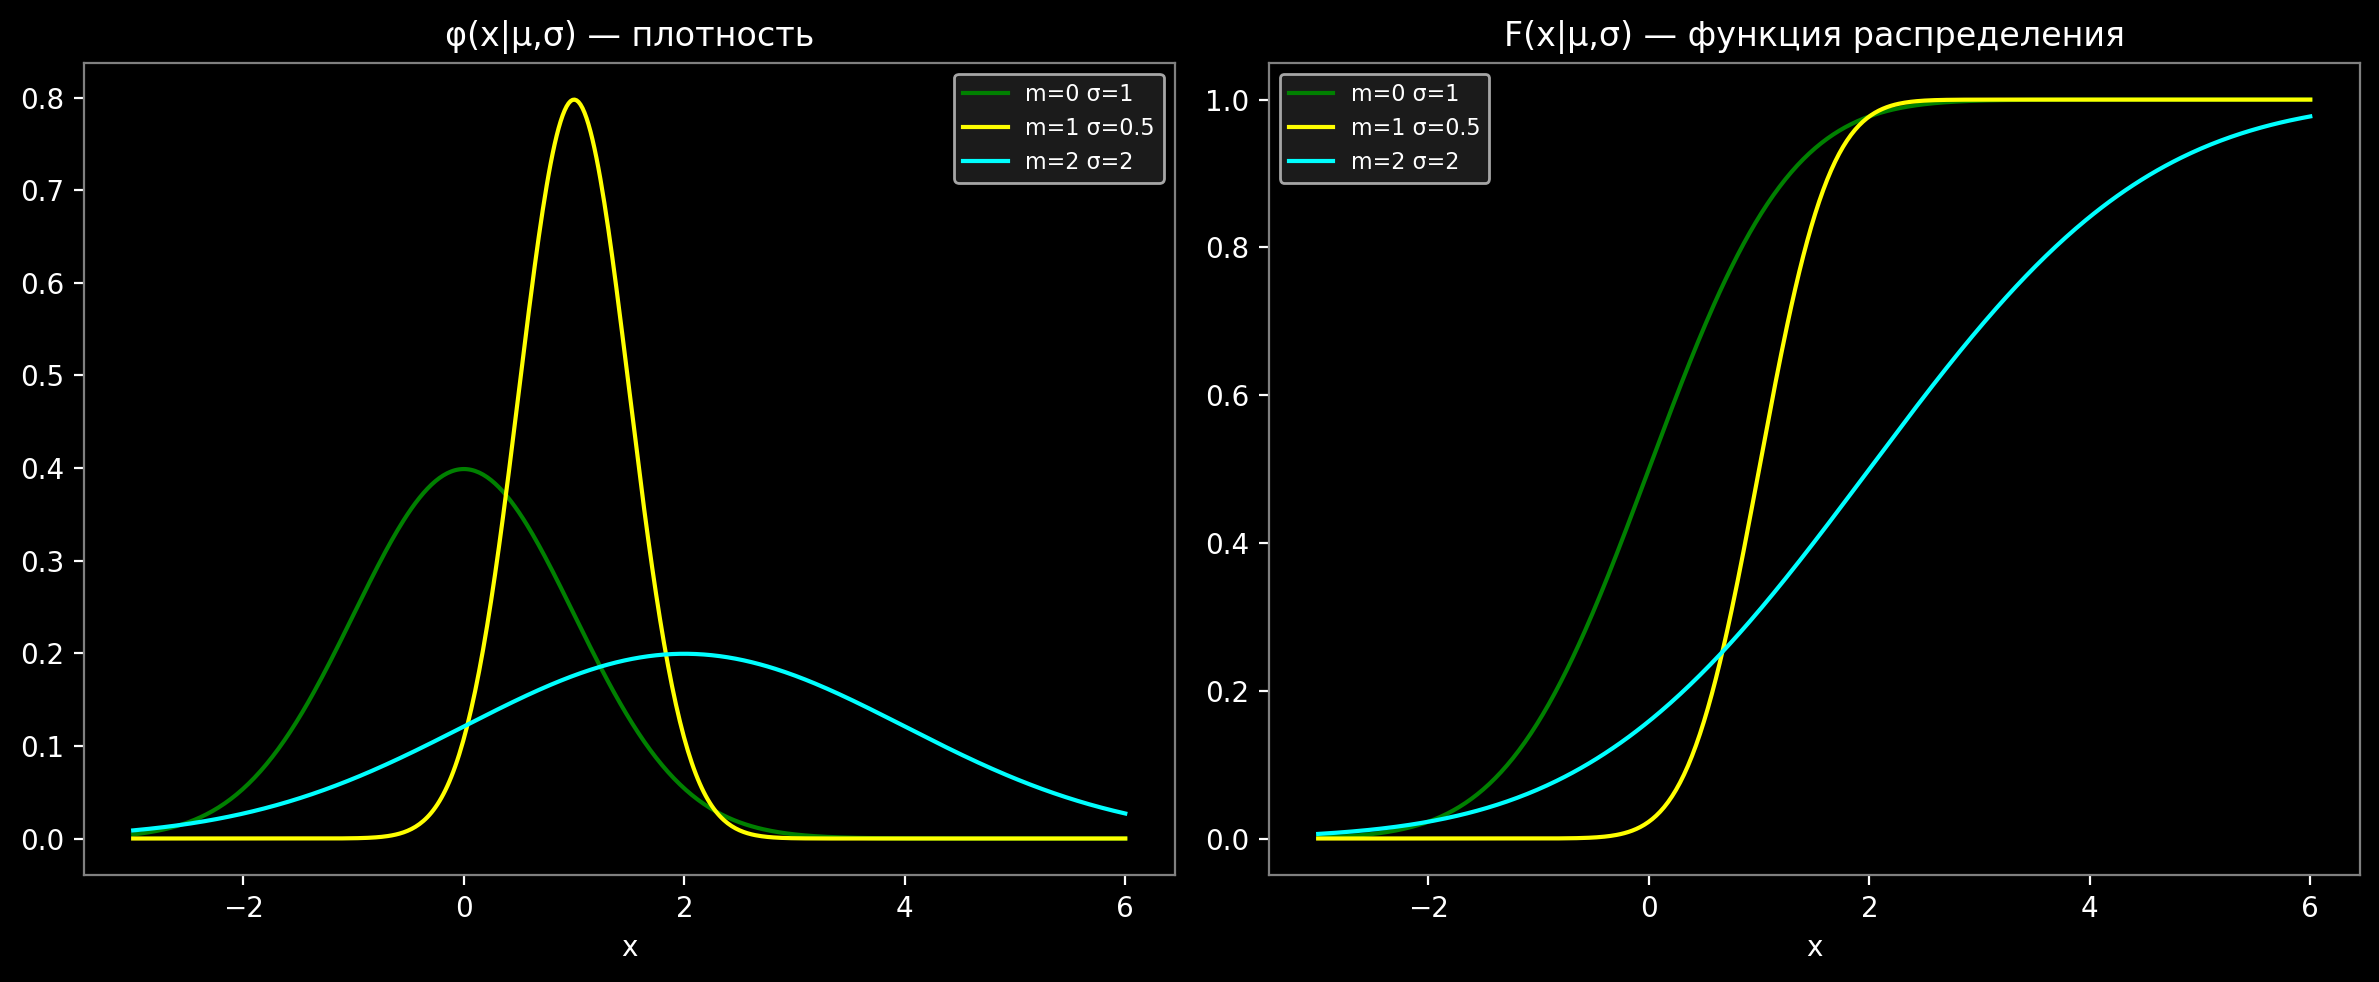

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(-3, 6, 500)

params = [
    (0, 1, 'green', 'm=0 σ=1'),
    (1, 0.5, 'yellow', 'm=1 σ=0.5'),
    (2, 2, 'cyan', 'm=2 σ=2'),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('black')
for ax in (ax1, ax2):
    ax.set_facecolor('black')
    ax.tick_params(colors='white')
    ax.spines[:].set_color('gray')

for mu, sigma, color, label in params:
    ax1.plot(x, norm.pdf(x, mu, sigma), color=color, label=label)
    ax2.plot(x, norm.cdf(x, mu, sigma), color=color, label=label)

ax1.set_title('φ(x|μ,σ) — плотность', color='white')
ax2.set_title('F(x|μ,σ) — функция распределения', color='white')
for ax in (ax1, ax2):
    ax.legend(facecolor='#222', labelcolor='white', fontsize=8)
    ax.set_xlabel('x', color='white')

plt.tight_layout()
plt.show()


#### Основные свойства нормального распределения

1. $\varphi(x) \geq 0$ — плотность вероятности не может быть отрицательной, так как вероятность не бывает меньше нуля

2. $\int_{-\infty}^{+\infty} \varphi(x)\,dx = 1$ — площадь под кривой равна 1

3. $\int_{\mu}^{\mu+x} \varphi(x)\,dx = \int_{\mu-x}^{\mu} \varphi(x)\,dx$ — симметрична относительно μ

4. Максимум в точке $x = \mu$: $\quad \varphi(\max) = \dfrac{1}{\sigma\sqrt{2\pi}}$

5. Точки перегиба при $x = \mu \pm \sigma$ (там вторая производная равна нулю)

6. $\varphi(\sigma) = \dfrac{1}{\sigma\sqrt{2\pi e}}$ — высота кривой в точке $x = \sigma$. Получается подстановкой $x = \sigma$ в формулу Гаусса: $\exp\left(-\frac{\sigma^2}{2\sigma^2}\right) = e^{-1/2} = \frac{1}{\sqrt{e}}$. Это граница точек перегиба — там кривая переходит из выпуклой в вогнутую. Чем больше σ — тем ниже эта точка, тем шире и плоше колокол

7. $\mu$ определяет положение центра кривой по оси x

8. $\sigma$ определяет степень «размытости» кривой

9. При $\mu = 0$, $\sigma = 1$ — **стандартное нормальное распределение**:

$$\varphi(x) = \frac{1}{\sqrt{2\pi}} \exp\left(-\frac{x^2}{2}\right)$$

#### Обозначение нормального распределения

Краткое обозначение: $N(\mu, \sigma^2)$

**Стандартное нормальное распределение** — частный случай при $\mu = 0$, $\sigma = 1$:

$$N(0, 1)$$

Именно для него построены таблицы функции Лапласа, и к нему приводят любое нормальное распределение через замену $x = (X - \mu) / \sigma$.

#### Связь функции распределения с функцией Лапласа

Интегральная функция стандартного нормального распределения:

$$F(x) = \Phi^*(x) = \frac{1}{\sqrt{2\pi}} \int_{-\infty}^{x} e^{-\frac{z^2}{2}} dz$$

Она связана с функцией Лапласа $\Phi_0(x)$ (которая считает площадь от 0 до x) простым соотношением:

$$\Phi^*(x) = 0.5 + \Phi_0(x)$$

Сдвиг на 0.5 появляется потому что $\Phi^*(x)$ считает площадь от $-\infty$, а $\Phi_0(x)$ — только от 0. Площадь левой половины колокола (от $-\infty$ до 0) как раз равна 0.5.

#### Нормальное распределение с произвольными μ и σ

Идея: переводим границы интервала в количество сигм от среднего — и дальше работаем с таблицей стандартного распределения.

Любую функцию распределения N(μ, σ²) можно выразить через стандартную, приведя аргумент к стандартному виду:

$$F(x) = \Phi^*\left(\frac{x - \mu}{\sigma}\right)$$

Вероятность попасть в интервал [α, β]:

$$P(\alpha \leq x \leq \beta) = \frac{1}{\sigma\sqrt{2\pi}} \int_{\alpha}^{\beta} e^{-\frac{(x-\mu)^2}{2\sigma^2}} dx = \Phi^*\!\left(\frac{\beta - \mu}{\sigma}\right) - \Phi^*\!\left(\frac{\alpha - \mu}{\sigma}\right)$$

#### Пример: рост студентов

Рост студентов распределён нормально: $\mu = 175$ см, $\sigma = 10$ см. Какова вероятность что рост случайного студента от 165 до 185 см?

Приводим границы к стандартному виду:

$$\frac{165 - 175}{10} = -1, \quad \frac{185 - 175}{10} = +1$$

$$P(165 \leq x \leq 185) = \Phi^*(+1) - \Phi^*(-1)$$

$$= (0.5 + 0.3413) - (0.5 - 0.3413) = 0.8413 - 0.1587 = 0.683$$

**68%** студентов окажутся в пределах одного σ от среднего — это знаменитое **правило одного сигма**.

#### Симметричный интервал вокруг μ

Частый случай на практике — интервал длиной 2l, симметричный относительно μ:

$$P(\mu - l \leq x \leq \mu + l) = \Phi^*\!\left(\frac{\mu + l - \mu}{\sigma}\right) - \Phi^*\!\left(\frac{\mu - l - \mu}{\sigma}\right) = \Phi^*\!\left(\frac{l}{\sigma}\right) - \Phi^*\!\left(\frac{-l}{\sigma}\right)$$

Используем свойство симметрии $\Phi^*(-x) = 1 - \Phi^*(x)$:

$$P(\mu - l \leq x \leq \mu + l) = 2\Phi^*\!\left(\frac{l}{\sigma}\right) - 1$$

Это удобная формула: нужно посчитать только одно значение Φ*, а не два.

### Правило трёх сигм

Для нормального распределения почти все значения сосредоточены вблизи среднего:

| Интервал | Вероятность |
|----------|-------------|
| $[\mu - \sigma;\ \mu + \sigma]$ | 68.26% |
| $[\mu - 2\sigma;\ \mu + 2\sigma]$ | 95.44% |
| $[\mu - 3\sigma;\ \mu + 3\sigma]$ | 99.72% |

Значения за пределами $\mu \pm 3\sigma$ встречаются лишь в 0.28% случаев — на практике считается что выход за три сигмы практически невозможен.

## Формы представления статистических данных

1. Текстовая
2. Табличная
3. Графическая

Ряды распределения показывают закономерность изменения изучаемого признака. Для наглядности вариационные ряды изображают графически в виде:

```mermaid
graph LR
    A[Графические формы] --> B[Гистограмма]
    A --> C[Полигон частот]
    A --> D[Кумулята]
    A --> E[Огива]
```

### Гистограмма

**Интервальный ряд** изображается столбиковой диаграммой, в которой:
- основания столбиков (ось X) — **интервалы значений** варьируемого признака
- высоты столбиков (ось Y) — **частоты**, соответствующие масштабу

Такая диаграмма называется **гистограммой**.

> Столбики в гистограмме стоят вплотную друг к другу — в отличие от обычной столбиковой диаграммы, где между ними есть зазор.

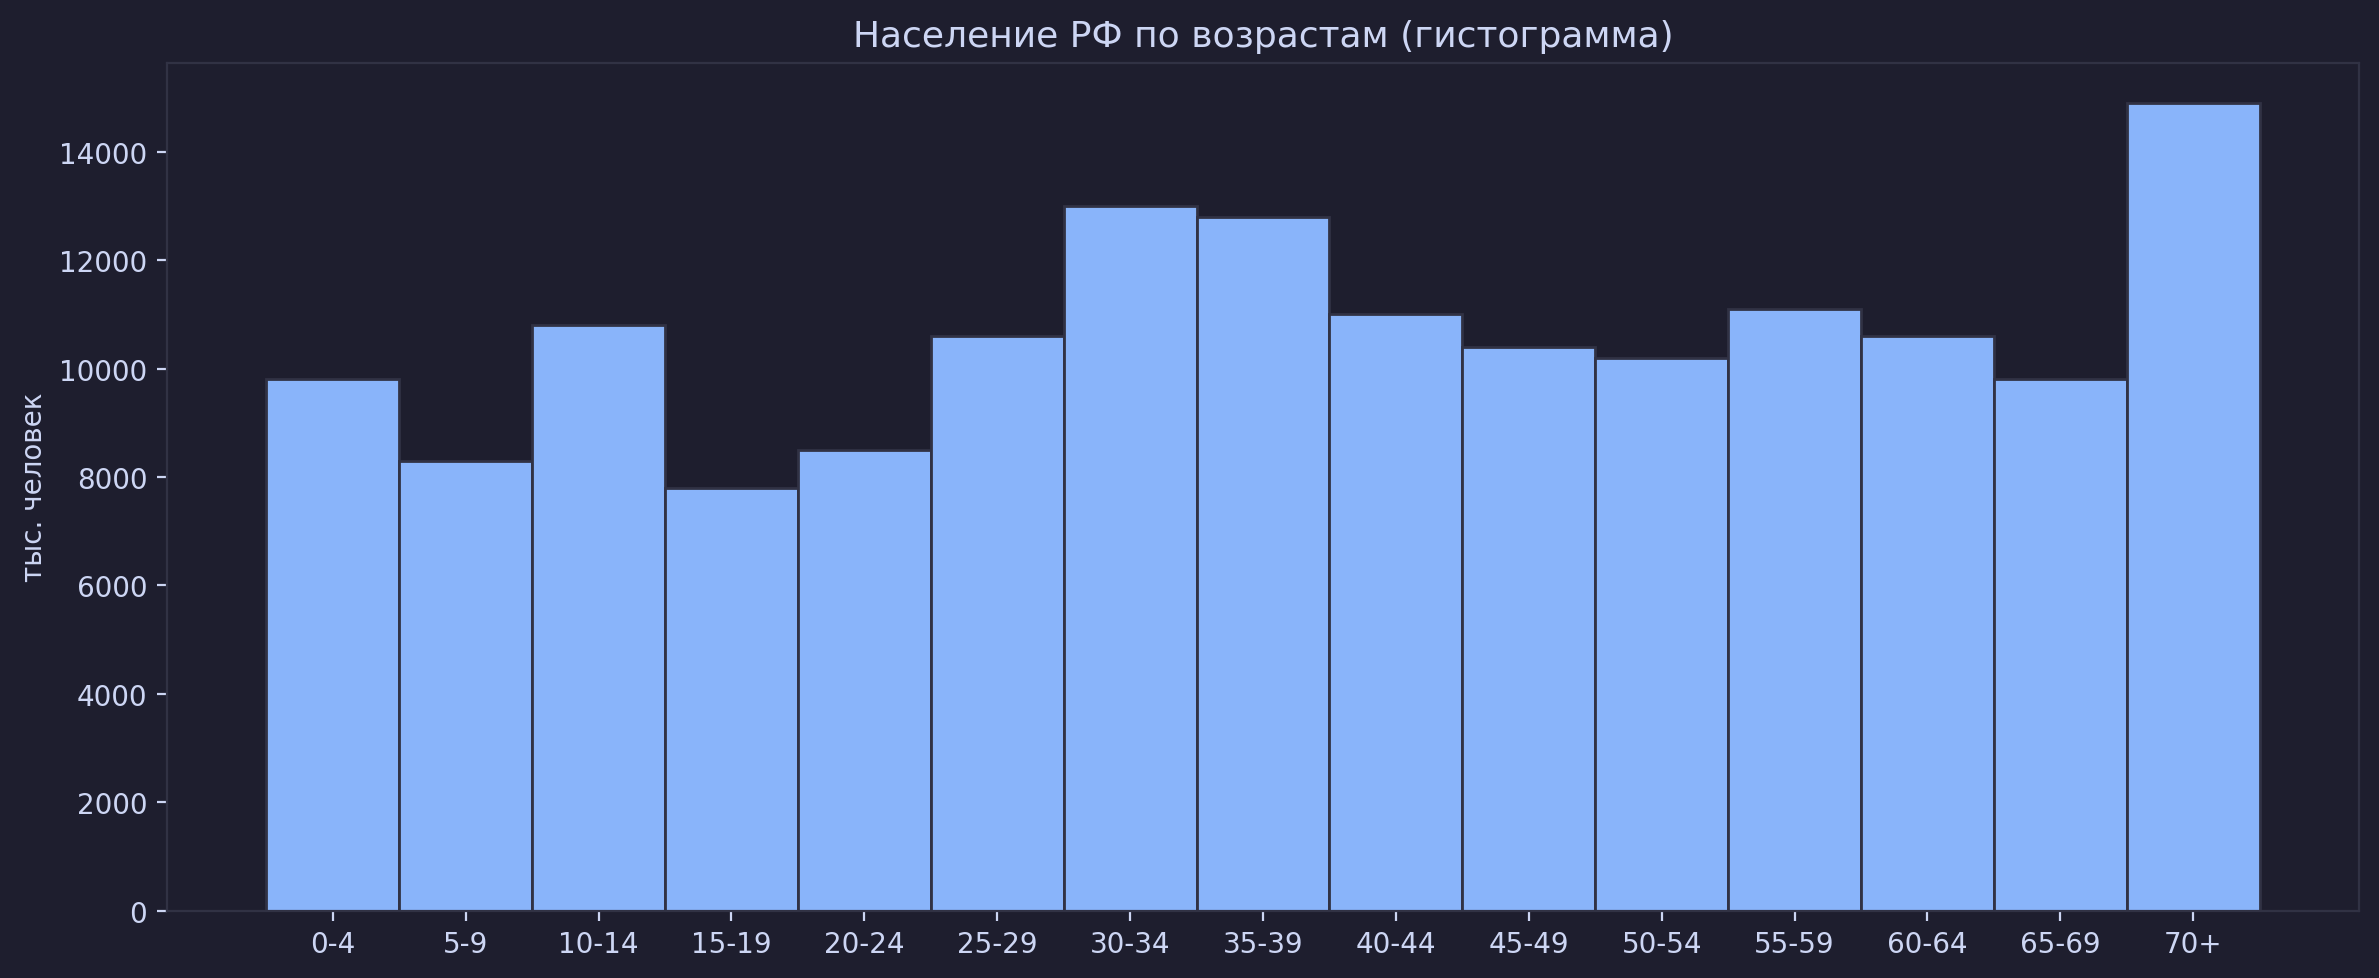

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Население РФ по возрастам (тыс. человек) — пример из лекции
age_groups = ['0-4','5-9','10-14','15-19','20-24','25-29','30-34',
               '35-39','40-44','45-49','50-54','55-59','60-64','65-69','70+']
population = [9800, 8300, 10800, 7800, 8500, 10600, 13000,
              12800, 11000, 10400, 10200, 11100, 10600, 9800, 14900]

fig, ax = plt.subplots(figsize=(12, 5), facecolor='#1e1e2e')
ax.set_facecolor('#1e1e2e')

bars = ax.bar(range(len(age_groups)), population, color='#89b4fa', edgecolor='#313244', width=1.0)

ax.set_xticks(range(len(age_groups)))
ax.set_xticklabels(age_groups, color='#cdd6f4', fontsize=10)
ax.set_ylabel('тыс. человек', color='#cdd6f4')
ax.set_title('Население РФ по возрастам (гистограмма)', color='#cdd6f4', fontsize=13)
ax.tick_params(colors='#cdd6f4')
for spine in ax.spines.values():
    spine.set_edgecolor('#313244')
ax.yaxis.label.set_color('#cdd6f4')

plt.tight_layout()
plt.show()

### Полигон

Если ряд распределения **дискретный** или используются **середины интервалов**, то графическое изображение называется **полигоном** — получается соединением прямыми точек с координатами X_i и f_i.

> Гистограмма и полигон частот могут быть совмещены на одном графике.

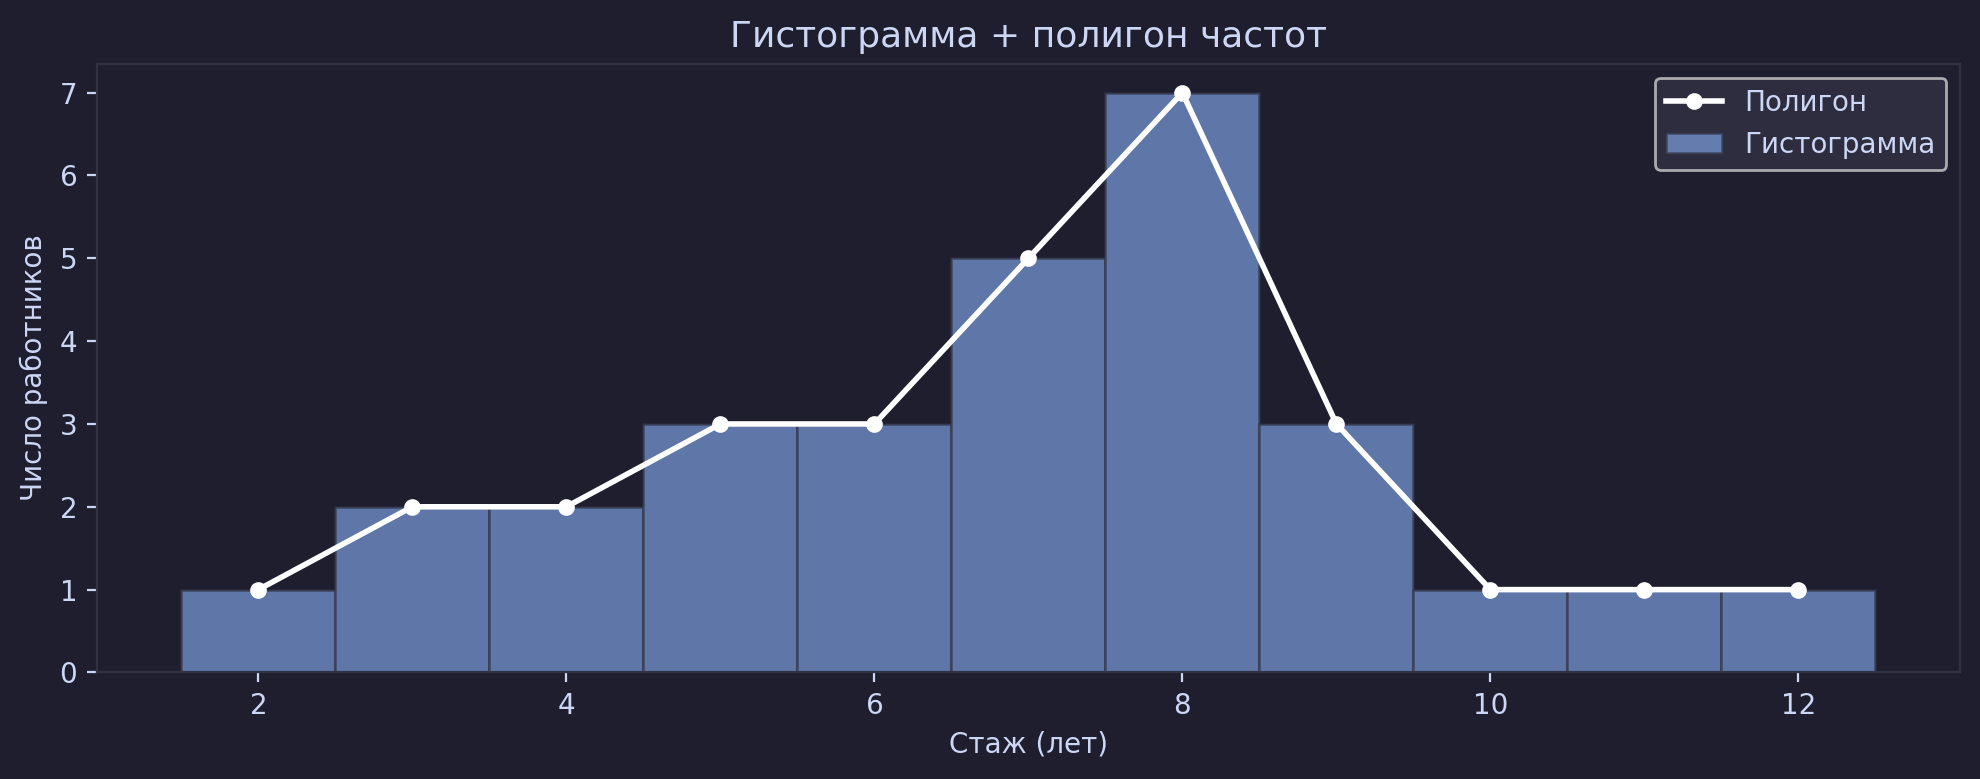

In [13]:
import matplotlib.pyplot as plt

# Число работников от стажа — пример из лекции
stazh = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
count = [1, 2, 2, 3, 3, 5, 7, 3,  1,  1,  1]

fig, ax = plt.subplots(figsize=(10, 4), facecolor='#1e1e2e')
ax.set_facecolor('#1e1e2e')

# гистограмма (столбики)
ax.bar(stazh, count, color='#89b4fa', edgecolor='#313244', width=1.0, alpha=0.6, label='Гистограмма')
# полигон (линия через середины вершин столбиков)
ax.plot(stazh, count, color='white', linewidth=2, marker='o', markersize=5, label='Полигон')

ax.set_xlabel('Стаж (лет)', color='#cdd6f4')
ax.set_ylabel('Число работников', color='#cdd6f4')
ax.set_title('Гистограмма + полигон частот', color='#cdd6f4', fontsize=13)
ax.tick_params(colors='#cdd6f4')
for spine in ax.spines.values():
    spine.set_edgecolor('#313244')
ax.legend(facecolor='#313244', labelcolor='#cdd6f4')

plt.tight_layout()
plt.show()

### Кумулята

Распределение признака в вариационном ряду по **накопленным частотам** (частостям) изображается с помощью **кумуляты**.

Кумулята (кумулятивная кривая) в отличие от полигона строится по накопленным частотам или частостям:
- ось X — значения признака
- ось Y — **накопленные** частоты (каждая точка = сумма всех предыдущих)

**Смысл:** в каждой точке кумулята показывает «сколько всего наблюдений в этой группе и во всех предыдущих».

Например, точка 25-29 даёт ответ на вопрос «сколько людей моложе 30 лет?» — не нужно складывать вручную.

> Кумулята — это дискретный аналог функции распределения F(x) = P(X < x), которую мы разбирали раньше. Она всегда монотонно возрастает.

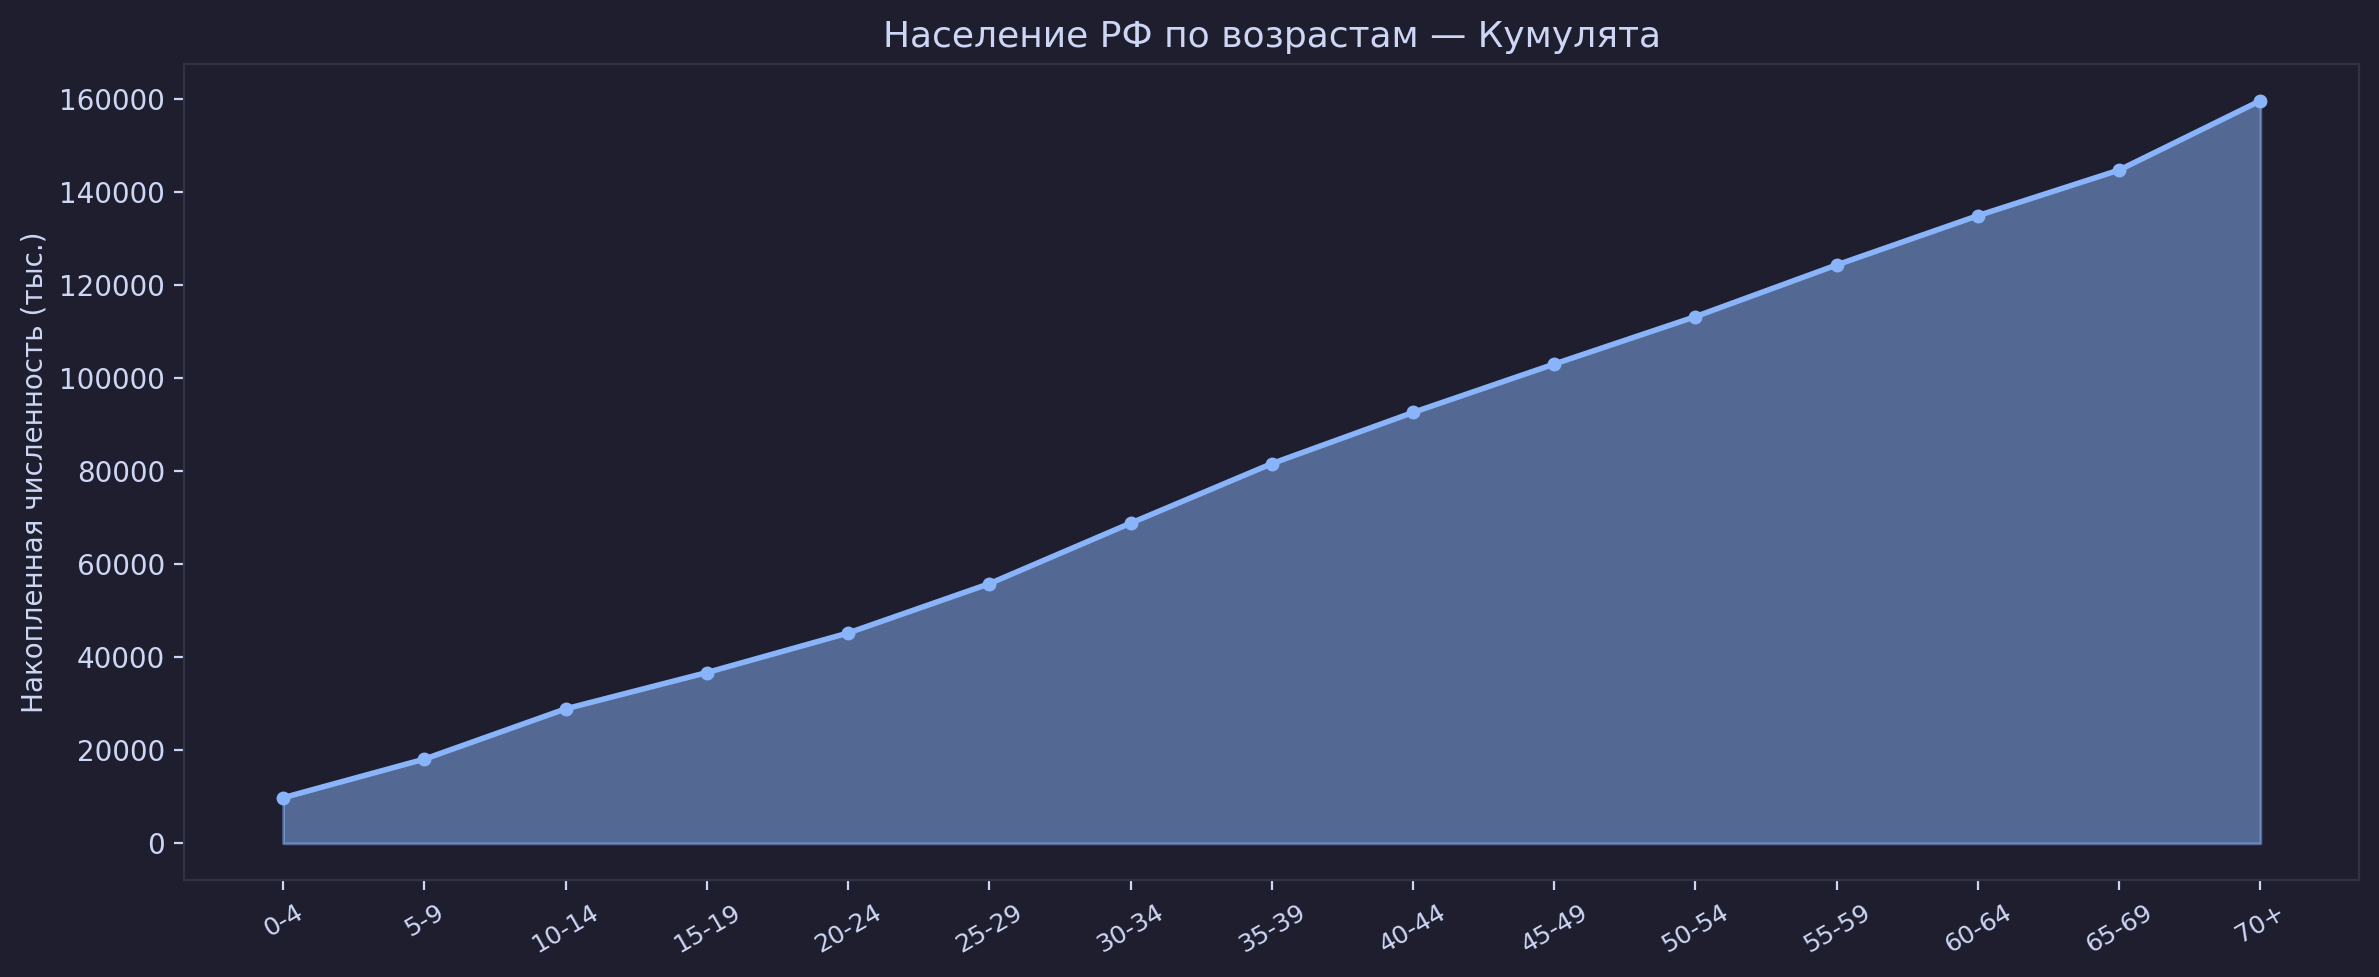

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Те же данные по населению РФ — теперь строим кумуляту
age_groups = ['0-4','5-9','10-14','15-19','20-24','25-29','30-34',
               '35-39','40-44','45-49','50-54','55-59','60-64','65-69','70+']
population = [9800, 8300, 10800, 7800, 8500, 10600, 13000,
              12800, 11000, 10400, 10200, 11100, 10600, 9800, 14900]

cumulative = np.cumsum(population)

fig, ax = plt.subplots(figsize=(12, 5), facecolor='#1e1e2e')
ax.set_facecolor('#1e1e2e')

ax.fill_between(range(len(age_groups)), cumulative, alpha=0.5, color='#89b4fa')
ax.plot(range(len(age_groups)), cumulative, color='#89b4fa', linewidth=2, marker='o', markersize=4)

ax.set_xticks(range(len(age_groups)))
ax.set_xticklabels(age_groups, color='#cdd6f4', fontsize=9, rotation=30)
ax.set_ylabel('Накопленная численность (тыс.)', color='#cdd6f4')
ax.set_title('Население РФ по возрастам — Кумулята', color='#cdd6f4', fontsize=13)
ax.tick_params(colors='#cdd6f4')
for spine in ax.spines.values():
    spine.set_edgecolor('#313244')

plt.tight_layout()
plt.show()

### Огива

Огива строится аналогично кумуляте, с той лишь разницей, что **оси меняются местами**:
- ось X — накопленные частоты
- ось Y — значения признака

> Огива = кумулята, повёрнутая на 90°.

> **Откуда название?** Огива — архитектурный термин для заострённой арки готического стиля. Кумулятивная кривая по форме напоминает такую арку — S-образная, плавно нарастающая. Термин одинаковый и в русской, и в западной (ogive) традиции.

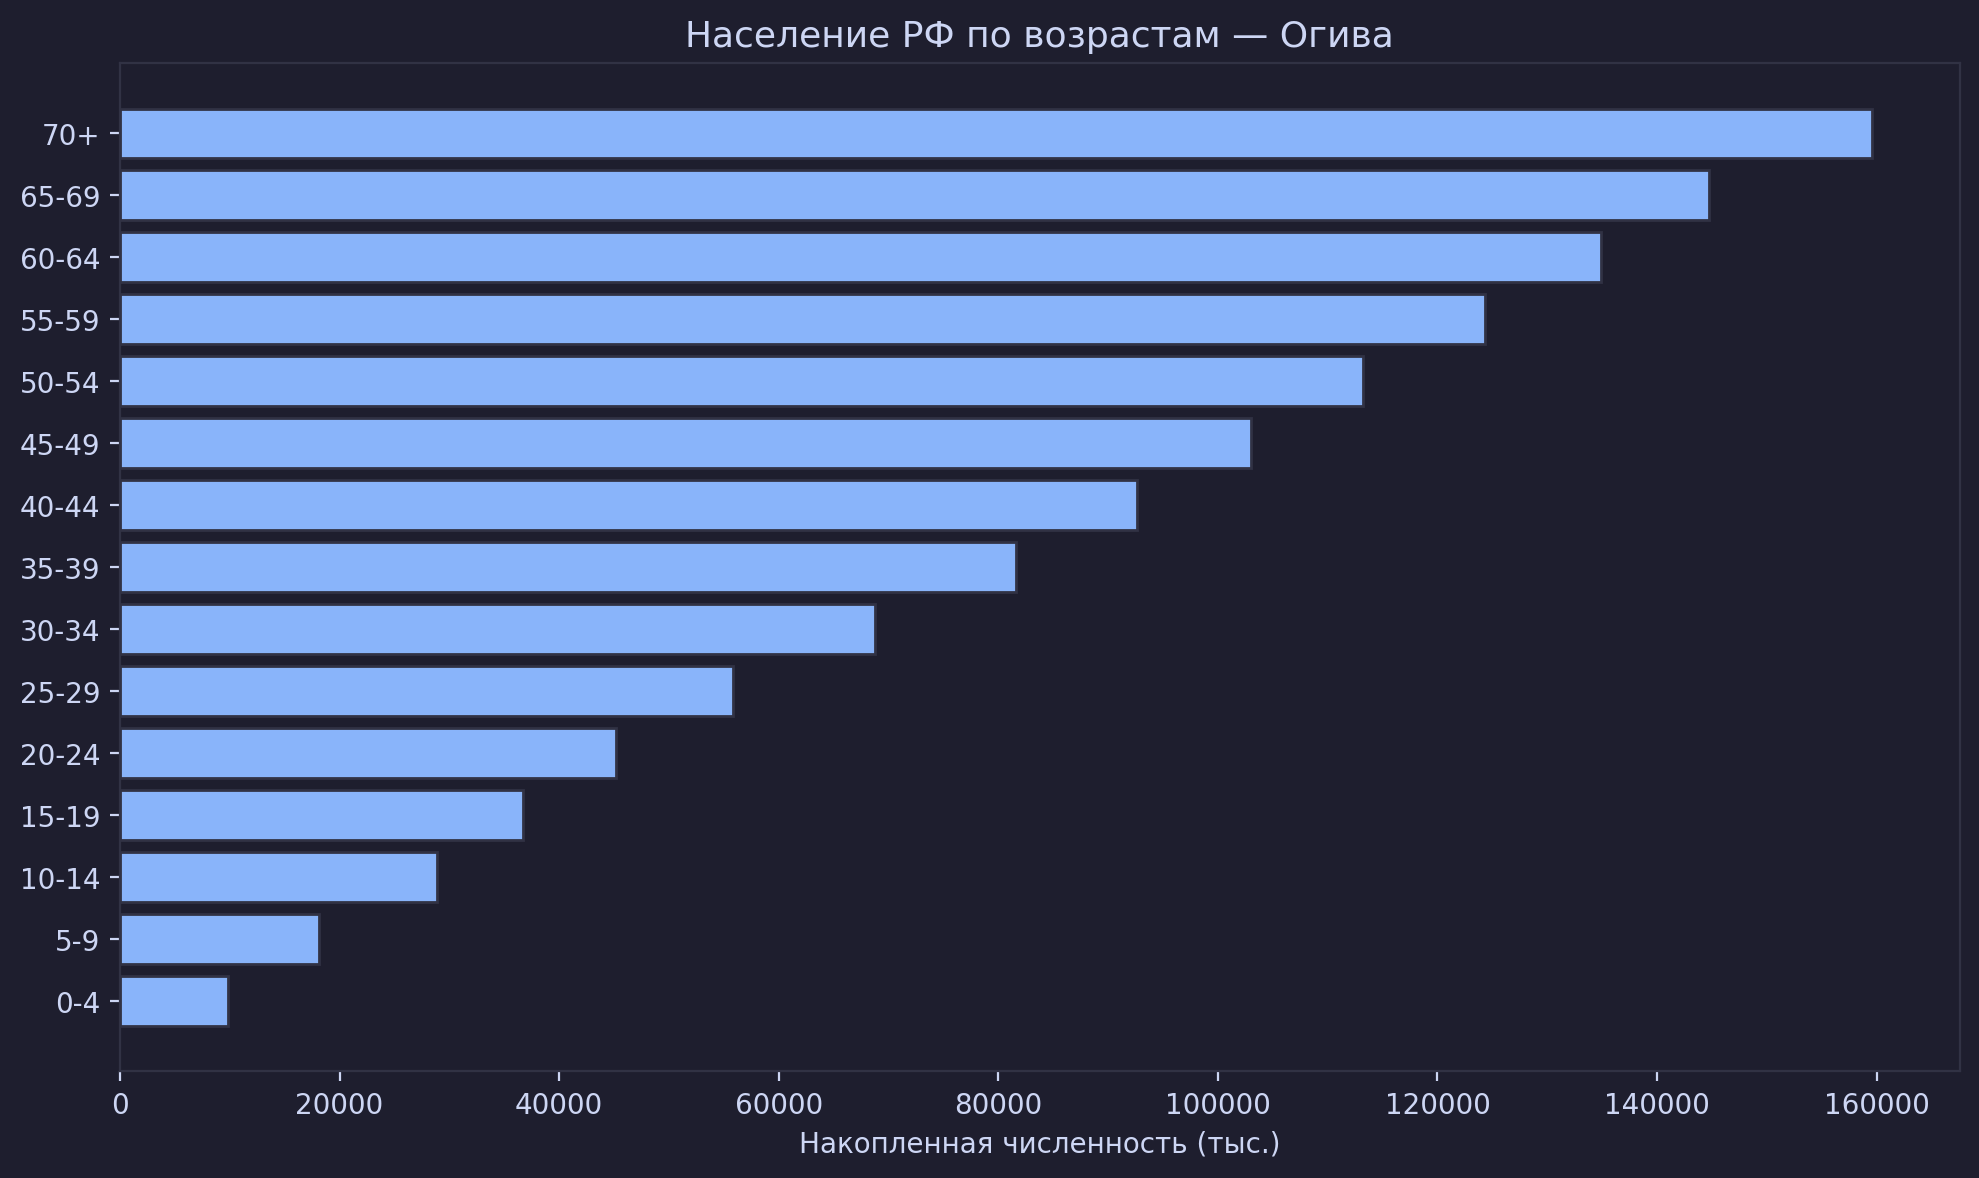

In [15]:
import matplotlib.pyplot as plt
import numpy as np

age_groups = ['0-4','5-9','10-14','15-19','20-24','25-29','30-34',
               '35-39','40-44','45-49','50-54','55-59','60-64','65-69','70+']
population = [9800, 8300, 10800, 7800, 8500, 10600, 13000,
              12800, 11000, 10400, 10200, 11100, 10600, 9800, 14900]

cumulative = np.cumsum(population)

fig, ax = plt.subplots(figsize=(10, 6), facecolor='#1e1e2e')
ax.set_facecolor('#1e1e2e')

# Огива: горизонтальные полосы (накопленные частоты на X, группы на Y)
ax.barh(age_groups, cumulative, color='#89b4fa', edgecolor='#313244')

ax.set_xlabel('Накопленная численность (тыс.)', color='#cdd6f4')
ax.set_title('Население РФ по возрастам — Огива', color='#cdd6f4', fontsize=13)
ax.tick_params(colors='#cdd6f4')
for spine in ax.spines.values():
    spine.set_edgecolor('#313244')

plt.tight_layout()
plt.show()

## Доверительный интервал (confidence interval)

**Доверительный интервал** — вычисленный на основе выборки интервал значений признака, который с известной вероятностью содержит оцениваемый параметр генеральной совокупности.

Является показателем точности измерений и показателем того, насколько стабильна полученная величина, то есть насколько близкую величину вы получите при повторении измерений.

> «Мы на 95% уверены, что доля людей, которым известна наша торговая марка, находится где-то между 23,2% и 38,0%».

«Параметр находится где-то здесь с 95% вероятностью»:

![Доверительный интервал 95%](images/confidence_interval.svg)


## Форма записи доверительного интервала

Один и тот же интервал можно записать тремя эквивалентными способами.

**Вариант 1.** Словами: «Мы на 95% уверены, что среднее значение роста студентов находится где-то между 165 и 175 см».

**Вариант 2.** Через параметр генеральной совокупности: среднее значение $\mu$ генеральной совокупности находится в интервале от 165 до 175 с доверительной вероятностью 0,95.

**Вариант 3.** Формулой:

$$P(165 < \mu < 175) = 0{,}95$$


## Доверительный интервал. Формула

**Цель:** найти интервал, в котором лежит истинное среднее $\mu$ всей совокупности, опираясь на известное нам среднее $\bar{x}$, вычисленное по выборке.

Среднее генеральной совокупности, имеющей **нормальный закон распределения**, с доверительной вероятностью $1-\alpha$ находится в доверительном интервале:

$$\bar{x} - z_{\alpha/2}\,\frac{\sigma}{\sqrt{n}} \;<\; \mu \;<\; \bar{x} + z_{\alpha/2}\,\frac{\sigma}{\sqrt{n}}$$

где $z_{\alpha/2}$ — **коэффициент доверия**.

Точность интервальной оценки находится по формуле:

$$E = z_{\alpha/2}\,\frac{\sigma}{\sqrt{n}}$$

Тогда интервал записывается как $\bar{x} - E < \mu < \bar{x} + E$:

![Доверительный интервал x̄ ± E](images/confidence_interval_xe.svg)


## Пример: средний вес рыб в озере

**Дано:**

| Обозначение | Значение | Что это | Откуда берётся |
|---|---|---|---|
| $N$ | 500 | всего рыб в озере (генеральная совокупность) | дано по условию |
| $n$ | 35 | поймали и взвесили (выборка) | дано по условию |
| $\bar{x}$ | 1200 г | средний вес рыб в выборке | **считаем по выборке** |
| $\sigma$ | 300 г | стандартное отклонение веса (разброс между рыбами) | **считаем по выборке** |
| $\alpha$ | 0,05 | надёжность $1-\alpha = 95\%$ $\Rightarrow z_{\alpha/2} = 1{,}96$ | **задаём сами** |

> ⚠️ **Главный акцент:** всё, кроме $\alpha$, берётся из данных — по выборке из 35 рыб мы считаем среднее $\bar{x}$ и отклонение $\sigma$. А вот **$\alpha$ (надёжность) мы задаём сами** — это наш выбор, насколько уверенным хотим быть. Здесь выбрали $\alpha = 0{,}05$, то есть надёжность 95%.

**Откуда берётся $\sigma/\sqrt{n}$.** Стандартную ошибку получают в два шага: сначала считают **дисперсию** среднего, потом из неё берут **стандартное отклонение** (корень). Опираются на два свойства дисперсии: у независимых величин дисперсии складываются, а при умножении на число дисперсия умножается на его квадрат, $D(aX)=a^2 D(X)$.

Дисперсия среднего (среднее — это сумма $n$ рыб, делённая на $n$):

$$D(\bar{x}) = D\!\left(\frac{X_1 + \dots + X_n}{n}\right) = \frac{1}{n^2}\,D(X_1 + \dots + X_n) = \frac{n\sigma^2}{n^2} = \frac{\sigma^2}{n}$$

Стандартная ошибка — корень из дисперсии (возврат от граммов² к граммам):

$$\sigma_{\bar{x}} = \sqrt{D(\bar{x})} = \sqrt{\frac{\sigma^2}{n}} = \frac{\sigma}{\sqrt{n}}$$

> **Важно: две разные дисперсии — два разных СКО.** Корень из дисперсии всегда даёт среднеквадратическое отклонение (СКО), но смотря из какой дисперсии:
>
> | Дисперсия | Корень из неё (СКО) | Что описывает |
> |---|---|---|
> | дисперсия **веса** $\sigma^2$ | $\sigma$ — **СКО веса** | разброс отдельных рыб ($\approx 300$ г) |
> | дисперсия **среднего** $\dfrac{\sigma^2}{n}$ | $\dfrac{\sigma}{\sqrt{n}}$ — **стандартная ошибка среднего** | разброс выборочных средних ($\approx 50{,}7$ г) |
>
> То есть «стандартная ошибка среднего» — это просто специальное название для **СКО среднего** (чтобы не путать его с СКО веса $\sigma$). Оба — корень из дисперсии, разница лишь в том, чью дисперсию мы извлекаем: отдельных рыб или их среднего.

**1. Стандартная ошибка среднего** $\dfrac{\sigma}{\sqrt{n}}$ — насколько «гуляет» само среднее от улова к улову:

$$\frac{\sigma}{\sqrt{n}} = \frac{300}{\sqrt{35}} = \frac{300}{5{,}92} \approx 50{,}7 \text{ г}$$

> **Что это значит:** $\dfrac{\sigma}{\sqrt{n}}$ — это возможная разница между средними в разных повторах вылова. Если снова и снова ловить по 35 рыб, средний вес улова каждый раз будет немного другим (1200 г, потом 1240 г, потом 1170 г…), и типичный размах этих колебаний вокруг истинного среднего — около $\pm 50{,}7$ г.

**2. Точность интервальной оценки** $E = z_{\alpha/2}\,\dfrac{\sigma}{\sqrt{n}}$:

$$E = 1{,}96 \cdot 50{,}7 \approx 99{,}4 \text{ г}$$

> Я задаю надёжность 95%, знаю среднее по выборке и стандартную ошибку — и вычисляю интервал, в котором с вероятностью 95% лежит истинное среднее всех рыб.
>
> Надёжность задаётся через $\alpha$: надёжность $= 1-\alpha$. Берём надёжность 95% $\Rightarrow \alpha = 1 - 0{,}95 = 0{,}05$ (5%), а $\alpha/2 = 0{,}025$ (2,5%) — столько риска в каждом хвосте.
>
> **Что такое $z$.** $z$ — это число, показывающее, на **сколько стандартных ошибок (сигм)** надо отступить от среднего в каждую сторону, чтобы внутри оказался заданный процент надёжности. Это безразмерный «шаг в сигмах», а не граммы. Для 95% надо отступить $z = 1{,}96$ сигмы; домножив на размер одной сигмы в граммах ($\sigma/\sqrt{n} \approx 50{,}7$ г), получаем отступ $E$ в граммах.
>
> Надёжность мы выбираем сами, и под неё берётся своё $z$:
>
> | Надёжность $1-\alpha$ | $\alpha$ | $z_{\alpha/2}$ |
> |---|---|---|
> | 90% | 0,10 | 1,645 |
> | 95% | 0,05 | 1,96 |
> | 99% | 0,01 | 2,576 |
>
> Выше надёжность → больше $z$ → интервал шире. Итог: задаём надёжность → находим $z$ → вычисляем интервал реальных значений (в граммах).
>
> $z$ берётся из **таблицы стандартного нормального распределения** (для 95% ищешь площадь 0,975 → $z = 1{,}96$): [z-table.com](https://www.z-table.com/), [Wikipedia](https://en.wikipedia.org/wiki/Standard_normal_table), [Math is Fun](https://www.mathsisfun.com/data/standard-normal-distribution-table.html). Либо в коде: `scipy.stats.norm.ppf(0.975)` → 1.96.

**3. Доверительный интервал** $\bar{x} - E < \mu < \bar{x} + E$:

$$1200 - 99{,}4 \;<\; \mu \;<\; 1200 + 99{,}4$$

$$\boxed{1100{,}6 \;<\; \mu \;<\; 1299{,}4 \text{ г}}$$

**Вывод:** с надёжностью 95% средний вес всех 500 рыб в озере лежит примерно между **1101 и 1299 г**.

---

**Поправка на конечную совокупность.** Здесь выборка составляет $n/N = 35/500 = 7\%$ от озера (больше 5%), поэтому ошибку можно слегка уменьшить множителем

$$\sqrt{\frac{N-n}{N-1}} = \sqrt{\frac{500-35}{499}} \approx 0{,}965,$$

тогда $E \approx 1{,}96 \cdot 50{,}7 \cdot 0{,}965 \approx 95{,}9$ г, и интервал чуть уже: $1104 < \mu < 1296$ г.


### Тот же пример при другой надёжности (99%)

Данные те же: $N = 500$, $n = 35$, $\bar{x} = 1200$ г, $\sigma = 300$ г. Меняем только надёжность.

- В первом примере задавали надёжность **95%** $\Rightarrow \alpha = 0{,}05$ (5%) $\Rightarrow z = 1{,}96$.
- Теперь задаём надёжность **99%** $\Rightarrow \alpha = 0{,}01$ (1%) $\Rightarrow \alpha/2 = 0{,}005 \Rightarrow z = 2{,}576$.

Стандартная ошибка та же ($\sigma/\sqrt{n} \approx 50{,}7$ г — от $\alpha$ не зависит), меняется только множитель $z$:

$$E = 2{,}576 \cdot 50{,}7 \approx 130{,}6 \text{ г}$$

$$\boxed{1069 \;<\; \mu \;<\; 1331 \text{ г}}$$

**Сравнение** (один и тот же улов, разная заданная надёжность):

| Надёжность $1-\alpha$ | $\alpha$ | $z$ | $E$ | Интервал |
|---|---|---|---|---|
| 90% | 0,10 | 1,645 | 83 г | 1117 … 1283 |
| 95% | 0,05 | 1,96 | 99 г | 1101 … 1299 |
| 99% | 0,01 | 2,576 | 131 г | 1069 … 1331 |

**Вывод:** чем выше заданная надёжность, тем больше $z$ и тем **шире** интервал. За уверенность платим точностью.


## Часто используемые z-значения

Готовая шпаргалка для самых ходовых надёжностей:

| $z$ | Площадь $\Phi(z)$ (слева от $z$) | Доверительная вероятность |
|---|---|---|
| 1,645 | 0,9500 | 0,90 (90%) |
| 1,96 | 0,9750 | 0,95 (95%) |
| 2,575 | 0,9950 | 0,99 (99%) |

Доверительные интервалы для среднего при этих надёжностях:

$$P\left(\bar{x} - 1{,}645\cdot\frac{\sigma}{\sqrt{n}} \;<\; \mu \;<\; \bar{x} + 1{,}645\cdot\frac{\sigma}{\sqrt{n}}\right) = 0{,}90$$

$$P\left(\bar{x} - 1{,}96\cdot\frac{\sigma}{\sqrt{n}} \;<\; \mu \;<\; \bar{x} + 1{,}96\cdot\frac{\sigma}{\sqrt{n}}\right) = 0{,}95$$

$$P\left(\bar{x} - 2{,}575\cdot\frac{\sigma}{\sqrt{n}} \;<\; \mu \;<\; \bar{x} + 2{,}575\cdot\frac{\sigma}{\sqrt{n}}\right) = 0{,}99$$

**Связь доверительной вероятности с таблицей.** Пусть $\Phi(z)$ — площадь слева от $z$ (таблица А-2), а $\alpha/2 = 1 - \Phi(z)$ — правый хвост. Тогда доверительная вероятность:

$$P = \Phi(z) - \frac{\alpha}{2}, \qquad \Phi(z) + \frac{\alpha}{2} = 1 \;\Longrightarrow\; P = 2\,\Phi(z) - 1$$

Проверка для 95%: $P = 2\cdot 0{,}975 - 1 = 0{,}95$. Это та же мысль, что и «$0{,}475 \times 2 = 0{,}95$», только через площадь слева: $2\Phi(z)-1 = 2(0{,}5 + 0{,}475) - 1 = 0{,}95$.


## Пример: средний возраст студентов

Ректор университета хочет узнать, каков **средний возраст студентов**, обучающихся в настоящее время.

Из предыдущих исследований известно, что **стандартное отклонение равно 2 годам**. Сделана выборка из **50 студентов** и вычислено среднее — оно оказалось равно **20,3 года**.

**Задача:** найти 95%-й доверительный интервал для генерального среднего.

**Дано:**

| Обозначение | Значение | Что это |
|---|---|---|
| $\sigma$ | 2 года | стандартное отклонение (известно заранее) |
| $n$ | 50 | объём выборки |
| $\bar{x}$ | 20,3 года | среднее по выборке |
| $\alpha$ | 0,05 | надёжность $1-\alpha = 95\%$ $\Rightarrow z = 1{,}96$ |


## Решение

**Шаг 1.** По выборке вычислено выборочное среднее $\bar{x} = 20{,}3$.

**Шаг 2.** Доверительная вероятность 95% соответствует $z = 1{,}96$.
(в Excel: `=НОРМ.СТ.ОБР((1+0,95)/2)`; в Python: `scipy.stats.norm.ppf((1+0.95)/2)`)

**Шаг 3.** Точность интервальной оценки:

$$E = z_{\alpha/2}\,\frac{\sigma}{\sqrt{n}} = 1{,}96\cdot\frac{2}{\sqrt{50}} = 0{,}55$$

**Шаг 4.** Подставляем в формулу доверительного интервала:

$$20{,}3 - 0{,}55 \;<\; \mu \;<\; 20{,}3 + 0{,}55$$

**Шаг 5.** Ответ:

$$\boxed{19{,}75 \;<\; \mu \;<\; 20{,}85}$$

Средний возраст всех студентов с надёжностью 95% лежит между 19,75 и 20,85 года.

![Нормальное распределение, 95% между −1,96 и 1,96](images/normal_95_bell.svg)


## Объём выборки для оценки среднего

Формула для нахождения точности оценки:

$$E = z_{\alpha/2}\,\frac{\sigma}{\sqrt{n}}$$

Выражаем из неё объём выборки $n$:

$$n = \left(\frac{z_{\alpha/2}\,\sigma}{E}\right)^{2}$$

Если известны $E$, $\sigma$ и доверительная вероятность, то по этой формуле подсчитывается **минимальный объём выборки**, который необходим для построения интервальной оценки.

> **Смысл:** обратная задача. Раньше мы по готовой выборке ($n$) находили точность $E$. Здесь наоборот — **задаём нужную точность $E$** (например, «хочу оценить средний возраст с погрешностью не больше ±0,3 года») и считаем, **сколько объектов** надо взять в выборку, чтобы её достичь.
>
> Из формулы видно: чтобы повысить точность вдвое (уменьшить $E$ в 2 раза), выборку нужно увеличить **в 4 раза** ($E$ под квадратом) — то же правило $\sqrt{n}$, что и раньше.

**Что нужно для расчёта** $n$ (само среднее $\bar{x}$ не нужно — выборку мы ещё не собрали):

| Что нужно | Откуда берётся |
|---|---|
| $\alpha$ (надёжность) $\to z$ | задаём сами (95% → $z = 1{,}96$) |
| $E$ — желаемая точность (погрешность) | задаём сами («хочу ±0,3 года») |
| $\sigma$ — стандартное отклонение | должно быть известно заранее |

**Пример.** Ректор хочет оценить средний возраст студентов с точностью **±0,3 года** и надёжностью **95%**. Из прошлых исследований $\sigma = 2$ года. Сколько студентов опросить?

$$n = \left(\frac{z\,\sigma}{E}\right)^2 = \left(\frac{1{,}96 \cdot 2}{0{,}3}\right)^2 = \left(\frac{3{,}92}{0{,}3}\right)^2 \approx 170{,}7 \;\Rightarrow\; n = 171$$

**Округляем всегда ВВЕРХ:** 170 не хватит для нужной точности, а «170,7 студента» не бывает — берём ближайшее большее целое.

### Откуда берётся $\sigma$ для расчёта $n$

По смыслу $\sigma$ в формуле — это отклонение **генеральной совокупности**. Но точно его мы не знаем (всю совокупность не измеряли), поэтому подставляем **оценку**, взятую заранее:

1. **Прошлые исследования** — берём $\sigma$ оттуда, считая, что разброс с тех пор не сильно изменился.
2. **Пилотная выборка** — собираем небольшую предварительную выборку (20–30 объектов), считаем по ней $s$ и используем как приближение.
3. **Грубая прикидка** — иногда $\sigma \approx$ размах/4 или размах/6 (по правилу трёх сигм).

**Почему так можно:** разброс $\sigma$ — гораздо более **устойчивая** величина, чем среднее. Средний возраст меняется год от года, а вариативность («насколько студенты различаются по возрасту») держится почти неизменной. Поэтому **среднее** оцениваем заново (ради этого и собираем выборку), а **$\sigma$** можно взять из прошлого. К тому же расчёт $n$ — это планирование: небольшая ошибка в $\sigma$ даёт лишь небольшую ошибку в $n$, не критично.


## Пример: какого размера нужна выборка

Декан просит преподавателя по статистике оценить **средний возраст студентов факультета**.

**Вопрос:** какого размера выборка необходима?

Преподаватель считает, что оценка должна быть сделана с точностью **до 1 года** и с вероятностью **99%**. Из ранее проведённого исследования известно, что стандартное отклонение возраста — **2 года**.

**Дано:**

| Обозначение | Значение | Что это |
|---|---|---|
| $E$ | 1 год | требуемая точность (погрешность) |
| $\alpha$ | 0,01 | надёжность $1-\alpha = 99\%$ $\Rightarrow z = 2{,}58$ |
| $\sigma$ | 2 года | стандартное отклонение (из прошлого исследования) |

**Найти:** минимальный объём выборки $n$.


## Решение

Для $\alpha = 1 - 0{,}99 = 0{,}01$ z-значение равно **2,58**. По условию $E = 1$, $\sigma = 2$.

$$n = \left(\frac{z_{\alpha/2}\,\sigma}{E}\right)^2 = \left(\frac{2{,}58 \times 2}{1}\right)^2 = 26{,}63 \approx 27$$

(округляем вверх: 26 не хватит, выборку «26,63 человека» не бывает.)

**Ответ:** чтобы быть на 99% уверенным, что полученная оценка отличается от точного среднего возраста не больше чем на 1 год, преподавателю нужна выборка **как минимум в 27 человек**.


## Описание проблемы: σ неизвестно и n ≤ 30

**Цель.** Оценить среднее для генеральной совокупности, имеющей нормальный закон распределения с параметрами $\mu$, $\sigma$.

**Что мы имеем.** Случайную выборку объёма $n$ из генеральной совокупности. При этом стандартное отклонение $\sigma$ **неизвестно**, а объём выборки **$n \le 30$** (малая выборка).

**Требуется.** Построить доверительный интервал для среднего:

$$\bar{x} - E \;<\; \mu \;<\; \bar{x} + E$$

> Это ровно тот случай, что мы обсуждали на примере с рыбами: $\sigma$ генеральной совокупности неизвестна. Раньше (когда $\sigma$ известна или выборка большая) брали $z$. Теперь $\sigma$ заменяем выборочным $s$, а вместо $z$ используют **t-распределение Стьюдента** — оно шире нормального и даёт чуть больший запас, компенсируя то, что $\sigma$ мы оценили, а не знаем точно. Особенно это важно при малых $n \le 30$.


## Отличие метода

При построении доверительного интервала вместо нормального распределения используем **распределение Стьюдента** (t-распределение).

Для нахождения **t-значений** будем использовать таблицы распределения Стьюдента или стандартную функцию Excel.

Интервал теперь выглядит так (вместо $z$ — $t$, вместо $\sigma$ — выборочное $s$):

$$\bar{x} - t_{\alpha/2,\,n-1}\,\frac{s}{\sqrt{n}} \;<\; \mu \;<\; \bar{x} + t_{\alpha/2,\,n-1}\,\frac{s}{\sqrt{n}}$$

**Где взять t:**

- Excel: `=СТЬЮДЕНТ.ОБР.2Х(α; n−1)` (двусторонняя), например `=СТЬЮДЕНТ.ОБР.2Х(0,05; 24)`
- Python: `scipy.stats.t.ppf(1 − α/2, df=n−1)`, например `t.ppf(0.975, df=24)`
- либо по таблице распределения Стьюдента (строка — число степеней свободы $n-1$, столбец — $\alpha$).

> Главное отличие от z: у t есть параметр **число степеней свободы** $df = n - 1$. Чем меньше выборка, тем «толще хвосты» у t и тем больше $t$ по сравнению с $z$ — это и есть плата за то, что $\sigma$ мы не знаем. При больших $n$ ($df \to \infty$) t-распределение совпадает с нормальным, и $t \to z$.


## Число степеней свободы

**Число степеней свободы** — это количество значений, которые могут свободно изменяться после того, как по выборке было вычислено значение статистики.

**Например,** пусть известно, что среднее для выборки из пяти значений оказалось равно 10. Тогда четыре из пяти значений могут изменяться свободно, а пятое всегда **определено** — потому что сумма пяти значений обязана быть 50. Число степеней свободы в этом случае: $5 - 1 = 4$.

**Обозначение:** $df$ (degrees of freedom).

**Нахождение.** При построении доверительного интервала для среднего:

$$df = n - 1$$

> Поэтому в формуле t-интервала пишут $t_{\alpha/2,\,n-1}$: значение t зависит не только от надёжности, но и от $df = n-1$. Чем меньше выборка — тем меньше степеней свободы и тем больше t (шире интервал). Именно $df$ ты подаёшь в таблицу Стьюдента или в `scipy.stats.t.ppf(..., df=n-1)`.


## Доверительный интервал (через t-распределение)

Среднее генеральной совокупности, имеющей нормальный закон распределения, с доверительной вероятностью $1-\alpha$ находится в доверительном интервале:

$$\bar{x} - t_{\alpha/2}\,\frac{s}{\sqrt{n}} \;<\; \mu \;<\; \bar{x} + t_{\alpha/2}\,\frac{s}{\sqrt{n}}$$

Та же форма $\bar{x} - E < \mu < \bar{x} + E$, что и раньше, но точность считается через $t$ и выборочное $s$:

$$E = t_{\alpha/2,\,n-1}\,\frac{s}{\sqrt{n}}$$

![Доверительный интервал x̄ ± E](images/confidence_interval_xe.svg)

> Сравни с z-версией ([слайд «Доверительный интервал. Формула»](#)): отличие только в двух заменах — $z \to t_{\alpha/2,\,n-1}$ и $\sigma \to s$. Всё остальное (смысл, форма $\bar{x}\pm E$, картинка) одинаково.


## Последовательность действий (t-метод)

**Шаг 1.** По выборке вычислить выборочное среднее $\bar{x}$ и стандартное отклонение $s$.

**Шаг 2.** По таблице t-распределения найти t-значение для доверительной вероятности $1-\alpha$ и числа степеней свободы $df = n - 1$.

**Шаг 3.** Вычислить точность интервальной оценки:

$$E = t_{\alpha/2}\,\frac{s}{\sqrt{n}}$$

**Шаг 4.** Подставить полученные значения в формулу доверительного интервала:

$$\bar{x} - E \;<\; \mu \;<\; \bar{x} + E$$

**Шаг 5.** Написать ответ.

> Отличие от z-метода — только в шагах 1–2: считаем $s$ (а не берём готовую $\sigma$) и берём $t$ по таблице Стьюдента с $df = n-1$ (а не $z$ по нормальной таблице). Шаги 3–5 идентичны.


## Использование таблицы Стьюдента

В заголовке таблицы есть два набора значений — для **односторонней** и **двусторонней** области. Для доверительного интервала пользуемся **двусторонней** областью (это и есть $\alpha$, риск с обеих сторон).

**Как читать:** строка — число степеней свободы $df = n-1$; столбец — $\alpha$ (двусторонняя область); на пересечении — нужное $t$.

**Пример со слайда.** Объём выборки 20 → $df = 19$. Надёжность 95% → двусторонняя область $\alpha = 0{,}05$. На пересечении строки 19 и столбца 0,05 → $t = 2{,}093$.

Excerpt таблицы (значения $t$ для **двусторонней** области):

| $df$ | 0,01 | 0,02 | **0,05** | 0,1 | 0,2 |
|---|---|---|---|---|---|
| 1 | 63,656 | 31,821 | 12,706 | 6,314 | 3,078 |
| 2 | 9,925 | 6,965 | 4,303 | 2,920 | 1,886 |
| 3 | 5,841 | 4,541 | 3,182 | 2,353 | 1,638 |
| 4 | 4,604 | 3,747 | 2,776 | 2,132 | 1,533 |
| 5 | 4,032 | 3,365 | 2,571 | 2,015 | 1,476 |
| … | | | | | |
| 18 | 2,878 | 2,552 | 2,101 | 1,734 | 1,330 |
| **19** | 2,861 | 2,539 | **2,093** | 1,729 | 1,328 |
| 20 | 2,845 | 2,528 | 2,086 | 1,725 | 1,325 |

**В Excel** то же значение: `=СТЬЮДЕНТ.ОБР.2Х(0,05; 19)` → 2,093.
**В Python:** `scipy.stats.t.ppf(1 - 0.05/2, df=19)` → 2,093.

> Обрати внимание: t = 2,093 заметно больше, чем z = 1,96 для тех же 95%. Это и есть «надбавка» за неизвестную $\sigma$ при малой выборке. С ростом $df$ значения в столбце уменьшаются и стремятся к 1,96.


## Задача: пульс студентов

У **20 студентов**, сдававших выпускной экзамен, сердце билось в среднем со скоростью **96 ударов в минуту**.

Стандартное отклонение выборки было равно **5 ударам в минуту**.

**Задача:** найти 95%-й доверительный интервал для генерального среднего.

**Дано:**

| Обозначение | Значение | Что это |
|---|---|---|
| $n$ | 20 | объём выборки |
| $\bar{x}$ | 96 уд/мин | выборочное среднее |
| $s$ | 5 уд/мин | стандартное отклонение **выборки** |
| $\alpha$ | 0,05 | надёжность 95% |

> Здесь $\sigma$ генеральной совокупности неизвестна (дано только выборочное $s$), а выборка малая ($n = 20 \le 30$) — значит, метод **t**, а не z. Степени свободы $df = n - 1 = 19$.


## Решение

**Шаг 1.** По выборке: выборочное среднее $\bar{x} = 96$ и стандартное отклонение $s = 5$.

**Шаг 2.** Доверительная вероятность 95% и число степеней свободы $df = 20 - 1 = 19$ соответствуют t-значению $t = 2{,}093$.

**Шаг 3.** Точность интервальной оценки:

$$E = t_{\alpha/2}\,\frac{s}{\sqrt{n}} = 2{,}093\cdot\frac{5}{\sqrt{20}} = 2{,}34$$

**Шаг 4.** Подставляем в формулу доверительного интервала:

$$96 - 2{,}34 \;<\; \mu \;<\; 96 + 2{,}34$$

**Шаг 5.** Ответ:

$$\boxed{93{,}66 \;<\; \mu \;<\; 98{,}34}$$

С надёжностью 95% средний пульс всех студентов лежит между 93,66 и 98,34 уд/мин.


## Проверка гипотезы о соответствии теоретическому распределению

- **Статистической гипотезой** называется любое предположение относительно вида или параметров распределения генеральной совокупности.
- Чаще всего исследуются гипотезы о предполагаемом законе распределения выборочной совокупности, об ожидаемых значениях параметров известного распределения, о принадлежности нескольких выборочных совокупностей одной и той же генеральной совокупности и т.п.
- Задача проверки статистической гипотезы — принять одно из **двух взаимоисключающих** решений: отклонить или не отклонить выдвинутую гипотезу.
- Любое правило, позволяющее однозначно принять решение, называется **критерием**.

**Алгоритм проверки** (с помощью статистического критерия):

1. сформулировать гипотезу;
2. установить или постулировать закон распределения;
3. вычислить тестовую статистику;
4. сравнить тестовую статистику с табличным («критическим») значением;
5. сделать вывод: отвергается или не отвергается выдвинутая гипотеза.


### Историческая справка: откуда «Стьюдент»

**Распределение Стьюдента придумал Уильям Госсет** (William Sealy Gosset, 1876–1937) — химик и статистик пивоварни **Guinness** в Дублине. Он контролировал качество сырья (ячмень, хмель) и мог работать только с **маленькими выборками** (4–10 проб): анализировать тысячи образцов было дорого.

**Проблема малых выборок.** Классическая теория (нормальное распределение, $z$) требовала, чтобы $\sigma$ была известна или выборка была большой. На малой выборке $\sigma$ заменяют выборочным $s$, но $s$ — ненадёжная оценка, и интервалы с $z$ получаются **слишком узкими** → чересчур самоуверенные выводы.

**Решение.** Госсет в 1908 г. вывел распределение величины $\dfrac{\bar{x}-\mu}{s/\sqrt{n}}$ для малых $n$ — похожее на нормальное, но с **«толстыми хвостами»**. Эта дополнительная ширина честно учитывает неопределённость от того, что $\sigma$ оценена, а не известна. С ростом $n$ ($df \to \infty$) оно стремится к нормальному, и $t \to z$.

**Почему «Student».** Guinness запрещала сотрудникам публиковаться (чтобы конкуренты не узнали о применении статистики), поэтому Госсет напечатал работу в *Biometrika* под псевдонимом **«Student»** («Студент»). Так название и закрепилось.

**Роль Фишера.** Строгое обоснование, обозначение $t$, понятие степеней свободы и широкое применение дал **Рональд Фишер** в 1920-х.

> Различай: **t-распределение** — для доверительных интервалов (оценить, где $\mu$); **критерий Стьюдента (t-тест)** — для проверки гипотез (отличается ли среднее от заданного / различаются ли средние двух групп). Это разные применения одного и того же распределения.


### t-распределение vs нормальное (Гаусс)

t-распределение — родственник нормального: тоже колоколообразное и симметричное, но с **«толстыми хвостами»**. Толщина хвостов зависит от числа степеней свободы $df$:

- маленький $df$ (малая выборка) → хвосты толстые, кривая ниже и шире;
- большой $df$ → хвосты тоньшают;
- $df \to \infty$ → t **совпадает с нормальным** ($t \to z$).

![t-распределение для разных df и нормальное](images/t_vs_normal.svg)

> Видно: красная (df = 1) — самая «расплывшаяся», с тяжёлыми хвостами; по мере роста df (3 → 10) кривая поднимается и стягивается к синей нормальной. Поэтому критические значения t больше z, но с ростом выборки разница исчезает.


## Карта распределений (сводка)

**Что встречается в курсе:**

| Распределение | Тип | Что моделирует | В доке |
|---|---|---|---|
| Биномиальное | дискретное | число успехов в $n$ испытаниях | ✅ |
| Пуассона | дискретное | число редких событий | ✅ |
| Равномерное (дискр.) | дискретное | равновероятные исходы (кубик) | ✅ |
| **Нормальное (Гаусс)** | непрерывное | «колокол», центральное распределение | ✅ |
| Стьюдента ($t$) | непрерывное | среднее по малым выборкам | ✅ |
| Хи-квадрат ($\chi^2$) | непрерывное | дисперсия; проверка согласия | ⏳ далее |
| Фишера ($F$) | непрерывное | сравнение двух дисперсий | ⏳ далее |

**Связи между ними** (главное — не зубрить каждое, а понять, что во что переходит):

```mermaid
flowchart LR
    B["Биномиальное"]
    P["Пуассона"]
    N["Нормальное<br/>(Гаусс)"]
    T["Стьюдента t"]
    C["χ² (хи-квадрат)"]
    F["Фишера F"]

    B -->|"n велико, p мало"| P
    B -->|"n велико<br/>(Муавр–Лаплас)"| N
    T -->|"df → ∞"| N
    N -->|"выводится из нормального"| T
    N -->|"сумма квадратов"| C
    C -->|"отношение дисперсий"| F
```

**Ключевые факты:**

- **Нормальное — центральное.** Остальные либо к нему стремятся, либо из него строятся.
- Биномиальное при большом $n$, малом $p$ ≈ **Пуассона**; при большом $n$ ≈ **Нормальное**.
- **Стьюдента** при $df \to \infty$ = **Нормальное** (мы это посчитали через предел).
- $t$, $\chi^2$, $F$ — «семейство выборочных распределений», все выводятся из нормального.

> Для доверительных интервалов и среднего хватает **нормального + t**. Дальше по курсу (тема проверки гипотез) добавятся $\chi^2$ и, возможно, $F$.


## Пример: 3 рыбы из 100 (логика t-распределения)

Поймали всего **3 рыбы из 100** в озере и взвесили их. Веса вышли:

| Рыба | Вес, г |
|---|---|
| 1 | 1100 |
| 2 | 1200 |
| 3 | 1300 |

**Дано:**

| Обозначение | Значение | Что это |
|---|---|---|
| $N$ | 100 | всего рыб в озере (генеральная совокупность) |
| $n$ | 3 | поймали и взвесили (выборка) |
| $\alpha$ | 0,05 | надёжность 95% |


### Что реально проводилось в эксперименте Госсета

Главная работа — статья **Student (1923) «On Testing Varieties of Cereals»**, где он сравнивал сорта ячменя для Guinness.

**Большой полевой опыт в Ирландии** (данные, которые анализировал Госсет):

| Параметр | Значение |
|---|---|
| Сорта | **Archer** и **Goldthorpe** (изначально брали 7, но стабильно сравнивали два) |
| Места (фермы) | 51 |
| Годы | 6 (1901–1906) |
| Размер делянки | 2 акра |
| Что мерили | урожай в *stones/acre* (1 stone = 14 фунтов) + «income» (с учётом качества зерна) |
| Организатор | Ирландский департамент сельского хозяйства |

В этой же статье 1923 года появилась **первая в истории таблица дисперсионного анализа (ANOVA)**.

**Проблема.** Даже с 50 парами двухакровых делянок стандартная ошибка сравнения сортов оставалась **10–15%**: разброс почвы между фермами «забивал» разницу между сортами.

**Решение — метод «half-drill strip» (он же ABBA)**, разработан с фермером-солодовником Э. Бивеном:

1. Два сорта сеют **рядом, узкими полосами** на участке ~1 акр.
2. Порядок чередования — «сэндвичами» **A B B A** (CAAC CAAC…). Отсюда название **ABBA**.
3. Сеялку (drill) заправляли так, что каждый сорт занимал половину — «half-drill strip».
4. **Зачем так:** при зеркальном чередовании оба сорта одинаково часто попадают и на хорошую, и на плохую почву → влияние плодородия гасится.
5. Соседние полосы растут в почти одинаковых условиях → сравнение «как у однояйцевых близнецов»: разница урожая соседей = чистый эффект сорта.
6. Ошибку считали из **дисперсии разностей (A − B)** по полосам/сэндвичам.

**Результат.** Метод снизил стандартную ошибку с 10–15% до **≈1%** на одном акре — и сеять/убирать было дешевле.

**Спор с Фишером.** Фишер критиковал Госсета за **сбалансированную** (систематическую) раскладку вместо **рандомизированной**. Госсет признавал, что формально это «не совсем корректно», но защищал метод как более точный и практичный.

**Связь с темой:** именно нехватка делянок (дорого) и разброс почвы заставляли работать с **малыми выборками** и аккуратно оценивать ошибку — ради чего и появилось t-распределение.

**Источники:**
- [Student.barley dataset (agridat) — структура реальных данных](https://rdrr.io/cran/agridat/man/student.barley.html)
- [How the Guinness Brewery Invented the Most Important Statistical Method — Scientific American](https://www.scientificamerican.com/article/how-the-guinness-brewery-invented-the-most-important-statistical-method-in/)
- [W.S. Gosset and Some Neglected Concepts in Experimental Statistics (Ziliak, 2011, PDF)](https://cpb-us-e1.wpmucdn.com/blogs.roosevelt.edu/dist/b/153/files/2012/02/William-S-Gosset-and-Experimental-Statistics-Ziliak-JWE-2011.pdf)
- [William Sealy Gosset — Wikipedia](https://en.wikipedia.org/wiki/William_Sealy_Gosset)


### Формулы: нормальное vs Стьюдента

| | Нормальное (Гаусс) | Стьюдента ($t$) |
|---|---|---|
| **Плотность** | $\varphi(x) = \dfrac{1}{\sqrt{2\pi}}\,e^{-x^2/2}$ | $f(t) = \dfrac{\Gamma\!\left(\frac{\nu+1}{2}\right)}{\sqrt{\nu\pi}\,\Gamma\!\left(\frac{\nu}{2}\right)}\left(1+\dfrac{t^2}{\nu}\right)^{-\frac{\nu+1}{2}}$ |
| **Нормировка** (константа) | $\dfrac{1}{\sqrt{2\pi}}$ | $\dfrac{\Gamma\!\left(\frac{\nu+1}{2}\right)}{\sqrt{\nu\pi}\,\Gamma\!\left(\frac{\nu}{2}\right)}$ |
| **Тело** (форма колокола) | $e^{-x^2/2}$ | $\left(1+\dfrac{t^2}{\nu}\right)^{-\frac{\nu+1}{2}}$ |
| **Спад хвостов** | экспоненциальный (быстрый → тонкие хвосты) | степенной (медленный → **толстые хвосты**) |
| **Параметр** | нет | $\nu$ — число степеней свободы |
| **Статистика** (нормированное отклонение среднего) | $z = \dfrac{\bar{x}-\mu}{\sigma/\sqrt{n}}$ (σ известна) | $t = \dfrac{\bar{x}-\mu}{s/\sqrt{n}}$ (σ оценена через $s$) |
| **Доверительный интервал** для $\mu$ | $\bar{x} \pm z_{\alpha/2}\,\dfrac{\sigma}{\sqrt{n}}$ | $\bar{x} \pm t_{\alpha/2,\,n-1}\,\dfrac{s}{\sqrt{n}}$ |

> **Что такое статистика $z$ / $t$.** Это **нормированное отклонение среднего**: отклонение выборочного среднего от истинного $(\bar{x}-\mu)$, поделённое на стандартную ошибку ($\sigma/\sqrt{n}$ или $s/\sqrt{n}$). «Нормированное» = выражено не в исходных единицах (граммах), а в «штуках стандартных ошибок» (в сигмах), поэтому $z$ и $t$ безразмерны. Не путать «норм.» с «нормальным распределением».

**Главное отличие** — в «теле»: у нормального хвост спадает как $e^{-x^2/2}$ (быстро), у Стьюдента — как $(1+t^2/\nu)^{-(\nu+1)/2}$ (медленно). Поэтому у $t$ толстые хвосты. Нормировочные константы лишь подгоняют высоту.

**Связь:** при $\nu \to \infty$ тело $(1+t^2/\nu)^{-(\nu+1)/2} \to e^{-t^2/2}$, а константа $\to \frac{1}{\sqrt{2\pi}}$ — формула Стьюдента превращается в нормальную. То есть нормальное = Стьюдент при $\nu = \infty$.


## Ряды динамики

**Ряд динамики** — это числовые значения определённого статистического показателя в последовательные моменты или периоды времени (т.е. расположенные в **хронологическом порядке**).

Числовые значения показателя, составляющего ряд динамики, называют **уровнями ряда** и обычно обозначают через $y$:

- первый член ряда $y_1$ — **начальный (базисный)** уровень;
- последний член $y_n$ — **конечный** уровень.

Моменты или периоды времени, к которым относятся уровни, обозначают через $t$.

В зависимости от характера изучаемого явления или процесса различают **два вида** динамических рядов:

- **моментные** — уровни характеризуют состояние явления на определённый момент времени;
- **интервальные (периодические)** — уровни характеризуют явление за определённый период времени.

## Моментный ряд динамики

**Моментный ряд динамики** — это ряд, уровни которого представлены числовыми значениями, характеризующими **состояние** изучаемого явления или процесса на **определённые моменты времени**.

**Пример: численность населения РФ (на 1 января), тыс. чел.**

| Год | Все население, тыс. чел. | Δ к пред. году |
|---|---|---|
| 2013 | 143 347 | — |
| 2014 | 143 667 | +320 |
| 2015 | 146 267 | +2 600 |
| 2016 | 146 545 | +278 |
| 2017 | 146 804 | +259 |
| 2018 | 146 880 | **+76** |
| 2019 | 146 781 | −99 |
| 2020 | 146 748 | −33 |
| 2021 | 146 240 | −508 |
| 2022 | 145 558 | −682 |
| 2023 | 146 425 | +867 |
| 2024 | 146 151 | **−274** |

**Разность уровней.** Важное значение имеет разность уровней моментного ряда — она характеризует развитие изучаемого явления во времени (на сколько вырос или сократился показатель от периода к периоду). В таблице это столбец $\Delta$.

- В **2018** население **увеличилось** по сравнению с 2017 на **76 тыс. чел.** ($146\,880 - 146\,804$).
- В **2024** население **уменьшилось** по сравнению с 2023 на **296,6 тыс. чел.** (по округлённой таблице разность $146\,425 - 146\,151 = 274$ тыс.; цифра $296{,}6$ тыс. — из точных данных Росстата до округления).

Скачки в отдельные годы (+2 600 тыс. в 2015, +867 тыс. в 2023) связаны с административно-территориальными изменениями, а не с естественным движением населения.

## Интервальный (периодический) ряд динамики

**Интервальный (периодический) ряд динамики** — это ряд числовых значений, уровни которого характеризуют **размер** изучаемого явления **только за определённый период времени** (год, квартал, месяц и т.д.).

Ключевое отличие от моментного ряда: уровни интервального ряда **можно суммировать** — например, число родившихся за несколько лет равно сумме годовых уровней. Для моментного ряда складывать уровни бессмысленно (нельзя сложить численность населения на разные даты).

**Пример: рождаемость, смертность и естественный прирост населения РФ.**

| Год | Родившихся, всего | Умерших, всего | Ест. прирост, всего | Родившихся, ‰ | Умерших, ‰ | Ест. прирост, ‰ |
|---|---|---|---|---|---|---|
| 2000 | 1 266 800 | 2 225 332 | −958 532 | 8,7 | 15,3 | −6,6 |
| 2001 | 1 311 604 | 2 254 856 | −943 252 | 9,0 | 15,6 | −6,6 |
| 2002 | 1 396 967 | 2 332 272 | −935 305 | 9,7 | 16,2 | −6,5 |
| 2003 | 1 477 301 | 2 365 826 | −888 525 | 10,2 | 16,4 | −6,2 |
| 2004 | 1 502 477 | 2 295 402 | −792 925 | 10,4 | 15,9 | −5,5 |
| 2005 | 1 457 376 | 2 303 935 | −846 559 | 10,2 | 16,1 | −5,9 |
| 2006 | 1 479 637 | 2 166 703 | −687 066 | 10,3 | 15,1 | −4,8 |
| 2007 | 1 610 122 | 2 080 445 | −470 323 | 11,3 | 14,6 | −3,3 |
| 2008 | 1 713 947 | 2 075 954 | −362 007 | 12,0 | 14,5 | −2,5 |
| 2009 | 1 761 687 | 2 010 543 | −248 856 | 12,3 | 14,1 | −1,8 |
| 2010 | 1 788 948 | 2 028 516 | −239 568 | 12,5 | 14,2 | −1,7 |
| 2011 | 1 796 629 | 1 925 720 | −129 091 | 12,6 | 13,5 | −0,9 |
| 2012 | 1 902 084 | 1 906 335 | −4 251 | 13,3 | 13,3 | 0,0 |
| 2013 | 1 895 822 | 1 871 809 | 24 013 | 13,2 | 13,0 | 0,2 |
| 2014 ³⁾ | 1 942 683 | 1 912 347 | 30 336 | 13,3 | 13,1 | 0,2 |
| 2015 | 1 940 579 | 1 908 541 | 32 038 | 13,3 | 13,0 | 0,3 |
| 2016 | 1 888 729 | 1 891 015 | −2 286 | 12,9 | 12,9 | −0,01 |
| 2017 | 1 690 307 | 1 826 125 | −135 818 | 11,5 | 12,4 | −0,9 |
| 2018 | 1 604 344 | 1 828 910 | −224 566 | 10,9 | 12,5 | −1,6 |
| 2019 | 1 481 074 | 1 798 307 | −317 233 | 10,1 | 12,3 | −2,2 |

‰ — на 1000 человек населения; естественный прирост $=$ родившиеся $-$ умершие; с 2014 ³⁾ — с учётом данных по Республике Крым и Севастополю.

Видно, как ряд проходит через ноль: примерно с 2012 по 2015 годы естественный прирост был положительным, в остальные годы — убыль населения.

## Ряды динамики относительных величин

**Ряд динамики относительных величин** — это ряд, уровни которого характеризуют изменение **относительных** размеров изучаемых явлений во времени.

Уровни здесь — не абсолютные величины (рубли, человек), а относительные показатели: проценты, индексы, доли. Часто это **индекс к базисному уровню** (база = 100%).

**Пример: реальные денежные доходы населения (1991 г. = 100%).**

| Год | 1991 | 1992 | 1993 | 1994 | 1995 |
|---|---|---|---|---|---|
| Доход, % к 1991 | 100 | 53 | 61 | 69 | 59 |

Каждый уровень показывает, сколько процентов составляли доходы данного года **относительно** базисного 1991 года. Уже в 1992 г. реальные доходы упали почти вдвое (до 53%).

![Реальные располагаемые денежные доходы населения России, в % к 1991 г.](images/realincome_1991.svg)

По полному графику (1991–2015) видна типичная картина: резкое падение в 1990-е (минимум ≈ 45% от уровня 1991 г. в 1999 г.), затем рост в 2000-е, превышение уровня 1991 г. примерно с 2006 г. и пик ≈ 138% в 2013–2014 гг.

*(На графике значения за 1991–1995 гг. — точные, со слайда; за 1996–2015 гг. — приближённо считаны с кривой.)*

## Показатели изменения уровней ряда динамики

Для анализа ряда динамики рассчитывают **показатели изменения его уровней**:

- **абсолютное изменение** (абсолютный прирост) — на сколько изменился уровень, в тех же единицах;
- **относительное изменение** (темп роста, или индекс динамики) — во сколько раз / на сколько процентов уровень одного периода отличается от другого;
- **темп изменения** (темп прироста) — на сколько процентов уровень вырос или сократился.

Каждый из этих показателей можно считать **двумя способами**:

- **базисный способ** — уровень каждого периода сравнивается с одним и тем же **первым (базисным)** периодом;
- **цепной способ** — сравниваются два уровня **соседних** периодов (каждый с предыдущим).

![Базисные и цепные показатели](images/base_vs_chain.svg)

То есть у базисных показателей база **фиксирована** (здесь — 2016 год), а у цепных она «скользит»: каждый период сравнивается с предыдущим.

### Абсолютное изменение (абсолютный прирост)

**Абсолютное изменение** (абсолютный прирост) уровней — это разность между двумя уровнями ряда:

$$\Delta y_i^{\text{Б}} = y_i - y_1 \qquad \text{— базисный способ}$$

$$\Delta y_i^{\text{Ц}} = y_i - y_{i-1} \qquad \text{— цепной способ}$$

где $y_1$ — первый (базисный) уровень ряда, $y_i$ — уровень $i$-того периода.

Показывает, на сколько (в единицах показателя ряда) уровень $i$-того периода **больше или меньше** уровня предшествующего периода. Знак «$+$» — при росте, «$-$» — при уменьшении уровней.

**Свойство:** сумма всех цепных приростов равна базисному приросту за последний период (телескопическая сумма):

$$\sum_{i=1}^{n} \Delta y_i^{\text{Ц}} = \Delta y_n^{\text{Б}}$$

**Пример:**

| Год | $y$ | $\Delta y_i^{\text{Б}}$ (базисный) | $\Delta y_i^{\text{Ц}}$ (цепной) |
|---|---|---|---|
| 2013 | 149,9 | — | — |
| 2014 | 155,6 | 5,7 | 5,7 |
| 2015 | 168,3 | 18,4 | 12,7 |
| 2016 | 212,0 | 62,1 | 43,7 |
| 2017 | 280,6 | 130,7 | 68,6 |
| 2018 | 368,9 | 219,0 | 88,3 |
| 2019 | 468,4 | 318,5 | 99,5 |
| **Итого** | **1803,7** | | **318,5** |
| **Среднее** | **257,67** | | |

Проверка свойства: сумма цепных приростов $5{,}7 + 12{,}7 + 43{,}7 + 68{,}6 + 88{,}3 + 99{,}5 = 318{,}5$ — совпадает с базисным приростом за 2019 год.

### Относительное изменение (темп роста, индекс динамики)

**Относительное изменение** (темп роста, или индекс динамики) — это отношение (**деление**) двух уровней ряда:

$$i_i^{\text{Б}} = \frac{y_i}{y_1} \qquad \text{— базисный способ}$$

$$i_i^{\text{Ц}} = \frac{y_i}{y_{i-1}} \qquad \text{— цепной способ}$$

Показывает, **во сколько раз** уровень $i$-того периода больше уровня предшествующего периода (при $i_i > 1$) или **какую его часть** составляет (при $i_i < 1$). Часто выражают в процентах (темп роста, %): $i_i \times 100\%$.

**Свойство:** произведение всех цепных индексов равно базисному индексу за последний период:

$$\prod_{i=1}^{n} i_i^{\text{Ц}} = i_n^{\text{Б}}$$

Сравни с абсолютным приростом: там цепные **складывались** (сумма $=$ базисный), а у индексов цепные **перемножаются** (произведение $=$ базисный) — потому что это деления, а не разности.

**Пример** (те же данные):

| Год | $y$ | $i_i^{\text{Б}}$ (базисный) | $i_i^{\text{Ц}}$ (цепной) |
|---|---|---|---|
| 2013 | 149,9 | — | — |
| 2014 | 155,6 | 1,04 | 1,04 |
| 2015 | 168,3 | 1,12 | 1,08 |
| 2016 | 212,0 | 1,41 | 1,26 |
| 2017 | 280,6 | 1,87 | 1,32 |
| 2018 | 368,9 | 2,46 | 1,31 |
| 2019 | 468,4 | 3,12 | 1,27 |
| **Итого** | **1803,7** | | **3,12** |

Проверка: произведение цепных индексов $1{,}04 \cdot 1{,}08 \cdot 1{,}26 \cdot 1{,}32 \cdot 1{,}31 \cdot 1{,}27 \approx 3{,}12$ — совпадает с базисным индексом за 2019 год (уровень вырос в 3,12 раза к 2013 году).

### Темп изменения (темп прироста)

**Темп изменения** (темп прироста) — относительный показатель, показывающий, **на сколько процентов** данный уровень больше (или меньше) уровня, принятого за базу сравнения. Считается двумя эквивалентными способами.

**1. Вычесть 100 % из темпа роста** (относительного изменения, выраженного в процентах):

$$T_i = i_i - 100\%$$

**2. Процентное отношение абсолютного прироста к базовому уровню:**

$$T_i = \frac{\Delta y_i}{y_{\text{баз}}} \cdot 100\%$$

где $y_{\text{баз}}$ — уровень, по сравнению с которым считался абсолютный прирост: $y_1$ для базисного способа или $y_{i-1}$ для цепного (тогда и $\Delta y_i$, и $i_i$ берут тем же способом).

Темп прироста может быть со знаком «$+$» (рост) или «$-$» (убыль): если $i_i < 100\%$, то $T_i < 0$.

**Пример (2019, базисный способ).** Темп роста $i^{\text{Б}} = 3{,}12 = 312\%$, значит темп прироста:

$$T = 312\% - 100\% = 212\%$$

То же через абсолютный прирост: $T = \dfrac{318{,}5}{149{,}9} \cdot 100\% \approx 212\%$. То есть к 2019 году уровень вырос на **212 %** относительно базисного 2013 года.

## Средние показатели ряда динамики

Каждый ряд динамики можно рассматривать как совокупность $n$ меняющихся во времени показателей, которые можно обобщить **средней величиной**. Формула средней зависит от вида ряда (интервальный/моментный, равномерный/неравномерный):

| Вид ряда динамики | Средняя величина | Формула |
|---|---|---|
| Равномерный **интервальный** | Арифметическая простая | $\bar y = \dfrac{\sum y}{n}$ |
| Равномерный **моментный** | Хронологическая простая | $\bar y = \dfrac{\frac{y_1}{2} + y_2 + y_3 + \dots + y_{n-1} + \frac{y_n}{2}}{n-1}$ |
| Неравномерный **интервальный** | Арифметическая взвешенная | $\bar y = \dfrac{\sum y_i t_i}{\sum t_i}$ |
| Неравномерный **моментный** | Хронологическая взвешенная | $\bar y = \dfrac{\sum_{i=1}^{n-1}(y_i + y_{i+1})\,t_i}{2\sum_{i=1}^{n-1} t_i}$ |

**Логика выбора формулы:**

- **Интервальный** ряд — уровни суммируемы (величины за период), поэтому берут обычное **арифметическое** среднее.
- **Моментный** ряд — уровни заданы на даты; усредняют по серединам соседних уровней, поэтому крайние значения $y_1$ и $y_n$ входят с весом $\tfrac{1}{2}$ — это **хронологическая** средняя.
- **Равномерный** (равные промежутки времени) → **простая** формула; **неравномерный** (разные промежутки $t_i$) → **взвешенная** (с весами $t_i$).

Простую хронологическую можно записать и так: $\bar y = \dfrac{\frac{y_1 + y_n}{2} + \sum_{i=2}^{n-1} y_i}{n-1}$.

### Простая хронологическая средняя: геометрический смысл

Среднее хронологическое нужно, когда усредняют величину, **меняющуюся во времени** (выручка, численность персонала).

**Геометрическая идея.** Усреднить — значит заменить «многоугольник» изменения величины **прямоугольником той же площади**; высота этого прямоугольника и есть среднее. Площадь под ломаной разбивают на **трапеции** — по одной на каждый интервал между уровнями.

Площадь трапеции (при единичной ширине интервала) — это полусумма её оснований:

- 1-я трапеция: $\dfrac{x_1 + x_2}{2}$;
- 2-я трапеция: $\dfrac{x_2 + x_3}{2}$; и т.д.

**Среднее $=$ суммарная площадь, делённая на число трапеций $(n-1)$:**

$$\bar x = \left(\frac{x_1 + x_2}{2} + \frac{x_2 + x_3}{2} + \dots + \frac{x_{n-1} + x_n}{2}\right) \Big/ (n-1)$$

![Разбиение на трапеции и усредняющий прямоугольник](images/chrono_trapezoids.svg)

**Почему крайние уровни с весом ½.** Раскроем скобки: каждая внутренняя точка $x_i$ входит в **две** соседние трапеции ($\tfrac12 + \tfrac12 = 1$), а крайние $x_1$ и $x_n$ — только в **одну** ($\tfrac12$). Поэтому

$$\bar x = \frac{\frac{x_1}{2} + x_2 + x_3 + \dots + x_{n-1} + \frac{x_n}{2}}{n-1}$$

— это и есть формула простой хронологической средней из таблицы выше.

### Пример: средняя численность сотрудников

Количество сотрудников предприятий (моментный ряд, на начало месяца), тыс. чел.:

| Дата | 1 янв | 1 фев | 1 мар | 1 апр |
|---|---|---|---|---|
| Сотрудники | 50 | 80 | 90 | 120 |

Это **моментный равномерный** ряд (данные на даты, равные промежутки) → применяем **простую хронологическую** среднюю:

$$\bar y = \frac{\frac{y_1 + y_n}{2} + \sum_{i=2}^{n-1} y_i}{n-1}$$

$$y_{\text{хр}} = \frac{\frac{50 + 120}{2} + 80 + 90}{4 - 1} = \frac{85 + 80 + 90}{3} = \frac{255}{3} = 85 \text{ тыс. чел.}$$

![Хронологическая средняя: пример с численностью сотрудников](images/chrono_example.svg)

Среднее (85) — это высота прямоугольника, равновеликого по площади фигуре под ломаной. Крайние значения (50 и 120) вошли с весом $\tfrac12$, внутренние (80 и 90) — с весом 1.

### Средняя хронологическая случайных величин

Если случайные величины (уровни) $y_1, y_2, \dots, y_n$ образуют **моментный** ряд, а каждый уровень держится неизменным в течение **разного** времени, то средний уровень ряда оценивают по **средней хронологической взвешенной**:

$$\bar y_{\text{хрон.вз.}} = \frac{\sum_{i=1}^{n} y_i\,\Delta t_i}{\sum_{i=1}^{n} \Delta t_i}$$

где $\bar y_{\text{хрон.вз.}}$ — средний уровень ряда; $y_i$ — уровни ряда; $\Delta t_i$ — **время, в течение которого данный уровень оставался неизменным**.

Смысл: каждый уровень входит в среднее с весом, равным его **длительности** — чем дольше держался уровень, тем больше его вклад.

**Отличие от трапециевидной формулы** (хронологическая взвешенная из таблицы выше): здесь предполагается, что величина меняется **скачком** и между изменениями постоянна (ступенчатый ряд), поэтому веса — это просто длительности $\Delta t_i$. В трапециевидном варианте величина между датами меняется **плавно** (линейно), и в формуле берут полусуммы соседних уровней $\tfrac{y_i + y_{i+1}}{2}$.

### Пример: средняя численность сотрудников «Бест» за январь

**Условие.** На 1 января 2021 г. — 551 сотрудник; 2 января уволился 1; 6 января принято 24; 16 января принято 6; 25 января уволилось 10. Найти среднюю численность за январь.

Численность меняется **скачками** и держится разное число дней → применяем **среднюю хронологическую взвешенную** (вес — число дней). Значения уровней получаются из событий: $551 - 1 = 550$; $550 + 24 = 574$; $574 + 6 = 580$; $580 - 10 = 570$.

| Численность $y$, чел. | Дней без изменения $\Delta t$ | $y\,\Delta t$ |
|---|---|---|
| 551 | 2 | 1102 |
| 550 | 4 | 2200 |
| 574 | 10 | 5740 |
| 580 | 9 | 5220 |
| 570 | 6 | 3420 |
| **ИТОГО** | **31** | **17682** |

Сумма $\Delta t = 31$ — это число дней в январе. Подставляем в формулу и **расписываем сумму по уровням**:

$$\bar y_{\text{хрон.вз.}} = \frac{\sum y_i\,\Delta t_i}{\sum \Delta t_i} = \frac{y_1\Delta t_1 + y_2\Delta t_2 + y_3\Delta t_3 + y_4\Delta t_4 + y_5\Delta t_5}{\Delta t_1 + \Delta t_2 + \Delta t_3 + \Delta t_4 + \Delta t_5}$$

$$= \frac{551\cdot 2 + 550\cdot 4 + 574\cdot 10 + 580\cdot 9 + 570\cdot 6}{2 + 4 + 10 + 9 + 6}$$

$$= \frac{1102 + 2200 + 5740 + 5220 + 3420}{31} = \frac{17682}{31} \approx 570 \text{ чел.}$$

![Численность сотрудников «Бест» в январе (ступенчатый ряд)](images/best_stepchart.svg)

На графике численность **ступенчатая**: держится постоянной, пока не произойдёт приём или увольнение, затем скачок. Ширина каждой ступени — это $\Delta t$ (сколько дней продержался уровень), то есть её **вес** в среднем: чем шире ступень, тем сильнее уровень влияет на результат. Среднее (≈570) — высота прямоугольника той же ширины (31 день) и той же площади, что фигура под ступенями.

### Хронологическая взвешенная при неравных промежутках

Если **характер изменения** уровней между периодами **неизвестен**, а уровни отстоят друг от друга на **неравные** промежутки времени $\Delta t_i$, то применяют среднюю хронологическую взвешенную (трапециевидную):

$$\bar y_{\text{хрон.вз.}} = \frac{\dfrac{y_1+y_2}{2}\,\Delta t_1 + \dfrac{y_2+y_3}{2}\,\Delta t_2 + \dots + \dfrac{y_{n-1}+y_n}{2}\,\Delta t_{n-1}}{\sum_{i=1}^{n-1} \Delta t_i}$$

Здесь для каждого интервала берут **среднее двух соседних уровней** $\dfrac{y_i+y_{i+1}}{2}$ (средний уровень на интервале при плавном, линейном изменении) и взвешивают его длиной интервала $\Delta t_i$.

**Две взвешенные формулы** (обе — для моментного ряда с неравными промежутками, отличаются предположением о том, что происходит между датами):

| Характер изменения между датами | Формула |
|---|---|
| **Скачок**, между изменениями уровень постоянен (ступенчатый ряд) | $\bar y = \dfrac{\sum y_i\,\Delta t_i}{\sum \Delta t_i}$ |
| **Неизвестен** / плавный, линейный | $\bar y = \dfrac{\sum \frac{y_i+y_{i+1}}{2}\,\Delta t_i}{\sum \Delta t_i}$ |

При **равных** промежутках ($\Delta t_i$ одинаковы) вторая формула превращается в **простую хронологическую** среднюю $\dfrac{\frac{y_1}{2}+y_2+\dots+\frac{y_n}{2}}{n-1}$.

## Прочие средние показатели ряда

Кроме среднего уровня ряда, считают **средние показатели изменения** — это усреднённые версии трёх показателей из раздела «[Показатели изменения уровней](#)»:

- **среднее абсолютное изменение** (средний абсолютный прирост) — в среднем на сколько **единиц** менялся уровень за один период;
- **среднее относительное изменение** (средний темп роста) — во **сколько раз** в среднем менялся уровень за период;
- **средний темп изменения** (средний темп прироста) — на **сколько процентов** в среднем менялся уровень за период.

Каждый из них, как и сами показатели изменения, может определяться **базисным** и **цепным** способом. Формулы — в следующих разделах.

### Среднее абсолютное изменение (средний абсолютный прирост)

**Базисное** среднее абсолютное изменение — это последнее базисное абсолютное изменение, делённое на число изменений уровней $(n-1)$:

$$\Delta \bar Y^{\text{Б}} = \frac{\Delta Y_n^{\text{Б}}}{n-1}$$

**Цепное** среднее абсолютное изменение — сумма всех цепных абсолютных изменений, делённая на число изменений:

$$\Delta \bar Y^{\text{Ц}} = \frac{\sum \Delta Y^{\text{Ц}}}{n-1}$$

**Оба способа дают одинаковый результат**, потому что числители равны (телескопическое свойство абсолютных приростов):

$$\sum_{i=1}^{n} \Delta Y_i^{\text{Ц}} = \Delta Y_n^{\text{Б}} = y_n - y_1$$

Поэтому в простейшем виде средний абсолютный прирост — это **общее изменение уровня, делённое на число интервалов**:

$$\Delta \bar Y = \frac{y_n - y_1}{n-1}$$

По **знаку** среднего абсолютного изменения судят о характере динамики в среднем: $> 0$ — рост, $< 0$ — спад, $= 0$ — стабильность.

**Пример** (данные из раздела про абсолютный прирост: $y_1 = 149{,}9$, $y_7 = 468{,}4$, $n = 7$): $\Delta Y_n^{\text{Б}} = 318{,}5$, поэтому $\Delta \bar Y = \dfrac{318{,}5}{7-1} = \dfrac{318{,}5}{6} \approx 53{,}1$ — в среднем уровень рос примерно на 53,1 за период.

### Среднее относительное изменение (средний темп роста)

Среднее относительное изменение (средний темп роста) — это **геометрическое** среднее темпов роста (индексы перемножаются, а не складываются, поэтому их «среднее» — корень из произведения).

**Базисное:**

$$\bar i^{\,\text{Б}} = \sqrt[n-1]{i_n^{\text{Б}}} = \sqrt[n-1]{\frac{Y_n}{Y_1}}$$

**Цепное:**

$$\bar i^{\,\text{Ц}} = \sqrt[n-1]{\prod i_i^{\text{Ц}}}$$

**Оба способа дают одинаковый результат**, потому что произведение цепных индексов равно базисному ($\prod i_i^{\text{Ц}} = i_n^{\text{Б}} = \tfrac{Y_n}{Y_1}$). Поэтому средний темп роста — это корень степени $(n-1)$ из общего индекса роста:

$$\bar i = \sqrt[n-1]{\frac{Y_n}{Y_1}}$$

**Почему геометрическое, а не арифметическое.** Темпы роста **перемножаются** (см. свойство индексов), поэтому усредняют их корнем из произведения. Сравни: у абсолютного прироста приросты **складывались**, поэтому там — арифметическое среднее.

**Средний темп прироста** получают вычитанием 100% из среднего темпа роста:

$$\bar T = \bar i - 100\%$$

По его знаку судят о характере динамики в среднем (рост / спад / стабильность).

**Пример** (те же данные: $Y_1 = 149{,}9$, $Y_n = 468{,}4$, $n = 7$):

$$\bar i = \sqrt[6]{\frac{468{,}4}{149{,}9}} = \sqrt[6]{3{,}125} \approx 1{,}209 = 120{,}9\%$$

Средний темп прироста: $\bar T = 120{,}9\% - 100\% = 20{,}9\%$ — в среднем уровень рос примерно на **21% за период**.

## Приведение рядов динамики к единому основанию

Чтобы разные ряды динамики можно было **сравнивать** между собой, их приводят к **единому основанию**: первоначальные абсолютные уровни заменяют **относительными** с общей базой (безразмерными или в процентах, например база $= 100\%$).

**Зачем.** Ряды могут быть в разных единицах и масштабах (рубли и штуки, тысячи и миллионы) — напрямую их динамику не сравнить. Если каждый ряд выразить в долях (или процентах) от своего **базисного** уровня, ряды становятся безразмерными и сопоставимыми по характеру изменения.

На практике это **базисный темп роста** относительно выбранного периода:

$$\text{уровень в } \% = \frac{y_i}{y_{\text{база}}} \cdot 100\%$$

Так, например, построен ряд «реальные доходы населения ($1991 = 100\%$)» из раздела [Ряды динамики относительных величин](#) — все годы выражены в процентах к 1991 году, поэтому ряд сразу показывает относительную динамику.

## Методы выявления основной тенденции (тренда) в рядах динамики

Одна из главных задач анализа ряда динамики — выявить **основную тенденцию (тренд)**: закономерность в изменении уровней ряда, очищенную от случайных колебаний.

Фактический уровень складывается из двух составляющих:

- **закономерной** — собственно тренд и регулярные (циклические, сезонные) колебания;
- **случайной** — нерегулярные колебания, действие факторов, которые мы не хотим учитывать.

Идея у всех методов одна: вместо фактических уровней строят **расчётные (сглаженные)** уровни, в которых действие случайных факторов погашается, а вариабельность сглаживается. Поэтому такие методы называют **сглаживанием** или **выравниванием** ряда динамики.

### Основные методы

| Метод | Суть | Когда применяют |
|---|---|---|
| **Укрупнение интервалов** | Соседние периоды объединяют в более крупные; по укрупнённым интервалам считают итог или среднюю величину показателя | Короткие промежутки времени |
| **Скользящая средняя** | Каждый уровень заменяют средней из нескольких соседних уровней (скользящее «окно») | Сглаживание мелких колебаний |
| **Аналитическое выравнивание** | Подбирают уравнение тренда $y = f(t)$ (прямая, парабола и т. д.) и вычисляют расчётные уровни по нему | Описание тренда формулой, прогноз |

Каждый из методов разбирается далее отдельно.

## Метод скользящей средней

**Порядок расчёта:**

1. Выбирают **интервал (звено) сглаживания** — число подряд идущих уровней $m$, по которым берут среднюю (трёхлетнее, пятилетнее окно и т. д.).
2. Считают среднюю первых $m$ уровней.
3. Сдвигают окно на один срок (отбрасывают первый уровень звена, добавляют следующий) и считают новую среднюю — и так до конца ряда.

Вычисленная средняя как бы **скользит** по ряду динамики, передвигаясь на один срок, — отсюда название.

### Формула (нечётное окно $m = 2p + 1$)

$$\bar y_t = \frac{1}{m}\sum_{k=-p}^{p} y_{t+k}$$

Среднюю относят к **центральному** уровню окна. Для $m = 3$ ($p = 1$):

$$\bar y_t = \frac{y_{t-1} + y_t + y_{t+1}}{3}$$

> При нечётном $m$ результат привязан к центру звена, поэтому с каждого конца ряда теряется по $p$ уровней (при $m = 3$ — первый и последний: их сгладить нечем). При чётном $m$ среднюю дополнительно центрируют (сдвигают на полпериода).

### Пример ($m = 3$)

| Год | $y_t$ | Скользящая средняя $\bar y_t$ |
|---:|---:|---:|
| 2016 | 20 | — |
| 2017 | 24 | $(20+24+22)/3 = 22{,}0$ |
| 2018 | 22 | $(24+22+28)/3 = 24{,}7$ |
| 2019 | 28 | $(22+28+26)/3 = 25{,}3$ |
| 2020 | 26 | $(28+26+32)/3 = 28{,}7$ |
| 2021 | 32 | $(26+32+30)/3 = 29{,}3$ |
| 2022 | 30 | $(32+30+36)/3 = 32{,}7$ |
| 2023 | 36 | $(30+36+34)/3 = 33{,}3$ |
| 2024 | 34 | — |

![Скользящая средняя](images/moving_average.svg)

Фактический ряд (серый) колеблется вверх-вниз, а сглаженный (красный) растёт почти монотонно: случайные колебания погашены, видна чистая восходящая тенденция. Чем шире окно $m$, тем сильнее сглаживание, но тем больше уровней теряется по краям.

## Аналитическое выравнивание

Наиболее совершенный метод обработки ряда динамики — выравнивание уровней по **аналитической формуле** (аналитическое выравнивание).

**Суть.** Фактические (эмпирические, исходные) уровни $y_i$ заменяют **теоретическими** $\hat y_t$, рассчитанными по уравнению, принятому за математическую модель тренда. Теоретические уровни рассматривают как функцию времени:

$$\hat y_t = f(t)$$

Каждый фактический уровень при этом представляют как сумму двух составляющих:

$$y_i = f(t) + \varepsilon_t$$

- $f(t) = \hat y_t$ — **систематическая** составляющая, отражающая тренд и заданная определённым уравнением;
- $\varepsilon_t$ — **случайная** величина, вызывающая колебания уровней вокруг тренда.

В отличие от укрупнения интервалов и скользящей средней, здесь тренд получают **в виде формулы**, а не набора сглаженных точек. Это позволяет интер- и экстраполировать ряд (прогноз), оценивать параметры тенденции и т. д.

### Распространённые модели тренда

| Уравнение | Когда подходит |
|---|---|
| $\hat y_t = a + b\,t$ — прямая | примерно постоянный абсолютный прирост |
| $\hat y_t = a + b\,t + c\,t^2$ — парабола | прирост сам растёт или убывает |
| $\hat y_t = a\,b^{\,t}$ — показательная | примерно постоянный темп роста |

Вид $f(t)$ выбирают по характеру динамики, а параметры ($a, b, \dots$) подбирают **методом наименьших квадратов**: $\sum (y_i - \hat y_t)^2 \to \min$.

### Задача аналитического выравнивания: три шага

1. **Выбор формы функции.** По фактическим данным определяют вид (форму) гипотетической функции $\hat y_t = f(t)$, способной наиболее адекватно отразить тенденцию развития исследуемого показателя (прямая, парабола, показательная и т. д.).
2. **Оценка параметров.** По эмпирическим данным находят параметры выбранной функции ($a, b, \dots$) — обычно методом наименьших квадратов.
3. **Расчёт выравненных уровней.** По найденному уравнению вычисляют теоретические (выравненные) уровни $\hat y_t$ для каждого момента времени $t$.

Итог третьего шага — сглаженный ряд $\hat y_t$, описывающий тренд; именно его используют для анализа закономерности и прогноза.

## Типовые функции тренда

Вид функции $f(t)$ выбирают по характеру фактической динамики. Наиболее употребительные модели:

| Название функции | Формула | Когда подходит |
|---|---|---|
| Прямая линия | $\hat y_t = a_0 + a_1 t$ | примерно постоянный абсолютный прирост |
| Парабола 2-го порядка | $\hat y_t = a_0 + a_1 t + a_2 t^2$ | прирост равномерно меняется (ускорение или замедление) |
| Парабола 3-го порядка | $\hat y_t = a_0 + a_1 t + a_2 t^2 + a_3 t^3$ | смена направления тенденции (перегиб) |
| Гипербола | $\hat y_t = a_0 + \dfrac{a_1}{t}$ | затухающее изменение, насыщение к пределу $a_0$ |
| Показательная | $\hat y_t = a_0\, a_1^{\,t}$ | примерно постоянный темп роста |
| Степенная | $\hat y_t = a_0\, t^{\,a_1}$ | рост по степенному закону |
| Ряд Фурье | $\hat y_t = a_0 + \sum\limits_{k=1}^{m}\left(a_k\cos kt + b_k\sin kt\right)$ | периодические (сезонные) колебания |

![Типовые функции тренда](images/trend_functions.svg)

**Обозначения:**

- $\hat y_t$ — теоретические (выровненные) уровни;
- $t$ — условное обозначение времени ($1, 2, 3, \dots$);
- $a_0, a_1, a_2, \dots$ — параметры аналитической функции;
- $k$ — число гармоник (при выравнивании по ряду Фурье).

## Аппроксимация данных прямой

Если точки фактических уровней на графике ложатся вдоль линии, ряд условно представляют **прямой** $\hat y_t = a_0 + a_1 t$. При этом предполагается, что отклонения уровней от этой линии носят **случайный** характер.

**Метод наименьших квадратов (МНК)** подбирает такую прямую, для которой минимальна сумма квадратов вертикальных расстояний от точек до линии:

$$\sum_{i}\left(y_i - \hat y_t\right)^2 \to \min$$

- расстояние берут **по вертикали** (вдоль оси уровней), а не по перпендикуляру;
- **квадраты** — чтобы положительные и отрицательные отклонения не гасили друг друга, а крупные отклонения штрафовались сильнее.

![Аппроксимация прямой](images/ols_line.svg)

Красные штрихи — отклонения $y_i - \hat y_t$. МНК выбирает наклон $a_1$ и сдвиг $a_0$ прямой так, чтобы сумма их квадратов была наименьшей. Сами параметры $a_0$ и $a_1$ находят из условия минимума — **системы нормальных уравнений** (далее).

## Метод наименьших квадратов

Параметры искомого уравнения ($a_0, a_1, a_2, \dots$) можно определять по-разному, но самый распространённый способ — **метод наименьших квадратов (МНК)**. Он учитывает **все** эмпирические уровни и требует минимальной суммы квадратов отклонений фактических уровней $y$ от теоретических $\hat y_t$:

$$\sum \left(\hat y_t - y\right)^2 \to \min$$

### Выравнивание по прямой

Для прямой $\hat y_t = a_0 + a_1 t$ минимизируют сумму квадратов отклонений:

$$S = \sum \left(a_0 + a_1 t - y\right)^2 \to \min$$

$S$ зависит от двух неизвестных — $a_0$ и $a_1$. Как функция двух переменных это выпуклая «чаша», и её минимум там, где наклон по обоим направлениям равен нулю, то есть где обе **частные производные** обращаются в ноль.

> Символ $\partial$ — частная производная: дифференцируем по одной переменной, остальные держим постоянными. Минимум ищут, приравнивая производную к нулю (в нижней точке касательная горизонтальна).

**Производная по $a_0$.** Каждое слагаемое $(a_0 + a_1 t - y)^2$ дифференцируем по правилу сложной функции; внутренняя производная по $a_0$ равна 1:

$$\frac{\partial S}{\partial a_0} = \sum 2\left(a_0 + a_1 t - y\right) = 0$$

Делим на 2 и раскрываем сумму почленно ($\sum a_0 = n\,a_0$, так как $a_0$ складывается $n$ раз):

$$\sum a_0 + a_1\sum t - \sum y = 0 \;\Longrightarrow\; n\,a_0 + a_1\sum t = \sum y$$

**Производная по $a_1$.** Здесь внутренняя производная по $a_1$ равна $t$, поэтому у каждого слагаемого появляется множитель $t$:

$$\frac{\partial S}{\partial a_1} = \sum 2\left(a_0 + a_1 t - y\right)t = 0$$

Делим на 2 и раскрываем:

$$a_0\sum t + a_1\sum t^2 = \sum y\,t$$

**Система нормальных уравнений** (объединяем оба результата):

$$
\begin{cases}
n\,a_0 + a_1 \sum t = \sum y \\[4pt]
a_0 \sum t + a_1 \sum t^2 = \sum y\,t
\end{cases}
$$


### Пример данных

Объём продаж по годам (тыс. шт.):

| Год | 2020 | 2021 | 2022 | 2023 | 2024 |
|---|---|---|---|---|---|
| $y$ | 14 | 16 | 15 | 21 | 24 |

### Шаг 1. Расчётная таблица

Нумеруем периоды по порядку $t = 1, 2, 3, 4, 5$ и считаем суммы, которые понадобятся для системы нормальных уравнений:

| Год | $t$ | $y$ | $y\,t$ | $t^2$ |
|---:|---:|---:|---:|---:|
| 2020 | 1 | 14 | 14 | 1 |
| 2021 | 2 | 16 | 32 | 4 |
| 2022 | 3 | 15 | 45 | 9 |
| 2023 | 4 | 21 | 84 | 16 |
| 2024 | 5 | 24 | 120 | 25 |
| **Σ** | **15** | **90** | **295** | **55** |

### Шаг 2. Подставляем суммы в систему

Берём систему нормальных уравнений и подставляем найденные суммы ($n = 5$, $\sum t = 15$, $\sum y = 90$, $\sum t^2 = 55$, $\sum y\,t = 295$):

$$
\begin{cases}
n\,a_0 + a_1 \sum t = \sum y \\[4pt]
a_0 \sum t + a_1 \sum t^2 = \sum y\,t
\end{cases}
\;\Longrightarrow\;
\begin{cases}
5\,a_0 + 15\,a_1 = 90 \\[4pt]
15\,a_0 + 55\,a_1 = 295
\end{cases}
$$

### Шаг 3. Решаем систему

$$
\begin{cases}
5\,a_0 + 15\,a_1 = 90 \\[4pt]
15\,a_0 + 55\,a_1 = 295
\end{cases}
$$

Из первого уравнения выражаем $a_0$:

$$a_0 = \frac{90 - 15\,a_1}{5} = 18 - 3\,a_1$$

Подставляем во второе:

$$15(18 - 3\,a_1) + 55\,a_1 = 295 \;\Longrightarrow\; 270 + 10\,a_1 = 295 \;\Longrightarrow\; a_1 = 2{,}5$$

Возвращаемся к $a_0$:

$$a_0 = 18 - 3 \cdot 2{,}5 = 10{,}5$$

Уравнение тренда:

$$\hat y_t = 10{,}5 + 2{,}5\,t$$

### Шаг 4. Выравненные уровни

Подставляем $t = 1, 2, 3, 4, 5$ в найденное уравнение $\hat y_t = 10{,}5 + 2{,}5\,t$:

| Год | $t$ | $y$ | $\hat y_t = 10{,}5 + 2{,}5\,t$ |
|---:|---:|---:|---:|
| 2020 | 1 | 14 | 13,0 |
| 2021 | 2 | 16 | 15,5 |
| 2022 | 3 | 15 | 18,0 |
| 2023 | 4 | 21 | 20,5 |
| 2024 | 5 | 24 | 23,0 |
| **Σ** | | **90** | **90** |

Столбец $\hat y_t$ — это и есть выровненный ряд: вместо колеблющихся фактических значений получаем плавно растущую тенденцию (каждый год $+2{,}5$).

Проверка: $\sum \hat y_t = 90 = \sum y$ — суммы фактических и выравненных уровней совпадают (признак верного расчёта при выравнивании по прямой).

### Шаг 5. Прогноз и график

Уравнение тренда $\hat y_t = 10{,}5 + 2{,}5\,t$ можно продолжить за пределы наблюдений (**экстраполяция**). Следующий, 2025 год — это $t = 6$:

$$\hat y_{2025} = 10{,}5 + 2{,}5 \cdot 6 = 25{,}5 \text{ тыс. шт.}$$

![Выравнивание по прямой (МНК)](images/lsq_example.svg)

Синяя прямая — найденный тренд $\hat y_t = 10{,}5 + 2{,}5\,t$; синие точки — фактические уровни; красные штрихи — отклонения факта от тренда (сумма их квадратов минимальна — это и обеспечил МНК); зелёный ромб — прогноз на 2025 год.